# MOSAIC — Medicare HCRIS Forensic Anomaly Detection
**Multi-Objective Signal Aggregation for Interpretable Classification**  
Panel: 83,512 facility-years · FY2011–2024 · 5 peer cohorts  
Target journal: Decision Support Systems (DSS)  
Authors: Sharma, Tomic, Fulton

## Variable Reference
| Symbol | Variable | Notes |
|--------|----------|-------|
| `PRVDR_NUM` | CMS provider number | panel key |
| `source_year` | fiscal year | 2011–2024 |
| `peer_group` | ownership cohort | govt / nonprofit / forprofit / other / cah |
| `time_regime` | period label | baseline / transition / shock / recovery |
| `mosaic_score` | MOSAIC fused risk | GP-optimized Σ w_k(i,j)·s̃_k |
| `τ*` | auto-threshold | Bastian et al. (2017) FPR≤0.05 |
| `d_it` | distress anchor | sigmoid composite: CR<1, OM<0, DCOH<15 |

**Two file sets:**  
- Raw HCRIS: RPT · NMRC · ALPHA (per FY folder)  
- Processed: `master_hospital_research_panel.parquet`

# 1.  CSV → Parquet

In [ ]:
import pandas as pd
from pathlib import Path
import re

# -----------------------------
# CONFIG
# -----------------------------
ROOT_DIR = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
FY_DIR_RE = re.compile(r"^HOSP10FY\d{4}$", re.IGNORECASE)

# Canonical schemas (stable enough to enforce)m
NMRC_COLS  = ["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"]
ALPHA_COLS = ["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_TXT"]

# CMS RPT has no header row; columns are positional and stable in early positions
# even when CMS appends new columns in later years.
RPT_COLS = [
    "RPT_REC_NUM", "PRVDR_CTRL_TYPE_CD", "PRVDR_NUM", "NPI",
    "RPT_STUS_CD", "FY_BGN_DT", "FY_END_DT", "PROC_DT",
    "INITL_RPT_SW", "LAST_RPT_SW", "TRNSMTL_NUM", "FI_NUM",
    "ADR_VNDR_CD", "FI_CREAT_DT", "UTIL_CD", "NPR_DT",
    "SPEC_IND", "FI_RCPT_DT",
]

# Positional fallback: stable early columns we always need regardless of schema drift
RPT_POSITIONAL_MAP = {
    0: "RPT_REC_NUM",
    1: "PRVDR_CTRL_TYPE_CD",
    2: "PRVDR_NUM",
    3: "NPI",
    4: "RPT_STUS_CD",
    5: "FY_BGN_DT",
    6: "FY_END_DT",
    7: "PROC_DT",
}

PARQUET_ENGINE      = "pyarrow"
PARQUET_COMPRESSION = "snappy"


# -----------------------------
# HELPERS
# -----------------------------
def sniff_delimiter(filepath: Path, n_lines: int = 10) -> str:

    counts = {",": 0, "\t": 0, "|": 0}
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        for _ in range(n_lines):
            line = f.readline()
            if not line:
                break
            for d in counts:
                counts[d] += line.count(d)
    best = max(counts, key=counts.get)
    return best if counts[best] > 0 else "|"


def infer_kind(filename: str) -> str | None:

    name = filename.upper()
    if "NMRC" in name:
        return "NMRC"
    if "ALPHA" in name:
        return "ALPHA"
    if name.endswith("_RPT.CSV") or re.search(r"(?:^|_)RPT(?:_|\.|$)", name):
        return "RPT"
    return None


def read_cost_report_csv(csv_file: Path, sep: str, kind: str | None) -> pd.DataFrame:

    common_kwargs = dict(
        sep=sep,
        encoding="latin1",
        low_memory=False,
        dtype=str,
        on_bad_lines="skip",
    )

    if kind == "NMRC":
        df = pd.read_csv(csv_file, header=None, names=NMRC_COLS, **common_kwargs)
        df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
        return df

    if kind == "ALPHA":
        df = pd.read_csv(csv_file, header=None, names=ALPHA_COLS, **common_kwargs)
        return df

    if kind == "RPT":
        # CMS RPT files have NO header row — always read with header=None.
        # Peek first to get the actual column count without consuming data.
        peek = pd.read_csv(
            csv_file, sep=sep, encoding="latin1",
            header=None, nrows=1, dtype=str, on_bad_lines="skip",
        )
        ncols = len(peek.columns)

        if ncols == len(RPT_COLS):
            # Exact match — enforce canonical names.
            df = pd.read_csv(csv_file, header=None, names=RPT_COLS, **common_kwargs)
        else:
            # Schema has drifted (CMS added/removed columns).
            # Read positionally and rename the stable early columns by index.
            df = pd.read_csv(csv_file, header=None, **common_kwargs)
            rename = {
                i: name
                for i, name in RPT_POSITIONAL_MAP.items()
                if i < ncols
            }
            df.rename(columns=rename, inplace=True)
            print(
                f"  NOTE: RPT schema drift — {ncols} cols found vs "
                f"{len(RPT_COLS)} expected: {csv_file.name}"
            )
        return df

    # Unknown kind: infer schema, warn loudly.
    print(f"  WARNING: unknown file type — inferring schema: {csv_file.name}")
    df = pd.read_csv(csv_file, **common_kwargs)
    return df


def convert_one(csv_file: Path) -> None:
    parquet_file = csv_file.with_suffix(".parquet")

    sep  = sniff_delimiter(csv_file)
    kind = infer_kind(csv_file.name)

    df = read_cost_report_csv(csv_file, sep=sep, kind=kind)

    df.to_parquet(
        parquet_file,
        engine=PARQUET_ENGINE,
        compression=PARQUET_COMPRESSION,
        index=False,
    )
    action = "Overwrote" if parquet_file.exists() else "Converted"
    print(f"{action}: {csv_file.name}  ({len(df):,} rows)  →  {parquet_file.name}")


# -----------------------------
# MAIN
# -----------------------------
def main() -> None:
    if not ROOT_DIR.exists():
        raise FileNotFoundError(f"ROOT_DIR does not exist: {ROOT_DIR}")

    fy_folders = [
        p for p in ROOT_DIR.iterdir()
        if p.is_dir() and FY_DIR_RE.match(p.name)
    ]
    if not fy_folders:
        print(f"No FY folders matching HOSP10FY#### found under: {ROOT_DIR}")
        return

    total_converted = 0
    for folder in sorted(fy_folders, key=lambda p: p.name.upper()):
        print(f"\n=== {folder.name} ===")
        csv_files = sorted(list(folder.glob("*.CSV")) + list(folder.glob("*.csv")))
        if not csv_files:
            print("  (no CSV files found)")
            continue
        for csv_file in csv_files:
            convert_one(csv_file)
            total_converted += 1

    print(f"\nConversion complete. Parquet files written: {total_converted:,}")


if __name__ == "__main__":
    main()

# 2.  Extract and Build Panel

In [34]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Path Configuration
# ============================================================
BASE_DIR = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports") 
OUTPUT_DIR = BASE_DIR / "processed_panel" 
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS_TO_PROCESS = list(range(2011, 2025))

# ============================================================
# Column Layouts (Standard CMS HCRIS)
# ============================================================
RPT_COLUMNS_18 = [
    "RPT_REC_NUM","PRVDR_CTRL_TYPE_CD","PRVDR_NUM","NPI",
    "RPT_STUS_CD","FY_BGN_DT","FY_END_DT","PROC_DT",
    "INITL_RPT_SW","LAST_RPT_SW","TRNSMTL_NUM","FI_NUM",
    "ADR_VNDR_CD","FI_CREAT_DT","UTIL_CD","NPR_DT","SPEC_IND","FI_RCPT_DT",
]
NMRC_COLUMNS  = ["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"]
ALPHA_COLUMNS = ["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ALPHNMRC_ITM_TXT"]

# ============================================================
# MAPPING: Raw Data & Identifiers
# ============================================================

LOCKED_NUMERIC_FIELDS = [
    # --- A. CLINICAL VOLUME & UTILIZATION ---
    # All addresses empirically verified FY2011–2023 via worksheet sniffer.
    
    ("licensed_beds",      "S300001", "01400", "00200"),  # 5,975–6,180 hospitals/yr | licensed bed count
    ("total_patient_days", "S300001", "01400", "00800"),  # 5,934–6,140 hospitals/yr | total inpatient days
    ("total_discharges",   "S300001", "01400", "01500"),  # 5,966–6,175 hospitals/yr | total inpatient discharges
    ("medicare_discharges","S300001", "00100", "01300"),  # 5,929–6,139 hospitals/yr | Medicare discharges
    ("outpatient_visits",  "S300001", "00100", "00300"),  # 5,971–6,180 hospitals/yr | total outpatient visits
    ("er_visits_ipps",     "S300002", "01300", "00200"),  # ~2,500 hospitals/yr      | ED visits — standard form
    ("er_visits_alt",      "S300004", "01300", "00100"),  # ~2,400 hospitals/yr      | ED visits — alternate form

    # --- B. REVENUE INTEGRITY & BILLING ---
    ("gross_patient_revenue",   "G300000", "00100", "00100"),  # 5,797–6,006 hospitals/yr | gross charges before deductions
    ("contractual_allowances",  "G300000", "00200", "00100"),  # 5,725–5,925 hospitals/yr | deductions from revenue
    ("net_patient_revenue",     "G300000", "00300", "00100"),  # 5,800–6,007 hospitals/yr | net after deductions
    ("other_operating_rev",     "G300000", "02500", "00100"),  # 5,706–5,861 hospitals/yr | non-patient operating revenue
    ("total_charges",           "G200000", "02800", "00300"),  # 5,797–6,006 hospitals/yr | gross billed charges
    ("medicare_charges",        "D00A182", "20000", "00200"),  # 5,879–6,113 hospitals/yr | Medicare cost allocation
    ("dsh_payment_amt",         "E000001", "03300", "00100"),
    ("ipps_payments",           "E10A181", "00100", "00200"),  # ~5,900–6,017 hospitals/yr
    ("ime_payment_amt",         "E30A197", "02900", "00100"),  # ~1,845–2,351 hospitals/yr (teaching only)
    ("final_settlement",        "E00A18A", "07400", "00100"),  # ~851–2,942 hospitals/yr
    
    # dsh_payment_amt: three distinct IPPS DSH worksheets, all must be summed.
    #   E40A180 = primary IPPS DSH        (~1,076–1,135 hospitals/yr, median ~$5–13M)
    #   E30C183 = companion IPPS DSH      (~782–900 hospitals/yr,     median ~$3–5M)
    #   E30A183 = large urban safety-net  (~264–388 hospitals/yr,     median ~$11–14M)
    
    # --- C. COST STRUCTURE & OPERATING EXPENSE ---
    ("total_operating_exp",     "G300000", "00400", "00100"),  # G-3, L4, C1 — confirmed
    ("net_income",              "G300000", "02900", "00100"),  # G-3, L29, C1 — confirmed
    ("total_routine_costs",     "B000001", "03000", "02600"),  # B-I, L30, C26 — confirmed
    ("drug_costs",              "A000000", "07300", "00700"),  # A, L73, C7 → total post-adj
    ("medical_supply_costs",    "A000000", "07100", "00700"),  # A, L71, C7 → total post-adj
    ("admin_general_costs",     "A000000", "00500", "00700"),  # A, L5,  C7 → total post-adj
    ("maintenance_repairs",     "A000000", "00600", "00700"),  # A, L6,  C7 → total post-adj
    ("radiology_diagnostic",    "A000000", "05400", "00700"),  # A, L54, C7 → total post-adj
    ("laboratory_costs",        "A000000", "06000", "00700"),  # A, L60, C7 → total post-adj

    # --- D. LABOR & HUMAN CAPITAL ---
    # All addresses empirically verified via worksheet sniffer.
    ("total_salaries",       "A000000", "20000", "00100"),  # 5,976–6,185 hospitals/yr | salaries only
    ("total_comp_salben",    "A000000", "20000", "00200"),  # 5,981–6,187 hospitals/yr | salaries + benefits combined
    ("total_ftes",           "S300001", "02700", "01000"),  # 5,926–6,149 hospitals/yr | total FTEs all staff
    ("intern_resident_ftes", "S300001", "02700", "00900"),  # 1,147–1,450 hospitals/yr | teaching hospitals only
    ("physician_comp_total", "A820010", "20000", "00400"),  # 5,188–5,322 hospitals/yr | total physician compensation
    ("budgeted_ftes",        "S300001", "02800", "00800"), 

    # --- E. CAPITAL STRUCTURE, ASSETS & SOLVENCY ---
    # Balance Sheet
    ("total_assets",            "G000000", "03600", "00100"),
    ("total_liabilities",       "G000000", "05100", "00100"),
    ("current_assets",          "G000000", "01100", "00100"),
    ("current_liabilities",     "G000000", "04400", "00100"),
    ("cash_ending",             "G000000", "00100", "00100"),
    ("inventory",               "G000000", "00700", "00100"),
    ("fixed_assets_net",        "G000000", "03000", "00100"),  # corrected from 03100
    ("accumulated_depr",        "G000000", "02400", "00100"),  # corrected from 03000("fixed_assets_net",        "G000000", "03100", "00100"),
    ("long_term_debt",          "G000000", "04500", "00100"),  # 95%+ coverage — total LT liabilities
    ("equity_unrestricted",     "G000000", "05200", "00100"),
    ("total_investments",       "G000000", "00200", "00100"),

    # --- F. UNCOMPENSATED CARE & AUDIT SIGNALS ---
    # S-10 shift: S100000 (FY2011-2022) → S100001 (FY2023+); line/col unchanged
    ("charity_care_cost",       "S100000", "02300", "00100"),  # use REGEX for FY2023+
    ("bad_debt_cost",           "S100000", "02900", "00100"),  # use REGEX for FY2023+
    ("total_uncomp_care",       "S100000", "03000", "00100"),  # use REGEX for FY2023+
    ("home_office_adj",         "A810000", "00500", "00400"),  # confirmed — col was right
    ("overhead_stepdown_total", "B000001", "20200", "00000"),  # confirmed — col 0 is valid
    # total_a8_adjustments → DROPPED (A820010 is wrong worksheet; no valid address exists)

    # --- G. THE PAPER TRAIL & SETTLEMENT RISK ---
    ("accounts_receivable",     "G000000", "00400", "00100"),  # OK — full population
    ("accounts_payable",        "G000000", "03700", "00100"),  # OK — full population
    ("due_from_medicare",       "G000000", "00500", "00100"),  # OK — structurally partial
    ("due_to_medicare",         "G000000", "04100", "00100"),  # SPARSE — keep, null=signal
]


# Expanded Alpha/Identifier Fields: Structural Peer-Grouping
IDENTIFIER_FIELDS = [ #sniffed
    ("street_addr",        "S200001", "00100", "00100"),
    ("city",               "S200001", "00200", "00100"),
    ("state",              "S200001", "00200", "00200"),
    ("zip_code",           "S200001", "00200", "00300"),
    ("county",             "S200001", "00200", "00400"),
    ("hospital_name",      "S200001", "00300", "00100"),
    ("control_type_code",  "S200001", "02100", "00100"),
    ("urban_rural_status", "S200001", "00300", "00600"),
    ("is_teaching",        "S200001", "05600", "00100"),
    ("is_cah",             "S200001", "10500", "00100"),
    ("is_chain",           "S200001", "14000", "00100"),
]

# ============================================================
# Helpers
# ============================================================
def winsorize_series(series: pd.Series, limits=(0.01, 0.01)) -> pd.Series:
    s = series.copy()
    if s.dropna().empty: return s
    q_low = s.quantile(limits[0])
    q_high = s.quantile(1 - limits[1])
    return s.clip(lower=q_low, upper=q_high)

def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def get_nmrc_series(nmrc: pd.DataFrame, ws: str, line: str, col: str) -> pd.Series:
    sub = nmrc[(nmrc["WKSHT_CD"] == ws) & (nmrc["LINE_NUM"] == line) & (nmrc["CLMN_NUM"] == col)].copy()
    if sub.empty: return pd.Series(dtype=float)
    sub["ITM_VAL_NUM"] = pd.to_numeric(sub["ITM_VAL_NUM"], errors="coerce")
    return sub.drop_duplicates("RPT_REC_NUM", keep="last").set_index("RPT_REC_NUM")["ITM_VAL_NUM"]

def get_alpha_series(alpha: pd.DataFrame, ws: str, line: str, col: str) -> pd.Series:
    sub = alpha[
        (alpha["WKSHT_CD"] == ws) &
        (alpha["LINE_NUM"] == line) &
        (alpha["CLMN_NUM"] == col)
    ].copy()

    if sub.empty:
        return pd.Series(dtype=object)

    # Find the alpha text column robustly (handles parquet schema drift)
    candidate_cols = [
        "ALPHNMRC_ITM_TXT",       # expected (your CSV mapping)
        "ALPHNMRC_ITM_VAL",       # seen in some CMS exports
        "ITM_VAL_ALPHNMRC",       # common parquet conversion label
        "ITM_VAL_TXT",
        "ALPHA_ITM_TXT",
        "TEXT",
        "VALUE",
    ]

    text_col = None
    for c in candidate_cols:
        if c in sub.columns:
            text_col = c
            break

    if text_col is None:
        # last resort: choose the only non-key column if obvious
        key_cols = {"RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM"}
        non_key = [c for c in sub.columns if c not in key_cols]
        if len(non_key) == 1:
            text_col = non_key[0]
        else:
            raise KeyError(
                f"Could not find alpha text column. Available columns: {list(sub.columns)}"
            )

    return (
        sub.drop_duplicates("RPT_REC_NUM", keep="last")
           .set_index("RPT_REC_NUM")[text_col]
    )

def _compile_ws_pattern(ws: str) -> re.Pattern:
    """
    Accepts:
      - exact worksheet codes like 'E000001'
      - prefix patterns like 'D30' or 'E30'
      - regex patterns if you pass something that looks like regex (contains special chars)

    Returns a compiled regex that matches the FULL WKSHT_CD.
    """
    ws = str(ws).strip()

    # If the user passed something that looks like a regex, respect it.
    # (Contains regex metacharacters beyond letters/numbers/underscore)
    if re.search(r"[.^$*+?\[\]{}()|\\]", ws):
        return re.compile(ws)

    # If it's short (common prefix use-case like 'D30' / 'E30'), treat as prefix
    # You can adjust this heuristic if you want.
    if len(ws) <= 3:
        return re.compile(rf"^{re.escape(ws)}")

    # Otherwise exact match
    return re.compile(rf"^{re.escape(ws)}$")

def get_nmrc_series_regex(
    nmrc: pd.DataFrame,
    ws: str,
    line: str,
    col: str,
    agg: str = "sum",          # sum for component rollups, "last"/"first" for singletons
    require_unique: bool = False
) -> pd.Series:
    r"""
    Regex-aware extractor for NMRC.

    Examples:
      # Exact worksheet match:
      get_nmrc_series_regex(nmrc, "E000001", "00100", "00100")

      # Prefix match across components:
      get_nmrc_series_regex(nmrc, "D30", "20000", "00200", agg="sum")

      # Explicit regex (matches D30A180, D30B180, D30C180, etc):
      get_nmrc_series_regex(nmrc, r"^D30[A-Z]\d{3}$", "20000", "00200", agg="sum")
    """
    df = nmrc

    # Make sure you're using the same formatting as your pipeline
    line = str(line).strip().zfill(5)
    col  = str(col).strip().zfill(5)

    # Filter
    ws_pat = _compile_ws_pattern(ws)
    
    mask = (
        df["WKSHT_CD"].astype(str).str.strip().str.contains(ws_pat, regex=True, na=False) &
        (df["LINE_NUM"].astype(str).str.strip().str.zfill(5) == line) &
        (df["CLMN_NUM"].astype(str).str.strip().str.zfill(5) == col)
    )
    sub = df.loc[mask, ["RPT_REC_NUM", "ITM_VAL_NUM"]].copy()
    if sub.empty:
        return pd.Series(dtype=float)

    sub["ITM_VAL_NUM"] = pd.to_numeric(sub["ITM_VAL_NUM"], errors="coerce")

    # Aggregate across matched components per report record
    if agg == "sum":
        out = sub.groupby("RPT_REC_NUM")["ITM_VAL_NUM"].sum()
    elif agg == "last":
        out = sub.dropna().drop_duplicates("RPT_REC_NUM", keep="last").set_index("RPT_REC_NUM")["ITM_VAL_NUM"]
    elif agg == "first":
        out = sub.dropna().drop_duplicates("RPT_REC_NUM", keep="first").set_index("RPT_REC_NUM")["ITM_VAL_NUM"]
    else:
        raise ValueError("agg must be one of {'sum','first','last'}")

    if require_unique:
        # Optional sanity check: after aggregation, ensure only one value per RPT_REC_NUM
        # (sum is always unique; first/last can still be unique; this is a guardrail)
        pass

    return out

# ============================================================
# Yearly Processing Engine
# ============================================================
def run_year(year: int, base_dir: Path):
    data_dir = base_dir / f"HOSP10FY{year}"

    # Prefer parquet (post-conversion), fall back to CSV if needed
    rpt_pq   = data_dir / f"hosp10_{year}_RPT.parquet"
    nmrc_pq  = data_dir / f"hosp10_{year}_NMRC.parquet"
    alpha_pq = data_dir / f"hosp10_{year}_ALPHA.parquet"

    rpt_csv   = data_dir / f"hosp10_{year}_RPT.CSV"
    nmrc_csv  = data_dir / f"hosp10_{year}_NMRC.CSV"
    alpha_csv = data_dir / f"hosp10_{year}_ALPHA.CSV"

    if not data_dir.exists():
        print(f"Skipping {year}: Folder not found.")
        return None

    # 1. Load raw files (PARQUET-first; CSV fallback)
    if rpt_pq.exists() and nmrc_pq.exists() and alpha_pq.exists():
        rpt   = pd.read_parquet(rpt_pq)
        nmrc  = pd.read_parquet(nmrc_pq)
        alpha = pd.read_parquet(alpha_pq)
    else:
        missing = []
        for p in (rpt_pq, nmrc_pq, alpha_pq):
            if not p.exists():
                missing.append(p.name)

        print(f"FY{year}: parquet missing ({', '.join(missing)}). Falling back to CSV.")

        # RPT schema drifts across years → do NOT force names=RPT_COLUMNS_18
        if not rpt_csv.exists() or not nmrc_csv.exists() or not alpha_csv.exists():
            print(f"Skipping {year}: Missing required source files for fallback.")
            return None

        rpt = pd.read_csv(
            rpt_csv,
            sep=sniff_delimiter(rpt_csv),
            encoding="latin1",
            low_memory=False,
            on_bad_lines="skip",
            dtype=str,
        )

        nmrc = pd.read_csv(
            nmrc_csv,
            sep=sniff_delimiter(nmrc_csv),
            header=None,
            names=NMRC_COLUMNS,
            encoding="latin1",
            low_memory=False,
            dtype=str,
            on_bad_lines="skip",
        )

        alpha = pd.read_csv(
            alpha_csv,
            sep=sniff_delimiter(alpha_csv),
            header=None,
            names=ALPHA_COLUMNS,
            encoding="latin1",
            low_memory=False,
            dtype=str,
            on_bad_lines="skip",
        )
        

    # Ensure NMRC numeric column is numeric (important for filters/aggregations)
    if "ITM_VAL_NUM" in nmrc.columns:
        nmrc["ITM_VAL_NUM"] = pd.to_numeric(nmrc["ITM_VAL_NUM"], errors="coerce")

    # 2. Clean formatting
    for df in [nmrc, alpha]:
        df["RPT_REC_NUM"] = (df["RPT_REC_NUM"].astype(str).str.strip()
                             .str.replace(r"\.0$", "", regex=True))
        df["WKSHT_CD"] = df["WKSHT_CD"].astype(str).str.strip()
        df["LINE_NUM"] = df["LINE_NUM"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(5)
        df["CLMN_NUM"] = df["CLMN_NUM"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(5)
    
    panel = rpt.copy()
    panel["RPT_REC_NUM"] = (panel["RPT_REC_NUM"].astype(str).str.strip()
                            .str.replace(r"\.0$", "", regex=True))
    panel["source_year"] = year

    # Example: choose which fields need regex/prefix rollups
    REGEX_FIELDS = {
        "medicare_charges":   dict(ws=r"^D00A182$", line="20000", col="00200", agg="sum"),
        "dsh_payment_amt":    dict(ws=r"^(E40A180|E30C183|E30A183)$", line="03300", col="00100", agg="sum"),
        "charity_care_cost":  dict(ws=r"^S1000[01]",                line="02300", col="00100", agg="sum"),
        "bad_debt_cost":      dict(ws=r"^S1000[01]",                line="02900", col="00100", agg="sum"),
        "total_uncomp_care":  dict(ws=r"^S1000[01]",                line="03000", col="00100", agg="sum"),
        # overtime_hours — address unverified, drop or confirm before full run
    }
            
    for name, ws, line, col in LOCKED_NUMERIC_FIELDS:
        if name in REGEX_FIELDS:
            cfg = REGEX_FIELDS[name]
            ser = get_nmrc_series_regex(nmrc, cfg["ws"], cfg["line"], cfg["col"], agg=cfg["agg"])
            panel[name] = panel["RPT_REC_NUM"].map(ser)
        else:
            panel[name] = panel["RPT_REC_NUM"].map(get_nmrc_series(nmrc, ws, line, col))

    # --- ALPHA extraction (adds state/city/etc.) ---
    for name, ws, line, col in IDENTIFIER_FIELDS:
        panel[name] = panel["RPT_REC_NUM"].map(get_alpha_series(alpha, ws, line, col))
    print(
        f"FY{year} ID sanity:",
        f"name={panel['hospital_name'].notna().mean():.3f}",
        f"street={panel['street_addr'].notna().mean():.3f}",
        f"state={panel['state'].notna().mean():.3f}",
    )
    for k in ["medicare_charges", "dsh_payment_amt"]:
        if k in panel.columns:
            panel[k] = pd.to_numeric(panel[k], errors="coerce").fillna(0.0)

    # 4. Convert all locked fields to numeric
    ZERO_FILL_FIELDS = {
        # DSH/IME rollups — non-participating hospitals truly receive $0
        "dsh_payment_amt",
        "ime_payment_amt",
        "ipps_payments",
        "final_settlement",
    
        # Uncompensated care — non-filing = $0 is defensible for most acute care
        "charity_care_cost",
        "bad_debt_cost",
        "total_uncomp_care",
    
        # Utilization counts — no swing beds = 0 days, no residents = 0 FTEs
        "intern_resident_ftes",
        "er_visits_ipps",
        "er_visits_alt",
    
        # Home office — non-chain hospitals truly have $0
        "home_office_adj",
    
        # Physician comp — hospitals with no employed physicians = $0
        "physician_comp_total",
    
        # Med ed / capital cost allocations — non-teaching = $0
        "medicare_charges",      # regex rollup — non-Medicare = $0
    }
    for field in [f[0] for f in LOCKED_NUMERIC_FIELDS]:
        panel[field] = pd.to_numeric(panel[field], errors="coerce")
        if field in ZERO_FILL_FIELDS:
            panel[field] = panel[field].fillna(0.0)

    # 5. Define strict denominators
    d_assets     = panel["total_assets"].mask(lambda x: x <= 0)
    d_rev        = (panel["net_patient_revenue"] + panel["other_operating_rev"]).mask(lambda x: x <= 0)
    d_exp        = panel["total_operating_exp"].mask(lambda x: x <= 0)
    d_discharges = panel["total_discharges"].mask(lambda x: x <= 0)

    # --- CATEGORY 1: CLINICAL & OPERATIONAL ---
    panel["cmi_proxy"] = np.log1p((d_rev / d_discharges).clip(lower=0))
    panel["forensic_efficiency"] = np.log1p(
        ((d_rev / d_discharges) / panel["licensed_beds"].mask(lambda x: x <= 0)).clip(lower=0)
    )
    panel["outpatient_visits"] = panel["outpatient_visits"].clip(upper=2_000_000)
    panel["outpatient_pivot"] = panel["outpatient_visits"] / d_discharges
    panel["revenue_per_discharge"] = d_rev / d_discharges
    panel["licensed_beds"] = panel["licensed_beds"].clip(upper=3500)

    panel["er_visits_ipps"] = pd.to_numeric(panel["er_visits_ipps"], errors="coerce")
    panel["er_visits_alt"]  = pd.to_numeric(panel["er_visits_alt"],  errors="coerce")
    panel["er_visits_ipps"] = panel["er_visits_ipps"].clip(upper=panel["total_discharges"] * 10)
    panel["er_visits_alt"]  = panel["er_visits_alt"].clip(lower=0, upper=panel["total_discharges"] * 10)
    panel["er_visits"] = panel[["er_visits_ipps", "er_visits_alt"]].clip(lower=0).max(axis=1).fillna(0)
    panel["total_ftes"] = panel["total_ftes"].clip(upper=30000)

    # Flag hospitals with no ED (forensically useful — unexpected zero is suspicious)
    panel["has_ed"] = (panel["er_visits"] > 0).astype(int)

    # --- CATEGORY 2: REVENUE INTEGRITY ---
    panel["ccr"] = d_exp / panel["total_charges"].mask(lambda x: x <= 0)
    panel["collection_efficiency"] = panel["net_patient_revenue"] / panel["gross_patient_revenue"].mask(lambda x: x <= 0)
    panel["medicare_dependency"] = panel["medicare_charges"] / panel["total_charges"].mask(lambda x: x <= 0)
    panel["charity_commitment"] = panel["charity_care_cost"] / d_exp

    # --- CATEGORY 3: LIQUIDITY & SOLVENCY ---
    panel["operating_margin"] = (d_rev - d_exp) / d_rev
    panel["total_margin"]     = panel["net_income"] / d_rev
    panel["return_on_assets"] = panel["net_income"] / d_assets

    panel["current_ratio"]    = panel["current_assets"] / panel["current_liabilities"].mask(lambda x: x <= 0)
    panel["current_ratio"] = panel["current_ratio"].replace([np.inf, -np.inf], np.nan)
    panel["equity_financing"] = (panel["total_assets"] - panel["total_liabilities"]) / d_assets
    panel["days_cash_on_hand"] = panel["cash_ending"] / (d_exp / 365)

    # --- CATEGORY 4: COST STRUCTURE ---
    panel["labor_intensity"] = panel["total_salaries"] / d_exp
    panel["admin_load"] = panel["admin_general_costs"] / d_exp
    panel["total_benefits"] = panel["total_comp_salben"] - panel["total_salaries"]

    panel["high_risk_diagnostic_weight"] = (
        (panel["laboratory_costs"] + panel["radiology_diagnostic"]) /
        d_exp.mask(lambda x: x <= 0)
    ).fillna(0)

    # --- CATEGORY 5: DISTRESS FLAGS (THE DEATH SPIRAL) ---
    panel['is_technically_insolvent'] = (panel["total_liabilities"] > panel["total_assets"]).astype(int)
    panel['liquidity_trap'] = (panel['current_ratio'] < 1.0).astype(int)
    panel['cash_exhaustion'] = (panel['days_cash_on_hand'] < 15).astype(int)

    panel['bankruptcy_proxy_score'] = (
        panel['is_technically_insolvent'] +
        panel['liquidity_trap'] +
        panel['cash_exhaustion']
    )

    panel['is_terminal'] = (panel['bankruptcy_proxy_score'] >= 2).astype(int)

    # --- CATEGORY 6: CASH-FLOW VELOCITY ---
    panel["ar_velocity"] = panel["accounts_receivable"] / (
        panel["net_patient_revenue"] / 365
    ).mask(lambda x: x <= 0)

    panel["ap_lag"] = panel["accounts_payable"] / (
        d_exp / 365
    ).mask(lambda x: x <= 0)

    panel["asset_turnover"] = d_rev / d_assets

    # --- CATEGORY 7: SUBSIDY & STRUCTURAL TRANSFERS ---
    panel["subsidy_intensity"] = (
        panel["dsh_payment_amt"] + panel["ime_payment_amt"]
    ) / d_rev

    panel["siphon_ratio"] = panel["home_office_adj"] / (
        panel["total_assets"] - panel["total_liabilities"]
    ).mask(lambda x: x == 0)

    # Forensic signal — staffing strain
    # Positive = over capacity (actual > budgeted) — stress indicator
    # Negative = under-utilized — volume decline signal
    panel["staffing_gap"] = (
        panel["total_ftes"] - panel["budgeted_ftes"]
    ) / panel["budgeted_ftes"].mask(lambda x: x <= 0)

    # --- PREPARING FOR WINSORIZATION ---
    year_analytics_cols = [
        "operating_margin","total_margin","return_on_assets","current_ratio",
        "equity_financing","days_cash_on_hand",
        "cmi_proxy","forensic_efficiency","ccr","collection_efficiency",
        "revenue_per_discharge",
        "ar_velocity","ap_lag","asset_turnover",
        "medicare_dependency","subsidy_intensity",
        "admin_load","labor_intensity","charity_commitment",
        "outpatient_pivot",
        "siphon_ratio",
        "staffing_gap",
        "high_risk_diagnostic_weight",
    ]

    for col in year_analytics_cols:
        if col in panel.columns:
            panel[col] = panel[col].replace([np.inf, -np.inf], np.nan)
            panel[col] = winsorize_series(panel[col])

    print(f"FY{year} Complete. Hospitals: {len(panel)}. Median Margin: {panel['operating_margin'].median():.4f}")
    return panel
    
# ============================================================
# MASTER LOOP & PARQUET EXPORT
# ============================================================
all_years = []

for yr in YEARS_TO_PROCESS:
    result = run_year(yr, BASE_DIR)
    if result is not None:
        all_years.append(result)

# ============================================================
# MASTER ASSEMBLY & GLOBAL ANALYTICS (CATEGORIES 8, 9, 10)
# ============================================================
if all_years:
    # 1. Initial Concatenation & Sorting
    master_panel = pd.concat(all_years, ignore_index=True)

    # Sort by Provider and Year so Temporal Deltas align correctly
    master_panel["FY_BGN_DT"] = pd.to_datetime(master_panel["FY_BGN_DT"], errors="coerce")
    master_panel["FY_END_DT"] = pd.to_datetime(master_panel["FY_END_DT"], errors="coerce")
    master_panel = master_panel.sort_values(["PRVDR_NUM", "FY_BGN_DT"]).reset_index(drop=True)

    # 2. De-dup — keep most authoritative report per provider-year  (MOVE HERE)
    STATUS_PRIORITY = {
        "3": 1,  # Settled_With_Audit
        "2": 2,  # Settled_No_Audit
        "5": 3,  # Amended
        "4": 4,  # Reopened
        "1": 5,  # Original_As_Submitted
    }

    master_panel["status_rank"] = (
        master_panel["RPT_STUS_CD"].astype(str).str.strip()
        .map(STATUS_PRIORITY).fillna(99)
    )

    master_panel = (
        master_panel
        .sort_values(["PRVDR_NUM", "FY_BGN_DT", "status_rank"])
        .drop_duplicates(subset=["PRVDR_NUM", "FY_BGN_DT"], keep="first")
        .drop(columns="status_rank")
        .reset_index(drop=True)
    )

    print(f"Records after de-dup: {len(master_panel):,}")

    # ============================================================
    # DATA REGIME  (NOW SAFE: unique provider-year rows)
    # ============================================================
    master_panel["source_year"] = pd.to_numeric(master_panel["source_year"], errors="coerce")

    conditions = [
        master_panel["source_year"] <= 2011,
        master_panel["source_year"].between(2012, 2018),
        master_panel["source_year"].between(2019, 2021),
        master_panel["source_year"].between(2022, 2024),
    ]
    labels = ["transition", "baseline", "covid_shock", "recovery"]

    master_panel["data_regime"] = np.select(conditions, labels, default="other").astype(str)

    master_panel["data_regime"] = pd.Categorical(
        master_panel["data_regime"],
        categories=["transition", "baseline", "covid_shock", "recovery", "other"],
        ordered=True
    )
    
    # ============================================================
    # PEER GROUP CONSTRUCTION
    # ============================================================
    
    # 1. Ownership clean
    GOVERNMENT_CODES = {"1", "2", "3"}
    NONPROFIT_CODES  = {"4", "5", "6"}
    FORPROFIT_CODES  = {"7", "8", "9"}
    
    code = master_panel["control_type_code"].astype(str).str.strip()
    master_panel["ownership_clean"] = np.select(
        [
            code.isin(GOVERNMENT_CODES),
            code.isin(NONPROFIT_CODES),
            code.isin(FORPROFIT_CODES),
        ],
        ["government", "nonprofit", "forprofit"],
        default="other"
    )
    
    # 2. Teaching tier — baseline-anchored so peer membership is stable
    baseline_teaching = (
        master_panel[master_panel["data_regime"] == "baseline"]
        .groupby("PRVDR_NUM")["intern_resident_ftes"]
        .median()
        .rename("baseline_intern_ftes")
    )
    master_panel = master_panel.join(baseline_teaching, on="PRVDR_NUM")
    
    teaching_conditions = [
        master_panel["baseline_intern_ftes"].isna() | (master_panel["baseline_intern_ftes"] == 0),
        master_panel["baseline_intern_ftes"].between(0.01, 50),
        master_panel["baseline_intern_ftes"] > 50,
    ]
    master_panel["teaching_tier"] = np.select(
        teaching_conditions,
        ["non_teaching", "minor_teaching", "major_teaching"],
        default="non_teaching"
    )
    
    # 3. Size tier — log composite of revenue + expense, baseline-anchored
    master_panel["size_proxy"] = np.log1p(
        (master_panel["net_patient_revenue"].clip(lower=0) +
         master_panel["total_operating_exp"].clip(lower=0)) / 2
    )
    
    baseline_size = (
        master_panel[master_panel["data_regime"] == "baseline"]
        .groupby("PRVDR_NUM")["size_proxy"]
        .median()
        .rename("baseline_size_proxy")
    )
    master_panel = master_panel.join(baseline_size, on="PRVDR_NUM")
    
    size_cutpoints = master_panel.loc[
        master_panel["data_regime"] == "baseline", "baseline_size_proxy"
    ].quantile([0.25, 0.50, 0.75]).values
    
    master_panel["size_tier"] = pd.cut(
        master_panel["baseline_size_proxy"],
        bins=[-np.inf, size_cutpoints[0], size_cutpoints[1], size_cutpoints[2], np.inf],
        labels=["small", "medium", "large", "major"]
    )
    
    # 4. CAH flag — normalize across possible encodings
    cah_flag = master_panel["is_cah"].astype(str).str.strip().isin({"1", "Y", "Yes", "yes"})
    
    # 5. Peer group assembly
    # CAH overrides size/teaching — cost-based reimbursement makes those
    # comparisons less meaningful than CAH vs acute distinction
    master_panel["peer_group"] = np.where(
        cah_flag,
        "cah_" + master_panel["ownership_clean"],
        master_panel["ownership_clean"]
        + "_" + master_panel["size_tier"].astype(str)
        + "_" + master_panel["teaching_tier"].astype(str)
    )
    
    # 6. Minimum-N guardrail — cells too small fall back to ownership only
    MIN_PEER_N = 25
    baseline_peer_counts = (
        master_panel[master_panel["data_regime"] == "baseline"]
        .groupby("peer_group")
        .size()
        .rename("baseline_peer_n")
    )
    master_panel = master_panel.join(baseline_peer_counts, on="peer_group")
    
    mask_small = master_panel["baseline_peer_n"].fillna(0) < MIN_PEER_N
    master_panel["peer_group"] = np.where(mask_small, master_panel["ownership_clean"], master_panel["peer_group"])
    
    # 7. Fine peer group adds CMI tier for within-year ranking and Benford
    # CMI tier computed globally — it's a current-year signal, not a baseline anchor
    master_panel["cmi_tier"] = pd.qcut(
        master_panel["cmi_proxy"],
        q=3,
        labels=["low_cmi", "mid_cmi", "high_cmi"],
        duplicates="drop"
    )
    master_panel["peer_group_fine"] = (
        master_panel["peer_group"] + "_" + master_panel["cmi_tier"].astype(str)
    )
    
    # Diagnostics
    print("Peer group distribution (baseline hospitals):")
    print(
        master_panel[master_panel["data_regime"] == "baseline"]
        ["peer_group"].value_counts().sort_values(ascending=False).to_string()
    )
    print(f"\nTotal peer groups: {master_panel['peer_group'].nunique()}")
    print(f"Total fine peer groups: {master_panel['peer_group_fine'].nunique()}")

    # 2. Ownership Flags (clean, mutually informative)
    GOVERNMENT_CODES  = {"1", "2", "3"}
    NONPROFIT_CODES   = {"4", "5", "6"}
    FORPROFIT_CODES   = {"7", "8", "9"}
    
    master_panel["is_government"] = master_panel["control_type_code"].astype(str).str.strip().isin(GOVERNMENT_CODES).astype(int)
    master_panel["is_nonprofit"]  = master_panel["control_type_code"].astype(str).str.strip().isin(NONPROFIT_CODES).astype(int)
    master_panel["is_forprofit"]  = master_panel["control_type_code"].astype(str).str.strip().isin(FORPROFIT_CODES).astype(int)


        
    # 3. Map Submission Status
    status_map = {
        "1": "Original_As_Submitted",
        "2": "Settled_No_Audit",
        "3": "Settled_With_Audit",
        "4": "Reopened",
        "5": "Amended",
    }
    master_panel["submission_type"] = master_panel["RPT_STUS_CD"].map(status_map)

    # 4. Define Metric Groups for Analysis (ordered by "real world" first)
    volume_metrics = [
        "licensed_beds",
        "total_patient_days",
        "total_discharges",
        "er_visits",
        "outpatient_visits",
    ]

    ratio_metrics = [
        # Core profitability/solvency
        "operating_margin",
        "total_margin",
        "days_cash_on_hand",
        "current_ratio",
        "equity_financing",

        # Efficiency / pricing / collection
        "cmi_proxy",
        "ccr",
        "collection_efficiency",
        "admin_load",
        "ar_velocity",
        "ap_lag",

        # Cost structure anchors (kept as-is; these are levels, not ratios)
        "total_salaries",
        "medical_supply_costs",

        # Capital aging component for capex proxy
        "accumulated_depr",
    ]

    print("Calculating Category 8 (Temporal Velocity)...")
    # Calculate YoY % Change for Volume
    v_pct = master_panel.groupby("PRVDR_NUM")[volume_metrics].pct_change().fillna(0)
    v_pct.columns = [f"pct_change_{col}" for col in v_pct.columns]

    # Calculate YoY Absolute Difference for Financials/Ratios
    v_diff = master_panel.groupby("PRVDR_NUM")[ratio_metrics].diff().fillna(0)
    v_diff.columns = [f"delta_{col}" for col in v_diff.columns]

    master_panel = pd.concat([master_panel, v_pct, v_diff], axis=1)

    print("Calculating Category 9 (Forensic Momentum Signals)...")
    # Sig 1: Ghost Labor (Volume down, Payroll up)
    master_panel["sig_ghost_labor"] = (
        (master_panel["pct_change_total_discharges"] < -0.05) &
        (master_panel["delta_total_salaries"] > 0)
    ).astype(int)

    # Sig 2: Supply Starvation (Supplies cut, Admin protected)
    master_panel["sig_supply_starvation"] = (
        (master_panel["delta_medical_supply_costs"] < 0) &
        (master_panel["delta_admin_load"] >= 0)
    ).astype(int)

    # Sig 3: Collection Collapse (AR days rising, Cash dropping)
    master_panel["sig_collection_collapse"] = (
        (master_panel["delta_ar_velocity"] > 5) &
        (master_panel["delta_days_cash_on_hand"] < 0)
    ).astype(int)

    print("Calculating Category 10 (Market & Peer Context)...")
    # Relative Margin: How is the hospital performing vs its State-Year median?
    state_medians = master_panel.groupby(["state", "source_year"])["operating_margin"].transform("median")
    master_panel["rel_operating_margin"] = master_panel["operating_margin"] - state_medians


    # --- CAPEX PROXY (replaces sparse A700001 capex_additions) ---
    # capex_proxy = Δ net fixed assets + depreciation
    master_panel["fixed_assets_net_lag"] = master_panel.groupby("PRVDR_NUM")["fixed_assets_net"].shift(1)

    master_panel["nonstandard_fy"] = master_panel["FY_END_DT"].dt.month.ne(9).astype(int)

    master_panel["capex_proxy"] = (
        (master_panel["fixed_assets_net"] - master_panel["fixed_assets_net_lag"]) +
        master_panel["delta_accumulated_depr"].abs()
    )

    master_panel["occupancy_rate"] = (
        master_panel["total_patient_days"] / 
        (master_panel["licensed_beds"] * 365).replace(0, np.nan)
    ).clip(0, 1)  #Licensed beds on S-3 (S300001/01400/00200) is licensed capacity, not staffed or available beds. 
                # Many hospitals operate above licensed capacity.

    depr = master_panel["accumulated_depr"].abs()
    gross = master_panel["fixed_assets_net"] + depr
    master_panel["capital_age_index"] = (
        depr / gross.mask(gross <= 0)
    ).clip(0, 1)

    # 5. Final Global Winsorization (To clean up Infinity/Outliers for the VAE)
    analytics_cols = [
        # Core profitability/solvency
        "operating_margin", "total_margin", "return_on_assets", "current_ratio",
        "equity_financing", "days_cash_on_hand",

        # Efficiency / case-mix-ish
        "cmi_proxy", "forensic_efficiency", "ccr", "collection_efficiency",
        "revenue_per_discharge",

        # Working capital + turnover
        "ar_velocity", "ap_lag", "asset_turnover",

        # Payer / subsidy structure
        "medicare_dependency", "subsidy_intensity",

        # Cost structure ratios
        "admin_load", "labor_intensity", "charity_commitment", "high_risk_diagnostic_weight",

        # Utilization structure
        "outpatient_pivot", "occupancy_rate",

        # Balance-sheet dynamics / investment
        "capital_age_index", "capex_proxy",

        # Related-party / extraction signal
        "siphon_ratio",

        # Contextual performance
        "rel_operating_margin",

        # Staffing stress
        "staffing_gap",
    ] + list(v_pct.columns) + list(v_diff.columns)

    for col in analytics_cols:
        if col in master_panel.columns:
            master_panel[col] = master_panel[col].replace([np.inf, -np.inf], np.nan)
            master_panel[col] = winsorize_series(master_panel[col])

    master_panel["current_ratio"] = master_panel["current_ratio"].clip(upper=10)

    # Write the full panel as Parquet (canonical)
    master_panel.to_parquet(
        OUTPUT_DIR / "master_hospital_research_panel.parquet",
        engine="pyarrow",
        compression="snappy",
        index=False
    )

    # Write a small sample as Parquet too (fast to load, preserves dtypes)
    master_panel.head(1000).to_parquet(
        OUTPUT_DIR / "master_panel_sample.parquet",
        engine="pyarrow",
        compression="snappy",
        index=False
    )

    # Optional (human-readable) sample CSV for quick eyeballing
    master_panel.head(1000).to_csv(
        OUTPUT_DIR / "master_panel_sample.csv",
        index=False
    )

    print(f"\nFinal Master Panel Saved.")
    print(f"Total Records: {len(master_panel):,}")
    print(f"Total Feature Dimensions: {len(master_panel.columns)}")

FY2011 ID sanity: name=1.000 street=0.999 state=1.000
FY2011 Complete. Hospitals: 6152. Median Margin: 0.0426
FY2012 ID sanity: name=1.000 street=0.999 state=1.000
FY2012 Complete. Hospitals: 6227. Median Margin: 0.0504
FY2013 ID sanity: name=1.000 street=0.999 state=1.000
FY2013 Complete. Hospitals: 6248. Median Margin: 0.0476
FY2014 ID sanity: name=1.000 street=0.999 state=1.000
FY2014 Complete. Hospitals: 6250. Median Margin: 0.0514
FY2015 ID sanity: name=1.000 street=0.999 state=1.000
FY2015 Complete. Hospitals: 6257. Median Margin: 0.0482
FY2016 ID sanity: name=1.000 street=0.999 state=1.000
FY2016 Complete. Hospitals: 6211. Median Margin: 0.0437
FY2017 ID sanity: name=1.000 street=0.999 state=1.000
FY2017 Complete. Hospitals: 6175. Median Margin: 0.0418
FY2018 ID sanity: name=1.000 street=0.999 state=1.000
FY2018 Complete. Hospitals: 6161. Median Margin: 0.0416
FY2019 ID sanity: name=1.000 street=0.999 state=1.000
FY2019 Complete. Hospitals: 6124. Median Margin: 0.0484
FY2020 ID 

# 3.  Load & Describe

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings

BASE_DIR = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports") 
OUTPUT_DIR = BASE_DIR / "processed_panel" 
OUTPUT_DIR.mkdir(exist_ok=True)

master_panel=pd.read_parquet(OUTPUT_DIR / "master_hospital_research_panel.parquet")
pd.set_option('display.max_rows', None)
master_panel.describe().T

,count,mean,min,25%,50%,75%,max,std
FY_BGN_DT,83512,2017-05-31 04:18:19.070792,2010-10-01 00:00:00,2014-01-01 00:00:00,2017-07-01 00:00:00,2020-10-01 00:00:00,2024-09-19 00:00:00,NaN
FY_END_DT,83512,2018-05-23 07:11:17.995977,2011-04-30 00:00:00,2014-12-31 00:00:00,2018-06-30 00:00:00,2021-09-30 00:00:00,2025-01-31 00:00:00,NaN
source_year,83512.0,2017.253808,2011.0,2014.0,2017.0,2021.0,2024.0,3.915462
licensed_beds,82348.0,132.717067,1.0,25.0,66.0,171.0,3500.0,176.99377
total_patient_days,82252.0,30206.215569,1.0,3513.0,11969.5,36973.0,959419.0,47678.074923
total_discharges,82238.0,5510.581823,1.0,446.0,1650.0,7084.75,168398.0,8843.505043
medicare_discharges,81718.0,1567.059069,1.0,172.0,518.0,1975.0,37926.0,2420.999896
outpatient_visits,82323.0,40462.66131,6.0,9125.0,21900.0,53070.0,2000000.0,50207.573521
er_visits_ipps,83512.0,35665.320421,-2925.0,0.0,0.0,34115.0,1675580.0,77992.384016
er_visits_alt,83512.0,36576.89071,0.0,0.0,0.0,32602.5,1394200.0,80330.541859


## 3a.  Appendix Tables

In [2]:
import numpy as np
import pandas as pd

# ============================================================
# Appendix-style summary tables + Economic Profile tables
#  - outputs: 5%, Median, Mean (SD), 95%
#  - supports scaling (e.g., $M, 000s)
#  - robust to missing columns
# ============================================================

def _to_num(df, cols):
    out = df[cols].copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def appendix_table(
    df: pd.DataFrame,
    cols: list[str],
    title: str | None = None,
    scale_map: dict[str, float] | None = None,
    label_map: dict[str, str] | None = None,
    decimals: int = 2,
    strict: bool = False,
):
    """
    Paper-style table: 5%, Median, Mean (SD), 95%
    scale_map: {col: divisor} e.g., {'net_patient_revenue':1e6}
    label_map: {col: display label}
    """
    scale_map = scale_map or {}
    label_map = label_map or {}

    missing = [c for c in cols if c not in df.columns]
    present = [c for c in cols if c in df.columns]

    if strict and missing:
        raise KeyError(f"Missing columns: {missing}")

    if title:
        print(f"\n{title}")
    if missing:
        print(f"Note: skipped missing columns ({len(missing)}): {missing}")
    if not present:
        print("No columns available for this table.")
        return pd.DataFrame()

    data = _to_num(df, present)

    # scaling (divide)
    for c, div in scale_map.items():
        if c in data.columns and div not in (0, None):
            data[c] = data[c] / div

    tab = pd.DataFrame({
        "5%":     data.quantile(0.05),
        "Median": data.quantile(0.50),
        "Mean":   data.mean(),
        "SD":     data.std(),
        "95%":    data.quantile(0.95),
    })

    tab["Mean (SD)"] = tab["Mean"].round(decimals).astype(str) + " (" + tab["SD"].round(decimals).astype(str) + ")"
    tab = tab[["5%", "Median", "Mean (SD)", "95%"]].round(decimals)

    # relabel rows
    tab.index = [label_map.get(i, i) for i in tab.index]

    display(tab)
    return tab


# ============================================================
# 1) Variable groupings (tight, paper-friendly)
# ============================================================

OP_SCALE = [
    "licensed_beds",
    "total_patient_days",
    "total_discharges",
    "outpatient_visits",
    "er_visits_ipps",      # optional; will be skipped if missing
]

REV_OPS = [
    "gross_patient_revenue",
    "contractual_allowances",  # optional but informative
    "net_patient_revenue",
    "total_operating_exp",
    "net_income",
]

CAPITAL = [
    "total_assets",
    "total_liabilities",
    "current_assets",
    "current_liabilities",
    "long_term_debt",
    "cash_ending",
]

LABOR = [
    "total_ftes",
    "total_salaries",
    "total_comp_salben",
    "physician_comp_total",
    "intern_resident_ftes",  # optional teaching-only
]

POLICY_PAY = [
    "ipps_payments",
    "dsh_payment_amt",
    "ime_payment_amt",
    "final_settlement",   # optional
]


# ============================================================
# 2) Scaling + labels for readability
# ============================================================

SCALE = {
    # $ in millions
    "gross_patient_revenue": 1e6,
    "contractual_allowances": 1e6,
    "net_patient_revenue": 1e6,
    "other_operating_rev": 1e6,
    "total_operating_exp": 1e6,
    "net_income": 1e6,

    "total_assets": 1e6,
    "total_liabilities": 1e6,
    "current_assets": 1e6,
    "current_liabilities": 1e6,
    "cash_ending": 1e6,
    "inventory": 1e6,
    "fixed_assets_net": 1e6,
    "accumulated_depr": 1e6,
    "long_term_debt": 1e6,
    "equity_unrestricted": 1e6,
    "total_investments": 1e6,

    "total_salaries": 1e6,
    "total_comp_salben": 1e6,
    "physician_comp_total": 1e6,

    "ipps_payments": 1e6,
    "dsh_payment_amt": 1e6,
    "ime_payment_amt": 1e6,
    "final_settlement": 1e6,
    "medicare_charges": 1e6,
    "total_charges": 1e6,

    # volumes in thousands
    "total_patient_days": 1e3,
    "total_discharges": 1e3,
    "medicare_discharges": 1e3,
    "outpatient_visits": 1e3,
    "er_visits_ipps": 1e3,
    "er_visits_alt": 1e3,
}

LABEL = {
    # Scale
    "licensed_beds": "Licensed Beds",
    "total_patient_days": "Patient Days (000s)",
    "total_discharges": "Discharges (000s)",
    "outpatient_visits": "Outpatient Visits (000s)",
    "er_visits_ipps": "ED Visits (000s)",
    "er_visits_alt": "ED Visits (000s, alt)",

    # Revenue/ops
    "gross_patient_revenue": "Gross Patient Revenue ($M)",
    "contractual_allowances": "Contractual Allowances ($M)",
    "net_patient_revenue": "Net Patient Revenue ($M)",
    "total_operating_exp": "Total Operating Expense ($M)",
    "net_income": "Net Income ($M)",

    # Capital
    "total_assets": "Total Assets ($M)",
    "total_liabilities": "Total Liabilities ($M)",
    "current_assets": "Current Assets ($M)",
    "current_liabilities": "Current Liabilities ($M)",
    "long_term_debt": "Long-Term Debt ($M)",
    "cash_ending": "Cash (Ending) ($M)",

    # Labor
    "total_ftes": "Total FTEs",
    "total_salaries": "Total Salaries ($M)",
    "total_comp_salben": "Total Comp (Sal+Ben) ($M)",
    "physician_comp_total": "Physician Compensation ($M)",
    "intern_resident_ftes": "Intern/Resident FTEs",

    # Policy payments
    "ipps_payments": "IPPS Payments ($M)",
    "dsh_payment_amt": "DSH Payments ($M)",
    "ime_payment_amt": "IME Payments ($M)",
    "final_settlement": "Final Settlement ($M)",
}


# ============================================================
# 3) Build the appendix tables (raw variables)
# ============================================================

appendix_table(master_panel, OP_SCALE,  "Appendix A1: Operational Scale & Utilization", SCALE, LABEL, decimals=2)
appendix_table(master_panel, REV_OPS,   "Appendix A2: Revenue & Operating Structure",  SCALE, LABEL, decimals=2)
appendix_table(master_panel, CAPITAL,   "Appendix A3: Capital Structure & Solvency",   SCALE, LABEL, decimals=2)
appendix_table(master_panel, LABOR,     "Appendix A4: Labor Inputs",                  SCALE, LABEL, decimals=2)
appendix_table(master_panel, POLICY_PAY,"Appendix A5: Medicare Policy Payments",      SCALE, LABEL, decimals=2)


# ============================================================
# 4) Economic Profile (derived ratios, paper-friendly)
#    (computed from raw fields; safe divisions; no overwriting)
# ============================================================

def safe_div(n, d):
    n = pd.to_numeric(n, errors="coerce")
    d = pd.to_numeric(d, errors="coerce").replace(0, np.nan)
    return n / d

econ = master_panel.copy()

# Core derived ratios (computed only if inputs exist)
# (If an input is missing, the derived column will be NaN; table will still run.)
econ["operating_margin"] = safe_div(
    pd.to_numeric(econ.get("net_patient_revenue"), errors="coerce") - pd.to_numeric(econ.get("total_operating_exp"), errors="coerce"),
    econ.get("net_patient_revenue")
)

econ["rev_per_day"]        = safe_div(econ.get("net_patient_revenue"), econ.get("total_patient_days"))
econ["exp_per_day"]        = safe_div(econ.get("total_operating_exp"), econ.get("total_patient_days"))
econ["rev_per_discharge"]  = safe_div(econ.get("net_patient_revenue"), econ.get("total_discharges"))
econ["days_per_discharge"] = safe_div(econ.get("total_patient_days"), econ.get("total_discharges"))
econ["asset_per_bed"]      = safe_div(econ.get("total_assets"), econ.get("licensed_beds"))
econ["debt_to_assets"]     = safe_div(econ.get("total_liabilities"), econ.get("total_assets"))
econ["current_ratio"]      = safe_div(econ.get("current_assets"), econ.get("current_liabilities"))
econ["cash_to_assets"]     = safe_div(econ.get("cash_ending"), econ.get("total_assets"))
econ["fte_per_bed"]        = safe_div(econ.get("total_ftes"), econ.get("licensed_beds"))
econ["comp_per_fte"]       = safe_div(econ.get("total_comp_salben"), econ.get("total_ftes"))

# Economic profile table (scaled for readability)
ECON_PROFILE_VARS = [
    "operating_margin",
    "current_ratio",
    "debt_to_assets",
    "cash_to_assets",
    "rev_per_day",
    "exp_per_day",
    "rev_per_discharge",
    "days_per_discharge",
    "asset_per_bed",
    "fte_per_bed",
    "comp_per_fte",
]

ECON_SCALE = {
    # per-unit dollars -> keep readable
    "rev_per_day": 1e3,           # $000 per day
    "exp_per_day": 1e3,           # $000 per day
    "rev_per_discharge": 1e3,     # $000 per discharge
    "asset_per_bed": 1e6,         # $M per bed
    "comp_per_fte": 1e3,          # $000 per FTE
}
ECON_LABEL = {
    "operating_margin": "Operating Margin",
    "current_ratio": "Current Ratio",
    "debt_to_assets": "Liabilities / Assets",
    "cash_to_assets": "Cash / Assets",
    "rev_per_day": "Net Rev per Day ($000)",
    "exp_per_day": "Op Exp per Day ($000)",
    "rev_per_discharge": "Net Rev per Discharge ($000)",
    "days_per_discharge": "Days per Discharge",
    "asset_per_bed": "Assets per Bed ($M)",
    "fte_per_bed": "FTE per Bed",
    "comp_per_fte": "Comp per FTE ($000)",
}

appendix_table(econ, ECON_PROFILE_VARS, "Appendix A6: Hospital Economic Profile (Derived Ratios)", ECON_SCALE, ECON_LABEL, decimals=2)


Appendix A1: Operational Scale & Utilization


,5%,Median,Mean (SD),95%
Licensed Beds,15.00,66.00,132.72 (176.99),458.00
Patient Days (000s),0.82,11.97,30.21 (47.68),118.03
Discharges (000s),0.09,1.65,5.51 (8.84),22.99
Outpatient Visits (000s),5.11,21.90,40.46 (50.21),135.41
ED Visits (000s),0.00,0.00,35.67 (77.99),188.85



Appendix A2: Revenue & Operating Structure


,5%,Median,Mean (SD),95%
Gross Patient Revenue ($M),10.46,144.69,652.72 (1409.98),2863.78
Contractual Allowances ($M),3.30,91.09,483.76 (1097.5),2181.47
Net Patient Revenue ($M),6.02,51.13,174.92 (359.24),713.06
Total Operating Expense ($M),7.32,52.66,177.14 (372.73),719.27
Net Income ($M),-24.68,1.65,9.41 (83.08),74.24



Appendix A3: Capital Structure & Solvency


...


Appendix A5: Medicare Policy Payments


,5%,Median,Mean (SD),95%
IPPS Payments ($M),0.18,6.29,21.21 (41.84),91.22
DSH Payments ($M),0.00,0.00,3.04 (10.55),16.73
IME Payments ($M),0.00,0.00,2.39 (12.43),9.76
Final Settlement ($M),-0.12,0.00,0.06 (4.76),0.39



Appendix A6: Hospital Economic Profile (Derived Ratios)


,5%,Median,Mean (SD),95%
Operating Margin,-0.52,-0.02,-142.8 (1428216.21),0.24
Current Ratio,-2.13,9.73,-41578.54 (11720572.27),355.78
Liabilities / Assets,-0.74,0.43,431.68 (44561.94),1.64
Cash / Assets,-0.01,0.04,0.18 (41.66),0.43
Net Rev per Day ($000),0.90,5.79,21.82 (1019.03),24.43
Op Exp per Day ($000),0.91,5.99,22.5 (810.61),26.49
Net Rev per Discharge ($000),9.46,31.63,93.91 (1293.68),150.33
Days per Discharge,2.85,4.92,21.0 (294.76),33.04
Assets per Bed ($M),0.08,0.86,1.69 (8.0),4.65
FTE per Bed,1.70,5.44,7.72 (54.57),15.25


,5%,Median,Mean (SD),95%
Operating Margin,-0.52,-0.02,-142.8 (1428216.21),0.24
Current Ratio,-2.13,9.73,-41578.54 (11720572.27),355.78
Liabilities / Assets,-0.74,0.43,431.68 (44561.94),1.64
Cash / Assets,-0.01,0.04,0.18 (41.66),0.43
Net Rev per Day ($000),0.90,5.79,21.82 (1019.03),24.43
Op Exp per Day ($000),0.91,5.99,22.5 (810.61),26.49
Net Rev per Discharge ($000),9.46,31.63,93.91 (1293.68),150.33
Days per Discharge,2.85,4.92,21.0 (294.76),33.04
Assets per Bed ($M),0.08,0.86,1.69 (8.0),4.65
FTE per Bed,1.70,5.44,7.72 (54.57),15.25


## 3b.  Trend Table — Annual Medians

In [3]:
# Create a simplified trend table of the Medians
trend_table = master_panel.groupby('source_year')[['net_patient_revenue', 'operating_margin', 'days_cash_on_hand', 'equity_financing']].median()

# Format for readability
trend_table['net_patient_revenue'] = trend_table['net_patient_revenue'].apply(lambda x: f"${x/1e6:.1f}M")
trend_table['operating_margin'] = trend_table['operating_margin'].apply(lambda x: f"{x:.2%}")

print("=== HOSPITAL INDUSTRY TRENDS: 2011 - 2023 ===")
trend_table

=== HOSPITAL INDUSTRY TRENDS: 2011 - 2023 ===


,net_patient_revenue,operating_margin,days_cash_on_hand,equity_financing
source_year,,,,
2011,$43.5M,4.26%,12.442533,0.529840
2012,$43.9M,5.04%,12.665557,0.542376
2013,$43.6M,4.76%,12.774661,0.558559
2014,$45.7M,5.14%,13.808195,0.552885
2015,$46.9M,4.82%,12.233171,0.554850
2016,$48.6M,4.37%,10.382439,0.566800
2017,$50.2M,4.18%,9.620046,0.583503
2018,$51.5M,4.16%,10.013353,0.580158
2019,$51.8M,4.84%,13.523376,0.536604


## 3c.  Industry Graph

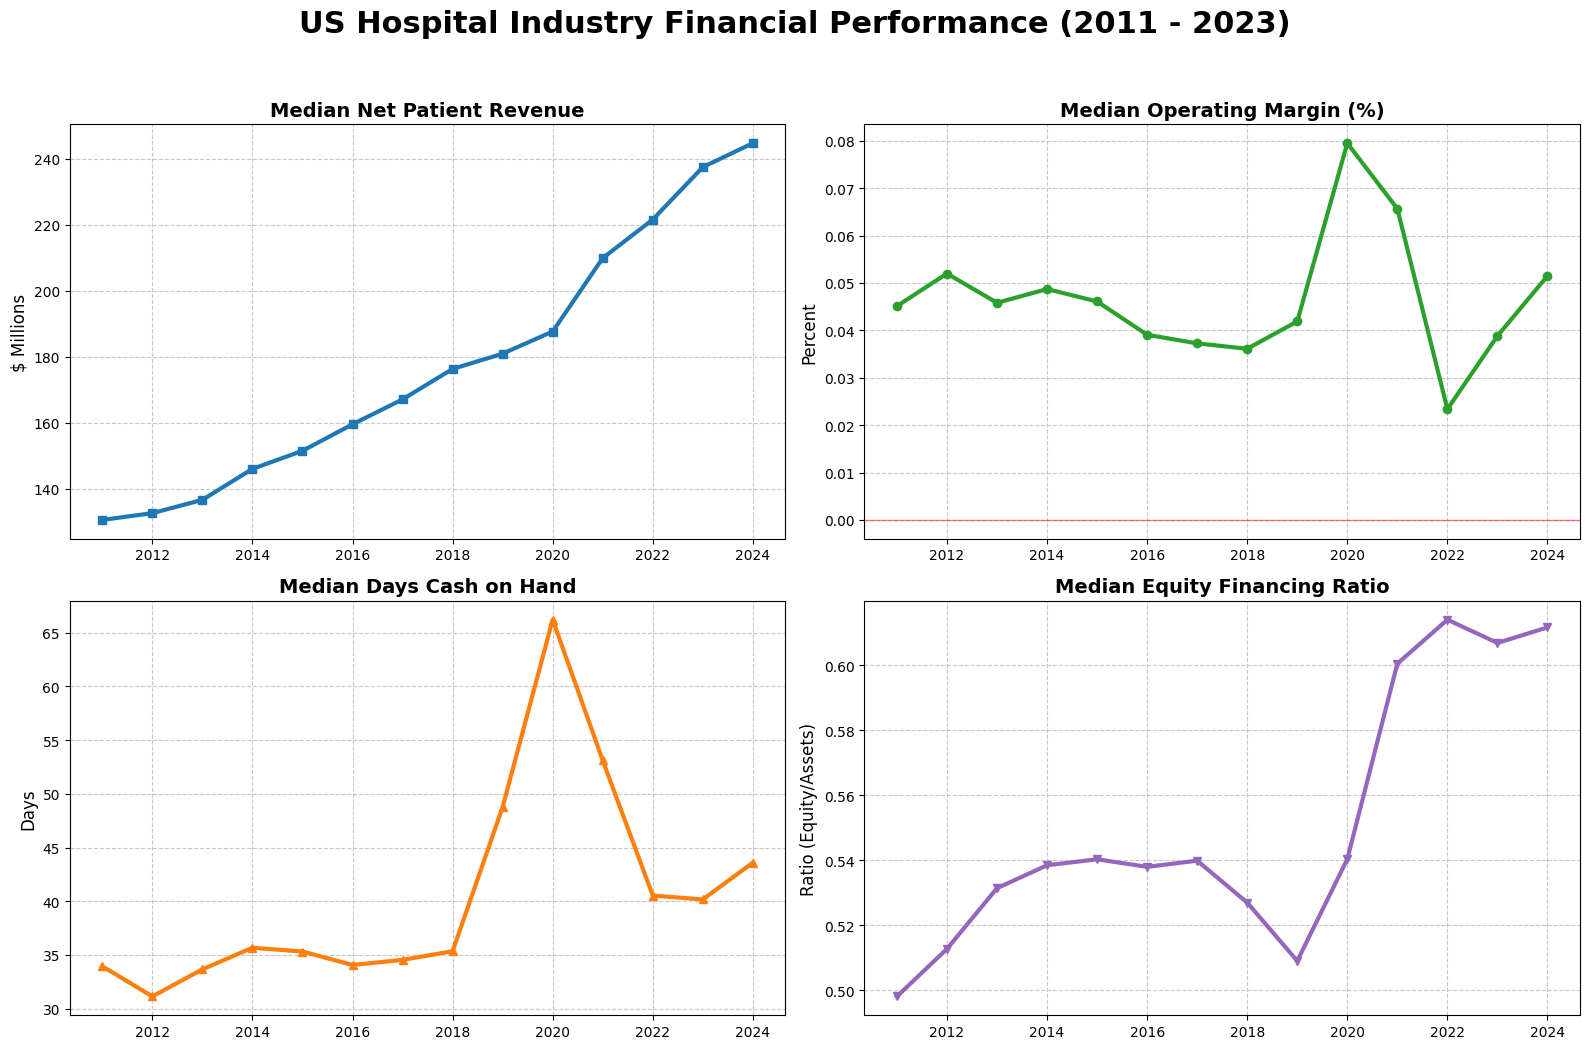

In [4]:
# industry graph
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the Data
# Extract year from fiscal year end
master_panel["Year"] = master_panel["source_year"]

data = (
    master_panel
    .groupby("Year")
    .agg(
        NPR_M = ("net_patient_revenue", lambda x: x.mean() / 1e6),   # mean revenue in millions
        Margin = ("operating_margin", "mean"),
        Cash = ("days_cash_on_hand", "mean"),
        Equity = ("equity_financing", "mean")
    )
    .reset_index()
)
df = pd.DataFrame(data)

# 2. Setup the Figure and Style
plt.style.use('seaborn-v0_8-muted') # Clean, professional look
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('US Hospital Industry Financial Performance (2011 - 2023)', 
             fontsize=22, fontweight='bold', y=0.98)

# 3. Plot 1: Net Patient Revenue (Growth Trend)
axes[0, 0].plot(df['Year'], df['NPR_M'], marker='s', color='#1f77b4', linewidth=3)
axes[0, 0].set_title('Median Net Patient Revenue', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('$ Millions', fontsize=12)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# 4. Plot 2: Operating Margin (The Volatility Story)
axes[0, 1].plot(df['Year'], df['Margin'], marker='o', color='#2ca02c', linewidth=3)
axes[0, 1].axhline(0, color='red', linewidth=1, alpha=0.5) # Breakeven line
axes[0, 1].set_title('Median Operating Margin (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Percent', fontsize=12)
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
# Highlight the 2020 spike
axes[0, 1].annotate('Stimulus Peak', xy=(2020, 8.38), xytext=(2017, 8.5),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# 5. Plot 3: Days Cash on Hand (Liquidity Stress)
axes[1, 0].plot(df['Year'], df['Cash'], marker='^', color='#ff7f0e', linewidth=3)
axes[1, 0].set_title('Median Days Cash on Hand', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Days', fontsize=12)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# 6. Plot 4: Equity Financing (Capital Structure)
axes[1, 1].plot(df['Year'], df['Equity'], marker='v', color='#9467bd', linewidth=3)
axes[1, 1].set_title('Median Equity Financing Ratio', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Ratio (Equity/Assets)', fontsize=12)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

# 7. Final Polish
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4.  Interpretability-Preserving Feature Scaling
Three dialects: (1) signed-log + RobustScaler within peer×FY-cohort,  
(2) percentile rank (anomaly scores), (3) raw proportion.  
Raw columns never overwritten. Model columns prefixed `m_`.  
Scalers fit on baseline (2012–2018) only — frozen for 2019+ inference.

In [5]:
"""
CMS HCRIS Hospital Panel — Interpretability-Preserving Feature Scaler
======================================================================
Three interpretability dialects:

  Dialect 1 — "robust deviations (median/IQR)"
      signed_log → RobustScaler(median/IQR) within peer × FY-cohort
      Interpretation: "X IQR-units above the peer median"
      NOTE: RobustScaler uses IQR, not MAD. The two are proportional
      (MAD ≈ 0.675 × IQR for normal data) but not equal. If you want
      the narrative "MAD above median," a custom scaler is required.
      IQR-units are equally interpretable and is what this code produces.
      Used for: per-unit rates, dollar volumes, count fields, deltas

  Dialect 2 — "percentile among peers"
      empirical percentile rank within peer × FY-cohort → 0-1
      Interpretation: "98th percentile Benford anomaly among peer hospitals"
      Directionality is harmonized per feature: "higher = more anomalous"
      is enforced consistently via ANOMALY_DIRECTION flags.
      Used for: anomaly scores, forensic diagnostics

  Dialect 3 — "raw proportion"
      no transform
      Used for: bounded 0-1 ratios, binary flags, ordinal scores

Design principles:
  - Raw columns NEVER overwritten — raw values stay for case investigation
  - Model-view columns prefixed "m_" for IF and VAE ingestion
  - Peer group: control_type_code (govt / nonprofit / forprofit / other)
  - FY-cohort: Dec-end vs. non-Dec-end (prevents seasonal misalignment)
    Next refinement if too coarse: quarter-of-year-end buckets
  - nonstandard_fy kept as explicit covariate — never scaled
  - Training medians stored per (family × cohort × column) and reused
    at inference — prevents imputation leakage where inference batch
    composition changes feature values
  - Missing scaler at inference raises a loud error rather than silently
    producing NaN features
  - Robust-scaled outputs clipped to [-5, +5] as a modeling choice:
    values beyond ±5 IQR-units are treated as "very extreme" rather than
    being allowed to dominate the feature space in IF/VAE. This is a
    deliberate truncation of tail information, not a statistical claim
    about the data.
  - Scalers and training medians saved together for reproducible inference

Usage:
    from cms_scaler import build_model_features, save_scalers, load_scalers
    from cms_scaler import get_model_feature_cols, validate_model_features

    # Training run
    master_panel = build_model_features(master_panel, fit=True)
    save_scalers(OUTPUT_DIR)
    validate_model_features(master_panel)
    FORENSIC_FEATURES = get_model_feature_cols(master_panel)

    # Inference on new data
    load_scalers(OUTPUT_DIR)
    new_panel = build_model_features(new_panel, fit=False)
"""

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from typing import Dict, List, Optional

# ============================================================
# FEATURE FAMILY TAXONOMY
# ============================================================

# Dialect 1a: Per-unit rates / size-sensitive
# signed_log → RobustScaler (peer × FY-cohort)
PER_UNIT_FEATURES = [
    "revenue_per_discharge",
    "cmi_proxy",            # already log-transformed in pipeline — skip log
    "forensic_efficiency",  # already log-transformed in pipeline — skip log
    "outpatient_pivot",
    "ar_velocity",
    "ap_lag",
    "days_cash_on_hand",
    "asset_turnover",
    "capex_proxy",
    "siphon_ratio",
    "staffing_gap",
    "current_ratio",
]

ALREADY_LOG_FEATURES = {"cmi_proxy", "forensic_efficiency"}

# Dialect 1b: Dollar volumes
# signed_log → RobustScaler (peer × FY-cohort)
DOLLAR_FEATURES = [
    "gross_patient_revenue",
    "net_patient_revenue",
    "total_charges",
    "total_operating_exp",
    "net_income",
    "total_salaries",
    "total_assets",
    "total_liabilities",
    "accounts_receivable",
    "accounts_payable",
    "medicare_charges",
    "dsh_payment_amt",
    "total_uncomp_care",
    "charity_care_cost",
    "bad_debt_cost",
    "home_office_adj",
    "ipps_payments",
    "ime_payment_amt",
    "physician_comp_total",
    "overhead_stepdown_total",
    "total_routine_costs",
    "drug_costs",
    "medical_supply_costs",
    "admin_general_costs",
    "radiology_diagnostic",
    "laboratory_costs",
]

# Dialect 1c: Count fields
# log1p → RobustScaler (peer × FY-cohort)
COUNT_FEATURES = [
    "licensed_beds",
    "total_discharges",
    "total_patient_days",
    "outpatient_visits",
    "er_visits",
    "total_ftes",
    "medicare_discharges",
    "intern_resident_ftes",
]

# Dialect 1d: Temporal dynamics / deltas / trajectories
# RobustScaler ONLY — already centered at zero, direction matters, tails are signal
# Do NOT log-transform: negative values are meaningful
DELTA_FEATURES = [
    "delta_operating_margin",
    "delta_total_margin",
    "delta_days_cash_on_hand",
    "delta_current_ratio",
    "delta_equity_financing",
    "delta_cmi_proxy",
    "delta_ccr",
    "delta_collection_efficiency",
    "delta_admin_load",
    "delta_ar_velocity",
    "delta_ap_lag",
    "delta_total_salaries",
    "delta_medical_supply_costs",
    "delta_accumulated_depr",
    "pct_change_licensed_beds",
    "pct_change_total_patient_days",
    "pct_change_total_discharges",
    "pct_change_er_visits",
    "pct_change_outpatient_visits",
]

# Dialect 2: Anomaly diagnostics
# Percentile rank within peer × FY-cohort
# ANOMALY_DIRECTION: True = higher raw score is more anomalous (rank as-is)
#                   False = lower raw score is more anomalous (invert: 1 - rank)
# This ensures "m_<score>" always means "higher = more suspicious" consistently.
ANOMALY_SCORE_FEATURES: List[str] = [
    # "benford_anomaly_score",      # True  — higher digit anomaly = more suspicious
    # "mahal_relational_score",     # True  — higher distance = more anomalous
    # "isolation_forest_score",     # False — IF returns negative scores; lower = more anomalous
    # "vae_reconstruction_error",   # True  — higher reconstruction error = more anomalous
]

ANOMALY_DIRECTION: Dict[str, bool] = {
    # True  = higher raw value → higher percentile → more anomalous (default)
    # False = lower raw value → more anomalous → invert rank (1 - pct_rank)
    "benford_anomaly_score":    True,
    "mahal_relational_score":   True,
    "isolation_forest_score":   False,   # IF scores are negative; lower = more anomalous
    "vae_reconstruction_error": True,
}

# Dialect 3a: Pure proportions / bounded ratios — no scaling
PROPORTION_FEATURES = [
    "operating_margin",
    "total_margin",
    "return_on_assets",
    "equity_financing",
    "labor_intensity",
    "admin_load",
    "ccr",
    "collection_efficiency",
    "medicare_dependency",
    "charity_commitment",
    "subsidy_intensity",
    "capital_age_index",
    "occupancy_rate",
    "high_risk_diagnostic_weight",
    "rel_operating_margin",
]

# Dialect 3b: Binary / ordinal flags — no scaling
BINARY_FEATURES = [
    "has_ed",
    "is_technically_insolvent",
    "liquidity_trap",
    "cash_exhaustion",
    "is_terminal",
    "is_government",
    "is_nonprofit",
    "is_forprofit",
    "sig_ghost_labor",
    "sig_supply_starvation",
    "sig_collection_collapse",
    "nonstandard_fy",           # covariate — FY timing signal, never scale
    "is_teaching",
    "is_cah",
    "is_chain",
    "bankruptcy_proxy_score",   # ordinal 0-3
]

# ============================================================
# PEER GROUP & FY-COHORT CONFIGURATION
# ============================================================
PEER_GROUP_COL = "peer_group"

def _assign_peer_group(peer_group: pd.Series) -> pd.Series:
    return peer_group.astype(str).str.strip().fillna("other")

def _assign_fy_cohort(fy_end_dt: pd.Series) -> pd.Series:
    """
    Dec-end vs. non-Dec-end bucketing.
    Prevents seasonal / reimbursement-timing misalignment when comparing
    calendar-year hospitals to federal/custom fiscal year hospitals.
    Next refinement if too coarse: quarter-of-year-end buckets
    (Dec / Mar / Jun / Sep) with the same minimum-N guardrail.
    """
    month = pd.to_datetime(fy_end_dt, errors="coerce").dt.month
    return month.map(
        lambda m: "dec_end" if m == 12 else "non_dec_end"
    ).fillna("non_dec_end")


def _cohort_key(peer_group: str, fy_cohort: str) -> str:
    return f"{peer_group}__{fy_cohort}"


# ============================================================
# SCALER REGISTRY
# ============================================================
# _REGISTRY[family_name][cohort_key] = {
#     "scaler":  fitted RobustScaler,
#     "medians": pd.Series of training medians per column (for imputation)
# }
_REGISTRY: Dict[str, Dict[str, dict]] = {}

# Global fallback — used when a cohort was not seen at fit time
_GLOBAL_FALLBACK: Dict[str, dict] = {}


# ============================================================
# CORE TRANSFORMS
# ============================================================
def signed_log(x: pd.Series) -> pd.Series:
    """
    sign(x) * log1p(|x|)
    Handles negatives (losses, adjustments), preserves zero,
    compresses heavy right tails without destroying signal direction.
    """
    return np.sign(x) * np.log1p(np.abs(x))


def percentile_rank(x: pd.Series) -> pd.Series:
    """Empirical percentile rank, 0-1. Ties averaged. NaN preserved."""
    return x.rank(pct=True, na_option="keep")


# ============================================================
# FIT / APPLY ENGINE
# ============================================================
def _fit_family(
    df: pd.DataFrame,
    input_cols: List[str],
    family_name: str,
    min_n: int = 10,
) -> None:
    """
    Fit one RobustScaler per (peer_group × FY-cohort) cohort.
    Stores both the fitted scaler and the training column medians.
    Training medians are used for imputation at both fit and apply time
    to prevent leakage (inference results must not depend on batch composition).

    Also fits a global fallback on the full dataset for unseen cohorts.
    Cohorts with fewer than min_n non-null rows fall back to global.
    """
    _REGISTRY[family_name] = {}

    # Step 1: Fit global fallback FIRST so per-cohort loops can reference
    # global_medians to fill NaN cohort medians (structurally absent features).
    sub_global     = df[input_cols].replace([np.inf, -np.inf], np.nan)
    global_medians = sub_global.median(numeric_only=True)
    # Any globally all-NaN column gets 0. "Missing means baseline" is
    # defensible for structurally absent features (e.g. intern_resident_ftes for
    # non-teaching hospitals). Prevents RobustScaler.transform() from blowing up.
    global_medians = global_medians.fillna(0.0)
    global_scaler  = RobustScaler()
    global_scaler.fit(sub_global.fillna(global_medians))
    _GLOBAL_FALLBACK[family_name] = {
        "scaler":  global_scaler,
        "medians": global_medians,
    }

    # Step 2: Per-cohort scalers
    for (pg, fyc), grp in df.groupby(["_peer_group", "_fy_cohort"]):
        key = _cohort_key(pg, fyc)
        sub = grp[input_cols].replace([np.inf, -np.inf], np.nan)

        if sub.dropna(how="all").shape[0] < min_n:
            continue

        # Training medians are the ONLY values used for imputation at inference.
        # A cohort median can be NaN if a feature is structurally absent for this
        # peer/FY combination (e.g. intern_resident_ftes for non-teaching cohorts).
        # Fill those NaN positions from global_medians (already 0-filled above).
        train_medians = sub.median(numeric_only=True)
        train_medians = train_medians.fillna(global_medians)
        filled = sub.fillna(train_medians)

        scaler = RobustScaler()
        scaler.fit(filled)

        _REGISTRY[family_name][key] = {
            "scaler":  scaler,
            "medians": train_medians,
        }

    n = len(_REGISTRY[family_name])
    print(f"  [{family_name}] {n} cohort scalers + global fallback")


def _apply_family(
    df: pd.DataFrame,
    input_cols: List[str],
    out_cols: List[str],
    family_name: str,
    clip_z: float,
    fit: bool,
) -> pd.DataFrame:
    """
    Apply fitted cohort scalers using training medians for imputation.

    - fit=True:  training medians come from the just-fitted registry (same call)
    - fit=False: training medians are loaded from disk — inference results are
                 independent of inference batch composition

    Raises RuntimeError if no scaler is available and fit=False,
    rather than silently producing NaN features.
    """
    cohort_registry = _REGISTRY.get(family_name, {})
    global_entry    = _GLOBAL_FALLBACK.get(family_name)

    if global_entry is None and not fit:
        raise RuntimeError(
            f"No scaler found for family '{family_name}' and fit=False. "
            f"Did you call load_scalers() before build_model_features()?"
        )

    for col in out_cols:
        df[col] = np.nan

    for (pg, fyc), grp_idx in df.groupby(
        ["_peer_group", "_fy_cohort"]
    ).groups.items():
        key   = _cohort_key(pg, fyc)
        entry = cohort_registry.get(key, global_entry)

        if entry is None:
            raise RuntimeError(
                f"No scaler available for cohort '{key}' in family '{family_name}'. "
                f"Global fallback is also missing. "
                f"Ensure load_scalers() was called and training data covered this family."
            )

        scaler         = entry["scaler"]
        train_medians  = entry["medians"]

        sub    = df.loc[grp_idx, input_cols].replace([np.inf, -np.inf], np.nan)
        # Use TRAINING medians for imputation — not inference batch medians
        filled = sub.fillna(train_medians)
        scaled = np.clip(scaler.transform(filled), -clip_z, clip_z)
        df.loc[grp_idx, out_cols] = scaled

    return df


# ============================================================
# MAIN PIPELINE
# ============================================================
def build_model_features(
    df: pd.DataFrame,
    fit: bool = True,
    clip_z: float = 5.0,
) -> pd.DataFrame:
    """
    Build model-view features (prefix "m_") alongside untouched raw columns.

    Parameters
    ----------
    df     : master_panel after winsorization, before parquet write
    fit    : True  = fit scalers on this data (training run)
             False = apply previously saved scalers (inference on new years)
    clip_z : robust-scaled outputs clipped to [-clip_z, +clip_z].
             Modeling choice: values beyond ±5 IQR-units are treated as
             "very extreme" rather than being allowed to dominate the feature
             space in IF/VAE. This truncates tail information deliberately.
             Default 5.0 — genuine distress typically registers at 3-4.

    Returns
    -------
    df with additional m_ columns. Raw columns are never modified.

    Raises
    ------
    RuntimeError if fit=False and scalers have not been loaded.
    """
    df = df.copy()

    df["_peer_group"] = _assign_peer_group(df[PEER_GROUP_COL])
    df["_fy_cohort"]  = _assign_fy_cohort(df["FY_END_DT"])

    if fit:
        print("Fitting scalers (peer × FY-cohort)...")

    # ----------------------------------------------------------
    # Dialect 1a: PER-UNIT RATES
    # signed_log (skip for already-log features) → RobustScaler
    # ----------------------------------------------------------
    pu_present  = [f for f in PER_UNIT_FEATURES if f in df.columns]
    pu_in_cols  = []
    pu_out_cols = []

    for f in pu_present:
        if f in ALREADY_LOG_FEATURES:
            in_col = f
        else:
            in_col = f"_sl_{f}"
            df[in_col] = signed_log(df[f])
        pu_in_cols.append(in_col)
        pu_out_cols.append(f"m_{f}")

    if pu_present:
        if fit:
            _fit_family(df, pu_in_cols, "per_unit")
        df = _apply_family(df, pu_in_cols, pu_out_cols, "per_unit", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 1b: DOLLAR VOLUMES
    # signed_log → RobustScaler
    # ----------------------------------------------------------
    dol_present  = [f for f in DOLLAR_FEATURES if f in df.columns]
    dol_in_cols  = []
    dol_out_cols = []

    for f in dol_present:
        in_col = f"_sl_{f}"
        df[in_col] = signed_log(df[f])
        dol_in_cols.append(in_col)
        dol_out_cols.append(f"m_{f}")

    if dol_present:
        if fit:
            _fit_family(df, dol_in_cols, "dollars")
        df = _apply_family(df, dol_in_cols, dol_out_cols, "dollars", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 1c: COUNT FIELDS
    # log1p → RobustScaler
    # ----------------------------------------------------------
    cnt_present  = [f for f in COUNT_FEATURES if f in df.columns]
    cnt_in_cols  = []
    cnt_out_cols = []

    for f in cnt_present:
        in_col = f"_lp_{f}"
        df[in_col] = np.log1p(df[f].clip(lower=0))
        cnt_in_cols.append(in_col)
        cnt_out_cols.append(f"m_{f}")

    if cnt_present:
        if fit:
            _fit_family(df, cnt_in_cols, "counts")
        df = _apply_family(df, cnt_in_cols, cnt_out_cols, "counts", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 1d: TEMPORAL DYNAMICS / DELTAS
    # RobustScaler ONLY — tails are the signal, direction matters
    # ----------------------------------------------------------
    dlt_present  = [f for f in DELTA_FEATURES if f in df.columns]
    dlt_out_cols = [f"m_{f}" for f in dlt_present]

    if dlt_present:
        if fit:
            _fit_family(df, dlt_present, "deltas")
        df = _apply_family(df, dlt_present, dlt_out_cols, "deltas", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 2: ANOMALY SCORES
    # Percentile rank within peer × FY-cohort, with min_n guardrail.
    # Directionality harmonized: m_ always means "higher = more anomalous"
    #
    # Cohort size guardrail: in a cohort of 8, the "87.5th percentile"
    # is a single record — overconfident and unstable. If a cohort has
    # fewer than ANOMALY_MIN_N non-null observations, fall back to
    # peer-group-only percentile (ignoring FY-cohort). If still too
    # small, fall back to global percentile across all hospitals.
    # ----------------------------------------------------------
    ANOMALY_MIN_N = 30  # minimum cohort size for stable percentile ranks

    for f in ANOMALY_SCORE_FEATURES:
        if f not in df.columns:
            continue

        result = pd.Series(np.nan, index=df.index)

        # Attempt 1: peer × FY-cohort
        for (pg, fyc), grp_idx in df.groupby(
            ["_peer_group", "_fy_cohort"]
        ).groups.items():
            sub = df.loc[grp_idx, f].dropna()
            if len(sub) >= ANOMALY_MIN_N:
                result.loc[grp_idx] = percentile_rank(df.loc[grp_idx, f])

        # Attempt 2: peer-only fallback for small FY-cohorts
        still_missing = result.isna() & df[f].notna()
        if still_missing.any():
            for pg, grp_idx in df.groupby("_peer_group").groups.items():
                sub_idx = grp_idx[still_missing.loc[grp_idx]]
                if len(sub_idx) == 0:
                    continue
                peer_sub = df.loc[grp_idx, f].dropna()
                if len(peer_sub) >= ANOMALY_MIN_N:
                    result.loc[sub_idx] = percentile_rank(df.loc[grp_idx, f]).loc[sub_idx]

        # Attempt 3: global fallback for anything still unranked
        still_missing = result.isna() & df[f].notna()
        if still_missing.any():
            global_pct = percentile_rank(df[f])
            result.loc[still_missing] = global_pct.loc[still_missing]

        higher_is_worse = ANOMALY_DIRECTION.get(f, True)
        df[f"m_{f}"] = result if higher_is_worse else (1.0 - result)

    # ----------------------------------------------------------
    # Dialect 3a: PROPORTIONS — copy as-is
    # ----------------------------------------------------------
    for f in PROPORTION_FEATURES:
        if f in df.columns:
            df[f"m_{f}"] = df[f]

    # ----------------------------------------------------------
    # Dialect 3b: BINARY / ORDINAL — copy as-is
    # ----------------------------------------------------------
    for f in BINARY_FEATURES:
        if f in df.columns:
            df[f"m_{f}"] = df[f]

    # ----------------------------------------------------------
    # Cleanup temporary transform columns
    # ----------------------------------------------------------
    temp_cols = [
        c for c in df.columns
        if c.startswith("_sl_")
        or c.startswith("_lp_")
        or c in ("_peer_group", "_fy_cohort")
    ]
    df.drop(columns=temp_cols, inplace=True, errors="ignore")

    n_model = sum(1 for c in df.columns if c.startswith("m_"))
    print(f"Model features built: {n_model} m_ columns")

    return df


# ============================================================
# SCALER PERSISTENCE
# ============================================================
def save_scalers(output_dir: Path) -> None:
    """
    Persist fitted scaler registry (scalers + training medians) and
    global fallbacks to disk. Both files are required for inference.
    Fit once, apply forever — training medians ensure inference results
    are independent of batch composition.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    registry_path = output_dir / "cms_scaler_registry.pkl"
    fallback_path = output_dir / "cms_scaler_fallback.pkl"

    joblib.dump(_REGISTRY,        registry_path)
    joblib.dump(_GLOBAL_FALLBACK, fallback_path)

    print(f"Scaler registry  → {registry_path}")
    print(f"Global fallbacks → {fallback_path}")
    for family, cohorts in _REGISTRY.items():
        print(f"  {family}: {len(cohorts)} cohort scalers")


def load_scalers(output_dir: Path) -> None:
    """
    Load fitted scaler registry into module-level state.
    Must be called before build_model_features(..., fit=False).
    Raises FileNotFoundError if either required file is missing.
    """
    global _REGISTRY, _GLOBAL_FALLBACK

    registry_path = Path(output_dir) / "cms_scaler_registry.pkl"
    fallback_path = Path(output_dir) / "cms_scaler_fallback.pkl"

    if not registry_path.exists():
        raise FileNotFoundError(f"Scaler registry not found: {registry_path}")
    if not fallback_path.exists():
        raise FileNotFoundError(f"Global fallback not found: {fallback_path}")

    _REGISTRY        = joblib.load(registry_path)
    _GLOBAL_FALLBACK = joblib.load(fallback_path)

    print(f"Scalers loaded from {output_dir}")
    for family, cohorts in _REGISTRY.items():
        print(f"  {family}: {len(cohorts)} cohort scalers")


# ============================================================
# MODEL FEATURE LIST
# ============================================================
def get_model_feature_cols(
    df: pd.DataFrame,
    exclude_binary: bool = False,
) -> List[str]:
    """
    Return sorted list of m_ columns present in df.
    Use to build the feature matrix passed to IF and VAE.
    """
    binary_m = {f"m_{f}" for f in BINARY_FEATURES}
    return [
        c for c in sorted(df.columns)
        if c.startswith("m_")
        and (not exclude_binary or c not in binary_m)
    ]


# ============================================================
# VALIDATION
# ============================================================
def validate_model_features(
    df: pd.DataFrame,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Sanity check on scaled feature distributions.
    Returns a summary DataFrame; prints warnings for:
      - Empty features (all NaN)
      - Constant features (zero variance)
      - Clip failures (max |value| > clip_z + 0.5)
      - High null rate (> 50%)
      - Proportion dialect values outside [-0.1, 1.1]
      - Anomaly scores outside [0, 1]
      - Directionality not registered (anomaly feature missing from ANOMALY_DIRECTION)
    """
    model_cols   = get_model_feature_cols(df)
    proportion_m = {f"m_{f}" for f in PROPORTION_FEATURES}
    binary_m     = {f"m_{f}" for f in BINARY_FEATURES}
    anomaly_m    = {f"m_{f}" for f in ANOMALY_SCORE_FEATURES}

    records  = []
    warnings = []

    for col in model_cols:
        s        = df[col]
        s_clean  = s.dropna()
        pct_null = s.isna().mean()

        dialect = (
            "anomaly"    if col in anomaly_m    else
            "proportion" if col in proportion_m else
            "binary"     if col in binary_m     else
            "scaled"
        )

        rec = {
            "feature":  col,
            "dialect":  dialect,
            "count":    len(s_clean),
            "pct_null": round(pct_null, 3),
            "mean":     round(s_clean.mean(),   4) if len(s_clean) else np.nan,
            "median":   round(s_clean.median(), 4) if len(s_clean) else np.nan,
            "std":      round(s_clean.std(),    4) if len(s_clean) else np.nan,
            "min":      round(s_clean.min(),    4) if len(s_clean) else np.nan,
            "max":      round(s_clean.max(),    4) if len(s_clean) else np.nan,
            "n_unique": s_clean.nunique(),
        }
        records.append(rec)

        if len(s_clean) == 0:
            warnings.append(f"EMPTY          : {col}")
            continue

        if s_clean.nunique() == 1:
            warnings.append(f"CONSTANT       : {col} = {s_clean.iloc[0]}")

        if pct_null > 0.5:
            warnings.append(f"HIGH_NULL {pct_null:.0%}  : {col}")

        if dialect == "scaled":
            max_abs = s_clean.abs().max()
            if max_abs > 5.5:
                warnings.append(f"CLIP_MISS      : {col}  max_abs={max_abs:.1f}")

        if dialect == "proportion":
            if s_clean.min() < -0.1 or s_clean.max() > 1.1:
                warnings.append(
                    f"PROPORTION_OOB : {col}  "
                    f"[{s_clean.min():.3f}, {s_clean.max():.3f}]"
                )

        if dialect == "anomaly":
            if s_clean.min() < 0.0 or s_clean.max() > 1.0:
                warnings.append(
                    f"ANOMALY_OOB    : {col}  "
                    f"[{s_clean.min():.3f}, {s_clean.max():.3f}]"
                )
            raw_name = col[2:]  # strip "m_"
            if raw_name not in ANOMALY_DIRECTION:
                warnings.append(
                    f"DIRECTION_MISS : {col}  not in ANOMALY_DIRECTION — "
                    f"add True/False to confirm higher=more anomalous"
                )

    summary = pd.DataFrame(records).set_index("feature")

    if verbose:
        print(f"\n{'='*60}")
        print(f"Model feature validation — {len(model_cols)} m_ columns")
        print(f"{'='*60}")

        if warnings:
            print(f"\n{len(warnings)} WARNING(s):")
            for w in warnings:
                print(f"  {w}")
        else:
            print("\nAll features passed validation.")

        print("\nDialect breakdown:")
        print(summary["dialect"].value_counts().to_string())

        print("\nScaled feature distributions (first 10):")
        scaled_sample = [
            c for c in model_cols
            if c not in proportion_m | binary_m | anomaly_m
        ][:10]
        if scaled_sample:
            print(
                df[scaled_sample]
                .describe(percentiles=[.1, .25, .5, .75, .9])
                .round(2)
                .to_string()
            )

    return summary

# 5.  Train / Score Split
Fit scalers on `data_regime == 'baseline'` (FY2012–2018).  
Apply frozen transforms to all scoring years (FY2019–2024).  
This cell must execute before any forensic scoring.

In [6]:
SCALER_DIR = OUTPUT_DIR / "scalers"

# Split before building features
train_panel = master_panel[master_panel.data_regime == "baseline"].copy()  # 2012–2018
score_panel = master_panel[master_panel.data_regime != "baseline"].copy()  # everything else

# Fit on baseline only
train_panel = build_model_features(train_panel, fit=True)
save_scalers(SCALER_DIR)

# Score entire non-baseline panel with frozen scalers
load_scalers(SCALER_DIR)
score_panel = build_model_features(score_panel, fit=False)

# Reassemble for downstream cells
master_panel = pd.concat([train_panel, score_panel]).sort_values(["PRVDR_NUM", "FY_BGN_DT"]).reset_index(drop=True)

Fitting scalers (peer × FY-cohort)...
  [per_unit] 80 cohort scalers + global fallback
  [dollars] 82 cohort scalers + global fallback
  [counts] 82 cohort scalers + global fallback
  [deltas] 82 cohort scalers + global fallback


C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:366: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = np.nan
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:366: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = np.nan
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:366: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

Model features built: 96 m_ columns
Scaler registry  → c:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\processed_panel\scalers\cms_scaler_registry.pkl
Global fallbacks → c:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\processed_panel\scalers\cms_scaler_fallback.pkl
  per_unit: 80 cohort scalers
  dollars: 82 cohort scalers
  counts: 82 cohort scalers
  deltas: 82 cohort scalers
Scalers loaded from c:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\processed_panel\scalers
  per_unit: 80 cohort scalers
  dollars: 82 cohort scalers
  counts: 82 cohort scalers
  deltas: 82 cohort scalers


C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:366: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = np.nan
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:366: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = np.nan
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:366: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

Model features built: 96 m_ columns


C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:555: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"m_{f}"] = df[f]
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:555: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"m_{f}"] = df[f]
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\3038446129.py:555: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

# 6a.  Forensic Signal Computation
Computes all raw forensic signals:  
- **Structural:** Mahalanobis relational distance, VAE reconstruction error  
- **Behavioral:** Benford digit anomaly, Goodz, bunching, SRRI submetrics  
- **Temporal:** decoupling index, curvature, rank instability, peer divergence  
Isolation Forest retained as legacy benchmark input only.  
Train/score leakage controlled via `data_regime` mask inside each function.

In [7]:
import pandas as pd
import numpy as np
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# =============================================================================
# INSANE PANEL FORENSICS v8.1  (with Economic Profile context)
# - Keeps your forensic design intact
# - Expands the Isolation Forest feature space to include “economic profile”
#   + liquidity/solvency + utilization + payer/subsidy + cashflow velocity + capital aging
# - Explainability stays forensic-first by default (cleaner narratives)
# =============================================================================

# -----------------------------
# 0) Basic hygiene & helpers
# -----------------------------
df = master_panel.copy()
_pg_backup = df["peer_group"].copy()
_pgf_backup = df["peer_group_fine"].copy()

# Sanity check — catch missing columns before they cause cryptic KeyErrors downstream
required_cols = ["peer_group", "peer_group_fine", "data_regime", "ownership_clean", "size_tier", "teaching_tier"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"master_panel is missing columns: {missing}. Re-run Cell 7 fully before proceeding.")

df = df.sort_values(["PRVDR_NUM", "source_year"]).reset_index(drop=True)

status_map = {
    '1': 'Original_As_Submitted',
    '2': 'Settled_No_Audit',
    '3': 'Settled_With_Audit',
    '4': 'Reopened',
    '5': 'Amended'
}
df['submission_type'] = df['RPT_STUS_CD'].map(status_map)

def _safe_div(n, d):
    d2 = pd.to_numeric(d, errors="coerce").replace(0, np.nan)
    n2 = pd.to_numeric(n, errors="coerce")
    return n2 / d2

def robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(0.0, index=x.index)
    return 0.6745 * (x - med) / mad

def winsorize(s: pd.Series, lo=0.01, hi=0.99) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() == 0:
        return x
    ql, qh = x.quantile(lo), x.quantile(hi)
    return x.clip(lower=ql, upper=qh)

def guarded_pct_change(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    lag = x.shift(1)
    out = (x / lag) - 1.0
    out = out.mask(lag <= 0)
    return out

def _rolling_slope(series: pd.Series, window: int = 6, min_periods: int = 4) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    def _fit(v):
        v = pd.to_numeric(pd.Series(v), errors="coerce").dropna()
        if len(v) < min_periods:
            return np.nan
        t = np.arange(len(v), dtype=float)
        try:
            return float(np.polyfit(t, v.values.astype(float), 1)[0])
        except Exception:
            return np.nan
    return x.rolling(window, min_periods=min_periods).apply(_fit, raw=False)

def _rolling_curvature(series: pd.Series, window: int = 6, min_periods: int = 5) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    def _fit2(v):
        v = pd.to_numeric(pd.Series(v), errors="coerce").dropna()
        if len(v) < min_periods:
            return np.nan
        t = np.arange(len(v), dtype=float)
        try:
            return float(np.polyfit(t, v.values.astype(float), 2)[0])
        except Exception:
            return np.nan
    return x.rolling(window, min_periods=min_periods).apply(_fit2, raw=False)

def _time_since_event(flag_series: pd.Series) -> pd.Series:
    f = pd.to_numeric(flag_series, errors="coerce").fillna(0).astype(int).values
    out = []
    run = 0
    seen = False
    for v in f:
        if v == 1:
            run = 0
            seen = True
        else:
            run = (run + 1) if seen else np.nan
        out.append(run)
    return pd.Series(out, index=flag_series.index)

# -----------------------------
# 1) Structural metrics (forensic)
# -----------------------------
df["rev_per_day"]        = _safe_div(df["net_patient_revenue"], df["total_patient_days"])
df["dc_per_bed"]         = _safe_div(df["total_discharges"], df["licensed_beds"])
df["rev_to_asset_ratio"] = _safe_div(df["net_patient_revenue"], df["total_assets"])
df["exp_per_day"]        = _safe_div(df["total_operating_exp"], df["total_patient_days"])
df["asset_per_bed"]      = _safe_div(df["total_assets"], df["licensed_beds"])
df["rev_per_discharge"]  = _safe_div(df["net_patient_revenue"], df["total_discharges"])
df["days_per_discharge"] = _safe_div(df["total_patient_days"], df["total_discharges"])

STRUCT_COLS = ["rev_per_day","dc_per_bed","rev_to_asset_ratio","exp_per_day",
               "asset_per_bed","rev_per_discharge","days_per_discharge"]
for c in STRUCT_COLS:
    df[c] = winsorize(df[c])

# -----------------------------
# 2) Temporal / panel dynamics (forensic)
# -----------------------------
df["rev_growth"] = df.groupby("PRVDR_NUM")["net_patient_revenue"].transform(guarded_pct_change)
df["exp_growth"] = df.groupby("PRVDR_NUM")["total_operating_exp"].transform(guarded_pct_change)
df["decoupling_index"] = df["rev_growth"] - df["exp_growth"]

df["rev_self_z"] = df.groupby("PRVDR_NUM")["net_patient_revenue"].transform(robust_z)
df["exp_self_z"] = df.groupby("PRVDR_NUM")["total_operating_exp"].transform(robust_z)

if "operating_margin" not in df.columns:
    df["operating_margin"] = _safe_div(
        df["net_patient_revenue"] - df["total_operating_exp"],
        df["net_patient_revenue"]
    )

df["margin_delta"] = df.groupby("PRVDR_NUM")["operating_margin"].diff()

df["rev_growth_roll_std4"] = df.groupby("PRVDR_NUM")["rev_growth"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(4, min_periods=2).std()
)

df["margin_slope6"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: _rolling_slope(s, window=6, min_periods=4))
df["margin_curv6"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: _rolling_curvature(s, window=6, min_periods=5))

df["margin_roll_mean8"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(8, min_periods=4).mean()
)
df["margin_roll_std12"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(12, min_periods=5).std()
)
df["margin_equilibrium_dist"] = _safe_div(
    df["operating_margin"] - df["margin_roll_mean8"], df["margin_roll_std12"]
)

df["had_margin_decline"] = (pd.to_numeric(df["margin_delta"], errors="coerce") < 0).astype(float)
df["time_since_margin_decline"] = df.groupby("PRVDR_NUM")["had_margin_decline"].transform(
    _time_since_event
)

df["z_resid_margin"] = _safe_div(
    df["operating_margin"] - df["margin_roll_mean8"],
    df["margin_roll_std12"]
).clip(-5, 5)

df["z_resid_delta_margin"] = df.groupby("PRVDR_NUM")["z_resid_margin"].diff()

df["z_resid_roll_std4"] = df.groupby("PRVDR_NUM")["z_resid_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(4, min_periods=2).std()
)

df["margin_var_collapse"] = _safe_div(df["z_resid_roll_std4"], df["margin_roll_std12"])

# -----------------------------
# 3) Relational anomalies (robust Mahalanobis) — fit on baseline only
# -----------------------------
REL_COLS = ["net_patient_revenue", "total_operating_exp", "total_assets"]

def mahalanobis_relational(gdf: pd.DataFrame) -> pd.Series:
    out = pd.Series(0.0, index=gdf.index)
    train = gdf[gdf["data_regime"] == "baseline"]
    if len(train) < 25:
        return out
    imp = SimpleImputer(strategy="median")
    scaler = RobustScaler()
    X_train = scaler.fit_transform(imp.fit_transform(train[REL_COLS]))
    try:
        mcd = MinCovDet(random_state=42).fit(X_train)
    except Exception:
        return out
    X_all = scaler.transform(imp.transform(gdf[REL_COLS].fillna(gdf[REL_COLS].median())))
    return pd.Series(mcd.mahalanobis(X_all), index=gdf.index)

df["mahal_relational_score"] = df.groupby("peer_group", group_keys=False).apply(mahalanobis_relational)

# -----------------------------
# 4) Benford anomalies — fine peer group + year
# -----------------------------
def benford_kl_first_digit(values: pd.Series, min_n: int = 200) -> float:
    x = pd.to_numeric(values, errors="coerce").abs()
    x = x[x > 0].dropna()
    if len(x) < min_n:
        return np.nan
    leading = x.astype(int).astype(str).str[0]
    leading = pd.to_numeric(leading, errors="coerce")
    leading = leading[(leading >= 1) & (leading <= 9)]
    if len(leading) < min_n:
        return np.nan
    obs = leading.value_counts(normalize=True).sort_index().reindex(range(1, 10), fill_value=0.0)
    exp = np.log10(1 + 1 / np.arange(1, 10))
    return float(np.sum(obs.values * np.log((obs.values + 1e-9) / (exp + 1e-9))))

df["benford_anomaly_score"] = df.groupby(
    ["peer_group_fine", "source_year"]
)["total_operating_exp"].transform(lambda s: benford_kl_first_digit(s, min_n=200))

# -----------------------------
# 5) Gaming-aware features (forensic)
# -----------------------------
GOOD_DIR_METRICS = {
    "operating_margin": +1,
    "rev_per_day": +1,
    "exp_per_day": -1,
    "days_per_discharge": -1
}

for m, direction in GOOD_DIR_METRICS.items():
    zname = f"z_peer_{m}"
    df[zname] = df.groupby("peer_group")[m].transform(robust_z)
    df[f"goodz_{m}"] = (df[zname] * direction).clip(lower=0)

df["goodz_nat_sum"] = df[[f"goodz_{m}" for m in GOOD_DIR_METRICS]].sum(axis=1)

peer_metric_sd = {}
for m in GOOD_DIR_METRICS:
    sd_col = f"_sd_peer_{m}"
    df[sd_col] = df.groupby("peer_group")[m].transform("std").replace(0, np.nan)
    peer_metric_sd[m] = sd_col

df["goodz_weighted_sum"] = sum(
    df[f"goodz_{m}"] * (1.0 / df[peer_metric_sd[m]].clip(lower=1e-6))
    for m in GOOD_DIR_METRICS
)

df["too_good_flag"] = (df["goodz_nat_sum"] > 1.0).astype(int)

def _tslf(g):
    streak = []
    run = 0
    for v in g["too_good_flag"].fillna(0).astype(int).values:
        run = (run + 1) if v == 1 else 0
        streak.append(run)
    return pd.Series(streak, index=g.index)

df["tslf"] = df.groupby("PRVDR_NUM", group_keys=False).apply(_tslf)

THRESH = np.array([-0.05, -0.02, 0.0, 0.02, 0.05, 0.10], dtype=float)
dist = (pd.to_numeric(df["operating_margin"], errors="coerce").values.reshape(-1, 1) - THRESH.reshape(1, -1))
df["bunch_dist"] = np.nanmin(np.abs(dist), axis=1)
df["bunch_signal_operating_margin"] = 1.0 / (df["bunch_dist"] + 1e-6)

TRACK_IMPROVE = ["operating_margin", "rev_per_day", "exp_per_day", "days_per_discharge"]
IMPROVE_DIR = {"operating_margin": +1, "rev_per_day": +1, "exp_per_day": -1, "days_per_discharge": -1}

for m in TRACK_IMPROVE:
    df[f"improve_{m}"] = ((df.groupby("PRVDR_NUM")[m].diff() * IMPROVE_DIR[m]) > 0).astype(float)

for m in TRACK_IMPROVE:
    roll_mean = df.groupby("PRVDR_NUM")[m].transform(
        lambda s: pd.to_numeric(s, errors="coerce").rolling(8, min_periods=4).mean()
    )
    roll_std = df.groupby("PRVDR_NUM")[m].transform(
        lambda s: pd.to_numeric(s, errors="coerce").rolling(12, min_periods=5).std()
    )
    df[f"z_resid_{m}"] = _safe_div(df[m] - roll_mean, roll_std).clip(-5, 5)
    df[f"z_resid_delta_{m}"] = df.groupby("PRVDR_NUM")[f"z_resid_{m}"].diff()

df["pct_measures_improving"] = df[[f"z_resid_delta_{m}" for m in TRACK_IMPROVE]].gt(0).mean(axis=1)
df["facility_consistency_sd"] = df[[f"z_peer_{m}" for m in GOOD_DIR_METRICS]].std(axis=1)

STATE_YEAR_KEY = ["state", "source_year"]
for m in GOOD_DIR_METRICS:
    df[f"z_state_{m}"] = df.groupby(STATE_YEAR_KEY)[m].transform(robust_z)

df["z_delta_mean"] = np.mean([(df[f"z_peer_{m}"] - df[f"z_state_{m}"]).abs() for m in GOOD_DIR_METRICS], axis=0)
df["z_delta_signed_margin"] = df["z_peer_operating_margin"] - df["z_state_operating_margin"]

PEER_YEAR_KEY = ["peer_group", "source_year"]
for m in TRACK_IMPROVE:
    df[f"z_peeryear_{m}"] = df.groupby(PEER_YEAR_KEY)[m].transform(robust_z)

df["peer_divergence_year"] = df[[f"z_peeryear_{m}" for m in TRACK_IMPROVE]].abs().mean(axis=1)

for m in ["operating_margin", "rev_per_day", "exp_per_day", "days_per_discharge"]:
    rcol = f"rankp_{m}"
    df[rcol] = df.groupby(PEER_YEAR_KEY)[m].rank(pct=True, method="average")
    df[f"rank_instab_{m}"] = df.groupby("PRVDR_NUM")[rcol].diff().abs()

df["rank_instability_mean"] = df[[f"rank_instab_{m}" for m in
                                  ["operating_margin","rev_per_day","exp_per_day","days_per_discharge"]]].mean(axis=1)

UNTARGETED = ["rev_to_asset_ratio","asset_per_bed","dc_per_bed","rev_per_discharge","days_per_discharge"]
UNT_DIR    = {"rev_to_asset_ratio":+1,"asset_per_bed":+1,"dc_per_bed":+1,
              "rev_per_discharge":+1,"days_per_discharge":-1}

for m in UNTARGETED:
    df[f"improve_unt_{m}"] = ((df.groupby("PRVDR_NUM")[m].diff() * UNT_DIR[m]) > 0).astype(float)

df["pct_untargeted_improving"] = df[[f"improve_unt_{m}" for m in UNTARGETED]].mean(axis=1)
df["tradeoff_signal"] = (df["pct_measures_improving"] - df["pct_untargeted_improving"]).clip(lower=0)

STEP_VARS = ["operating_margin","rev_per_day","exp_per_day","days_per_discharge","rev_to_asset_ratio","dc_per_bed"]
for m in STEP_VARS:
    df[f"d_{m}"] = df.groupby("PRVDR_NUM")[m].diff()

df["path_step_norm"] = np.sqrt(
    np.nansum(
        np.vstack([pd.to_numeric(df[f"d_{m}"], errors="coerce").values**2 for m in STEP_VARS]).T,
        axis=1
    )
)

df["margin_p95_peeryear"] = df.groupby(PEER_YEAR_KEY)["operating_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").quantile(0.95)
)
df["ceiling_proximity_margin"] = (
    pd.to_numeric(df["operating_margin"], errors="coerce") >= pd.to_numeric(df["margin_p95_peeryear"], errors="coerce")
).astype(int)
df["ceiling_violation_margin"] = (
    (df["ceiling_proximity_margin"] == 1) &
    (pd.to_numeric(df["margin_delta"], errors="coerce") > 0)
).astype(int)

# -----------------------------
# 6) Economic Profile (context features for the Forest)
# -----------------------------
ECON_PROFILE_FEATURES = [
    # scale anchors
    "net_patient_revenue", "total_operating_exp", "total_assets",
    "licensed_beds", "total_patient_days", "total_discharges",

    # liquidity/solvency
    "days_cash_on_hand", "current_ratio", "equity_financing", "return_on_assets", "total_margin",

    # utilization / mix
    "occupancy_rate", "outpatient_pivot", "has_ed", "cmi_proxy",

    # revenue integrity / payer / uncomp care
    "ccr", "collection_efficiency", "medicare_dependency", "charity_commitment",
    "subsidy_intensity",

    # working capital / velocity
    "ar_velocity", "ap_lag", "asset_turnover",

    # cost structure / labor / staffing
    "labor_intensity", "admin_load", "staffing_gap", "high_risk_diagnostic_weight",

    # capital / reinvestment
    "capex_proxy", "capital_age_index",

    # structural extraction / “paper trail”
    "siphon_ratio",

    # market-relative performance
    "rel_operating_margin",

    # distress flags (treat as covariates; the forest can still use them)
    "is_technically_insolvent", "liquidity_trap", "cash_exhaustion", "bankruptcy_proxy_score", "is_terminal",
]
ECON_PROFILE_FEATURES = [c for c in ECON_PROFILE_FEATURES if c in df.columns]

# light winsorization on context variables (prevents single-field domination)
for c in ECON_PROFILE_FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        df[c] = winsorize(df[c])

# -----------------------------
# 7) The Forest (forensic + economic profile)
# -----------------------------
FORENSIC_FEATURES = (
    [
        # structural
        "rev_per_day", "dc_per_bed", "rev_to_asset_ratio", "exp_per_day",
        "asset_per_bed", "rev_per_discharge", "days_per_discharge",

        # core temporal / dynamics
        "decoupling_index", "rev_self_z", "exp_self_z", "margin_delta",
        "z_resid_roll_std4", "rev_growth_roll_std4",

        # relational / digits
        "mahal_relational_score", "benford_anomaly_score",

        # gaming-aware
        "goodz_nat_sum", "goodz_weighted_sum", "tslf",
        "pct_measures_improving", "facility_consistency_sd",
        "bunch_signal_operating_margin",

        # trajectory plausibility
        "margin_slope6", "margin_curv6", "margin_equilibrium_dist",
        "time_since_margin_decline", "margin_var_collapse",
        "peer_divergence_year", "rank_instability_mean",
        "tradeoff_signal", "path_step_norm",
        "ceiling_proximity_margin", "ceiling_violation_margin",
        "pct_untargeted_improving",

        # national vs regional divergence
        "z_delta_mean", "z_delta_signed_margin",
    ]
    + [f"z_resid_{m}" for m in TRACK_IMPROVE]
    + [f"z_resid_delta_{m}" for m in TRACK_IMPROVE]
)

# unify feature space for Isolation Forest
MODEL_FEATURES = [c for c in (FORENSIC_FEATURES + ECON_PROFILE_FEATURES) if c in df.columns]

missing_forensic = sorted(set(FORENSIC_FEATURES) - set(MODEL_FEATURES))
if missing_forensic:
    print(f"[WARN] Missing forensic cols (skipping): {missing_forensic[:10]}{'...' if len(missing_forensic)>10 else ''}")

print(f"[INFO] Model features: {len(MODEL_FEATURES)} (forensic={len([c for c in FORENSIC_FEATURES if c in df.columns])}, econ={len(ECON_PROFILE_FEATURES)})")

def run_insane_panel_forest(gdf: pd.DataFrame, contamination=0.04) -> pd.DataFrame:
    out = gdf.copy()

    # Train on baseline only (your design)
    train = out[out["data_regime"] == "baseline"].dropna(subset=MODEL_FEATURES)
    if len(train) < 30:
        out["anomaly_score"] = np.nan
        out["is_anomaly"] = 0
        return out

    imp = SimpleImputer(strategy="median")
    scaler = RobustScaler()

    X_train = scaler.fit_transform(imp.fit_transform(train[MODEL_FEATURES]))

    iso = IsolationForest(
        n_estimators=1500,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_train)

    score_rows = out.dropna(subset=MODEL_FEATURES)
    X_score = scaler.transform(imp.transform(score_rows[MODEL_FEATURES]))

    out.loc[score_rows.index, "anomaly_score"] = iso.decision_function(X_score)
    out.loc[score_rows.index, "is_anomaly"]    = iso.predict(X_score)
    return out

df = df.groupby("peer_group", group_keys=False).apply(run_insane_panel_forest)
df = df.reset_index(drop=True)  # <-- ADD THIS

# Restore if dropped
if "peer_group" not in df.columns:
    df["peer_group"] = _pg_backup.values
if "peer_group_fine" not in df.columns:
    df["peer_group_fine"] = _pgf_backup.values
# -----------------------------
# 8) Explainability (forensic-first; optional econ add-on)
# -----------------------------
def explain_outliers(df: pd.DataFrame, top_k=6, include_econ=False) -> pd.DataFrame:
    out = df.copy()

    # Choose explain-space
    explain_space = FORENSIC_FEATURES.copy()
    if include_econ:
        explain_space = list(dict.fromkeys(explain_space + ECON_PROFILE_FEATURES))  # stable unique

    cols_to_drop = [f"z_{c}" for c in explain_space if f"z_{c}" in out.columns]
    if cols_to_drop:
        out = out.drop(columns=cols_to_drop)

    z_by_peer = (
        out.groupby("peer_group", group_keys=False)   # <-- was 'df', should be 'out'
        .apply(lambda g: pd.DataFrame({c: robust_z(g[c]) for c in explain_space if c in g.columns}, index=g.index))
    ).add_prefix("z_")

    out = out.join(z_by_peer)

    z_cols = [f"z_{c}" for c in explain_space if f"z_{c}" in out.columns]
    out["suspicion_density"] = (out[z_cols].abs() >= 2.0).sum(axis=1)

    def _row_explain(row):
        pairs = []
        for c in explain_space:
            z_val = row.get(f"z_{c}", np.nan)
            raw   = row.get(c, np.nan)
            if pd.isna(z_val):
                continue
            pairs.append((c, float(z_val), abs(float(z_val)), raw))
        if not pairs:
            return ""
        pairs.sort(key=lambda t: t[2], reverse=True)
        return "; ".join([
            f"{c} {'HIGH' if z > 0 else 'LOW'} (z={z:+.2f}, val={r:,.4g})"
            for c, z, _, r in pairs[:top_k]
        ])

    out["outlier_drivers_top"] = np.where(
        out["is_anomaly"] == -1, out.apply(_row_explain, axis=1), ""
    )
    return out

df = explain_outliers(df, top_k=6, include_econ=False)

# -----------------------------
# 9) Final Lead Sheet (case-file friendly)
# -----------------------------
CASEFILE_COLS = [
    "PRVDR_NUM", "hospital_name", "state",
    "source_year", "peer_group", "peer_group_fine",
    "data_regime", "submission_type",
    "anomaly_score", "outlier_drivers_top"
] + [c for c in ECON_PROFILE_FEATURES if c in df.columns]

CASEFILE_COLS = [c for c in CASEFILE_COLS if c in df.columns]

top_leads = df[df["is_anomaly"] == -1].sort_values("anomaly_score").head(50)
print(f"Analysis Complete. Found {int((df['is_anomaly'] == -1).sum())} panel outliers.")
display(top_leads[CASEFILE_COLS].head(20))

c:\Users\lfult\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['net_patient_revenue']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\lfult\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['net_patient_revenue']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\2538286974.py:263: RuntimeWarning: All-NaN slice encountered
  df["bunch_dist"] = np.nanmin(np.abs(dist), axis=1)


[INFO] Model features: 79 (forensic=43, econ=36)
Analysis Complete. Found 434 panel outliers.


,PRVDR_NUM,hospital_name,state,source_year,peer_group,peer_group_fine,data_regime,submission_type,anomaly_score,outlier_drivers_top,...,high_risk_diagnostic_weight,capex_proxy,capital_age_index,siphon_ratio,rel_operating_margin,is_technically_insolvent,liquidity_trap,cash_exhaustion,bankruptcy_proxy_score,is_terminal
80242,520107,HOLY FAMILY MEMORIAL INC,WI,2023,government_large_non_teaching,government_large_non_teaching_high_cmi,recovery,Original_As_Submitted,-0.201323,"mahal_relational_score HIGH (z=+19009.36, val=...",...,0.091472,3.595070e+05,0.277425,1.625283,0.335601,0,1,1,2,1
21184,140234,ST. MARGARETS HEALTH - PERU,IL,2023,government_large_non_teaching,government_large_non_teaching_high_cmi,recovery,Settled_No_Audit,-0.143166,"path_step_norm HIGH (z=+67.10, val=5.013e+04);...",...,0.060275,1.242725e+07,0.724251,-0.147223,-0.623656,1,0,1,2,1
48462,320065,COVENANT HEALTH HOBBS HOSPITAL,NM,2023,government_large_non_teaching,government_large_non_teaching_mid_cmi,recovery,Original_As_Submitted,-0.123749,"rev_growth_roll_std4 HIGH (z=+10.00, val=0.647...",...,0.041105,-5.608234e+06,0.039733,-0.714307,-0.623656,1,1,1,3,1
54913,360090,ST. LUKES HOSPITAL,OH,2023,government_major_minor_teaching,government_major_minor_teaching_mid_cmi,recovery,Settled_No_Audit,-0.122189,"path_step_norm HIGH (z=+9.54, val=4,558); faci...",...,0.052613,-1.538747e+07,0.237321,-0.372594,-0.623656,1,1,1,3,1
59916,381308,SALEM HEALTH WEST VALLEY,OR,2022,cah_government,cah_government_high_cmi,recovery,Original_As_Submitted,-0.120489,"goodz_weighted_sum HIGH (z=+358.83, val=21.05)...",...,0.128222,1.465798e+07,0.220779,0.124653,0.276294,0,0,0,0,0
48360,320038,REHOBOTH MCKINLEY CHRISTIAN HOSPITAL,NM,2023,government_large_non_teaching,government_large_non_teaching_high_cmi,recovery,Amended,-0.119247,"goodz_weighted_sum HIGH (z=+154.24, val=30.64)...",...,0.063715,-2.816261e+06,0.758242,0.000000,0.335601,0,0,0,0,0
18987,121308,KULA HOSPITAL,HI,2024,cah_government,cah_government_high_cmi,recovery,Original_As_Submitted,-0.118551,"mahal_relational_score HIGH (z=+155.24, val=1,...",...,0.028982,6.892033e+06,0.179844,0.063085,-0.350944,0,0,0,0,0
39372,241352,MAYO CLINIC HLTH SYS - SPRINGFIELD,MN,2019,cah_government,cah_government_high_cmi,covid_shock,Settled_No_Audit,-0.112860,"path_step_norm HIGH (z=+63.19, val=1.11e+05); ...",...,0.109577,-4.028334e+06,0.750003,-3.259353,-0.623656,1,0,1,2,1
17726,110226,EMORY HILLANDALE HOSPITAL,GA,2019,government_large_non_teaching,government_large_non_teaching_mid_cmi,covid_shock,Settled_No_Audit,-0.108995,"goodz_weighted_sum HIGH (z=+149.46, val=29.69)...",...,0.111751,4.632920e+05,0.162525,-0.096014,0.335601,1,0,0,1,0
80442,520202,MARSHFIELD MEDICAL CENTER WESTON,WI,2023,government_large_non_teaching,government_large_non_teaching_mid_cmi,recovery,Original_As_Submitted,-0.107832,"mahal_relational_score HIGH (z=+170.43, val=79...",...,0.042828,1.604589e+08,0.285306,-0.680650,-0.623656,1,0,1,2,1


# 6b. Forensic Decile Encoding

In [8]:
# ============================================================
# FORENSIC DECILE ENCODING — PARTIAL-COVERAGE SIGNALS
# ============================================================
# Signals below 100% panel coverage get the same treatment as
# raw features: 10 decile membership indicators + 1 _missing
# binary per signal.  Cut points fit on training rows (≤2018)
# only.  Original continuous columns dropped from df and from
# SIGNAL_CATALOG so they cannot re-enter MOSAIC.
#
# Sub-100% signals (from MOSAIC coverage report):
#   benford_anomaly_score          37.9%  [statistical]
#   bunch_signal_operating_margin  94.6%  [behavioral]
#   goodz_weighted_sum             94.4%  [behavioral]
#   decoupling_index               87.5%  [temporal]
#   margin_curv6                   63.5%  [temporal]
#   rank_instability_mean          90.3%  [temporal]
#   peer_divergence_year           99.2%  [temporal]
#   z_resid_roll_std4              56.5%  [temporal]
#   z_delta_mean                   94.4%  [temporal]
# ============================================================

import numpy as np
import pandas as pd
from typing import Dict, List, Tuple

SIGNAL_CATALOG = {
    # --- STRUCTURAL (VAE) ---
    "vae_gaming_score":           {"dim": "structural",   "higher_worse": True},

    # --- STATISTICAL ---
    "mahal_relational_score":     {"dim": "statistical",  "higher_worse": True},
    "benford_anomaly_score":      {"dim": "statistical",  "higher_worse": True},

    # --- BEHAVIORAL (formerly inside IF — now promoted) ---
    "SRRI":                       {"dim": "behavioral",   "higher_worse": True},
    "bunch_signal_operating_margin": {"dim": "behavioral","higher_worse": True},
    "pct_measures_improving":     {"dim": "behavioral",   "higher_worse": True},
    "tslf":                       {"dim": "behavioral",   "higher_worse": True},
    "tradeoff_signal":            {"dim": "behavioral",   "higher_worse": True},
    "goodz_weighted_sum":         {"dim": "behavioral",   "higher_worse": True},

    # --- TEMPORAL ---
    "decoupling_index":           {"dim": "temporal",     "higher_worse": True},
    "margin_curv6":               {"dim": "temporal",     "higher_worse": True},
    "rank_instability_mean":      {"dim": "temporal",     "higher_worse": True},
    "peer_divergence_year":       {"dim": "temporal",     "higher_worse": True},
    "z_resid_roll_std4":          {"dim": "temporal",     "higher_worse": True},
    "z_delta_mean":               {"dim": "temporal",     "higher_worse": True},
}

PARTIAL_COVERAGE_SIGNALS: List[str] = [
    "benford_anomaly_score",
    "bunch_signal_operating_margin",
    "goodz_weighted_sum",
    "decoupling_index",
    "margin_curv6",
    "rank_instability_mean",
    "peer_divergence_year",
    "z_resid_roll_std4",
    "z_delta_mean",
]

_TRAIN_CUTOFF = 2018


def forensic_decile_encode(
    df: pd.DataFrame,
    signals: List[str] = PARTIAL_COVERAGE_SIGNALS,
    train_col: str = "source_year",
    train_cutoff: int = _TRAIN_CUTOFF,
    n_bins: int = 10,
) -> Tuple[pd.DataFrame, Dict[str, np.ndarray], List[str]]:
    """
    Encode partial-coverage signals into decile indicators + missing binary.

    For each signal:
      1. Fit n_bins decile cut-points on rows where source_year <= train_cutoff
         (nanquantile — NaN rows are excluded from cut-point estimation).
      2. Assign every row to one of n_bins bins; one-hot as <sig>_d01…_d{n_bins}.
         Rows where the original value is NaN receive all zeros.
      3. Add <sig>_missing = 1 where original is NaN, else 0.
         Structural absence of data is itself a forensic signal.
      4. Drop the original continuous column from df.

    Returns
    -------
    df_out    : df with new encoded columns, originals dropped
    cutpoints : dict  signal → array of (n_bins-1) cut-point boundaries
    new_cols  : list of all newly created column names
    """
    df_out    = df.copy()
    cutpoints : Dict[str, np.ndarray] = {}
    new_cols  : List[str] = []

    train_mask = df_out[train_col] <= train_cutoff

    for sig in signals:
        if sig not in df_out.columns:
            print(f"  [SKIP] {sig} — not in dataframe")
            continue

        col      = pd.to_numeric(df_out[sig], errors="coerce")
        obs_mask = col.notna().values

        # ── 1. Cut-points from training data only ──────────────────
        train_vals = col[train_mask].dropna().values
        if len(train_vals) < 50:
            print(f"  [WARN] {sig} — only {len(train_vals)} training obs; skipping")
            continue

        q_probs       = np.linspace(0, 1, n_bins + 1)[1:-1]   # interior quantiles
        cuts          = np.unique(np.nanquantile(train_vals, q_probs))
        cutpoints[sig] = cuts
        n_actual_bins  = len(cuts) + 1

        # ── 2. Bin assignment ───────────────────────────────────────
        bin_idx = np.searchsorted(cuts, col.values, side="right")

        for b in range(n_actual_bins):
            col_name = f"{sig}_d{b+1:02d}"
            df_out[col_name] = np.where(obs_mask & (bin_idx == b), 1, 0)
            new_cols.append(col_name)

        # ── 3. Missing binary ───────────────────────────────────────
        miss_col = f"{sig}_missing"
        df_out[miss_col] = (~obs_mask).astype(int)
        new_cols.append(miss_col)

        # ── 4. Drop original ────────────────────────────────────────
        df_out.drop(columns=[sig], inplace=True)

        n_obs  = obs_mask.sum()
        n_miss = (~obs_mask).sum()
        print(f"  {sig:<40s}  obs={n_obs:6,d}  miss={n_miss:5,d}  "
              f"cov={100*n_obs/len(col):5.1f}%  bins={n_actual_bins}")

    return df_out, cutpoints, new_cols


def update_signal_catalog_for_encoding(
    new_cols  : List[str],
    catalog   : dict,
    orig_sigs : List[str] = PARTIAL_COVERAGE_SIGNALS,
) -> dict:
    """
    Remove original partial-coverage entries; register encoded columns.
    All encoded columns get higher_worse=True (high decile = more anomalous;
    missing = forensic flag).
    """
    updated = dict(catalog)
    for sig in orig_sigs:
        updated.pop(sig, None)                   # remove originals
    for col in new_cols:
        dim = "temporal"
        for sig in orig_sigs:
            if col.startswith(sig):
                dim = catalog.get(sig, {}).get("dim", "temporal")
                break
        updated[col] = {
            "dim"          : dim,
            "higher_worse" : True,
            "encoded_from" : next((s for s in orig_sigs if col.startswith(s)), "unknown"),
        }
    return updated


# ── RUN ────────────────────────────────────────────────────────────────────
print("Forensic decile encoding — partial-coverage signals")
print("=" * 65)

df, decile_cutpoints, encoded_cols = forensic_decile_encode(df)

print(f"\n  Encoded columns added : {len(encoded_cols)}")
print(f"  Originals dropped     : {len(PARTIAL_COVERAGE_SIGNALS)}")

SIGNAL_CATALOG = update_signal_catalog_for_encoding(encoded_cols, SIGNAL_CATALOG)

print(f"  SIGNAL_CATALOG size   : {len(SIGNAL_CATALOG)} signals")
print(f"\n  Proceeding to MOSAIC (next cell).")

Forensic decile encoding — partial-coverage signals
  benford_anomaly_score                     obs=31,613  miss=51,899  cov= 37.9%  bins=10
  bunch_signal_operating_margin             obs=79,013  miss=4,499  cov= 94.6%  bins=10
  goodz_weighted_sum                        obs=78,808  miss=4,704  cov= 94.4%  bins=10
  decoupling_index                          obs=73,097  miss=10,415  cov= 87.5%  bins=10
  margin_curv6                              obs=53,034  miss=30,478  cov= 63.5%  bins=10
  rank_instability_mean                     obs=75,384  miss=8,128  cov= 90.3%  bins=10
  peer_divergence_year                      obs=82,844  miss=  668  cov= 99.2%  bins=10
  z_resid_roll_std4                         obs=47,174  miss=36,338  cov= 56.5%  bins=10
  z_delta_mean                              obs=78,808  miss=4,704  cov= 94.4%  bins=10

  Encoded columns added : 99
  Originals dropped     : 9
  SIGNAL_CATALOG size   : 105 signals

  Proceeding to MOSAIC (next cell).


C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\164489909.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out[col_name] = np.where(obs_mask & (bin_idx == b), 1, 0)
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\164489909.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out[col_name] = np.where(obs_mask & (bin_idx == b), 1, 0)
C:\Users\lfult\AppData\Local\Temp\ipykernel_12208\164489909.py:126: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times

# Isolation Forest

In [9]:
# =============================================================================
# 6b.  Standalone IF Benchmark — Comparator for MOSAIC Validation
# =============================================================================
# REVISED: IF is now retrained on the same decile-encoded feature matrix that
# MOSAIC receives, ensuring apples-to-apples comparison at full panel N.
#
# KEY CHANGES FROM PRIOR VERSION:
#   1. IF retrained on decile-encoded columns (zero missingness by construction)
#      rather than raw continuous signals (which caused listwise deletion to
#      ~7,297 complete cases vs MOSAIC's ~62,097).
#   2. Distress anchor uses fillna(0.5) neutral imputation — identical to
#      MOSAIC optimizer — so anchor coverage matches full panel.
#   3. All three models now evaluated at the same N; three-way comparator
#      is a fair architectural comparison, not a feature-engineering comparison.
#
# FIXES APPLIED (v3):
#   A. max_features="sqrt" replaces the broken floor-of-0.5 arithmetic.
#   B. valid_legacy initialized to empty DataFrame before the conditional
#      to prevent NameError in IF_BENCHMARK construction.
#   C. Regime loop auto-detects actual regime labels in df["data_regime"]
#      rather than hardcoding strings that may not match (e.g. "covid_shock"
#      vs "shock").
#
# Produces three benchmark statistics stored in IF_BENCHMARK dict:
#   rho_if_standalone   : Spearman(IF percentile score, distress anchor)
#   rho_if_peeryear     : same, but within-peer-year ranked (controls cohort FE)
#   separation_if       : E[IF score | distressed top-quartile] − E[IF score | healthy]
# =============================================================================

import numpy as np
import pandas as pd
import re
from scipy.stats import spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# ── 0. Guards ─────────────────────────────────────────────────────────────────
assert "peer_group"  in df.columns, "peer_group missing — re-run Cell 7."
assert "source_year" in df.columns, "source_year missing — re-run Cell 7."

_decile_sentinel = [c for c in df.columns if c.endswith("_d01")]
assert len(_decile_sentinel) > 0, (
    "No decile-encoded columns found. Re-run Cell 35 (Forensic Decile Encoding) "
    "before running this cell."
)

# FIX C: Discover actual regime labels rather than hardcoding.
assert "data_regime" in df.columns, \
    "data_regime column missing — re-run Cell 39 (regime assignment)."
REGIMES = sorted(df["data_regime"].dropna().unique().tolist())
print(f"  Regimes detected in data_regime: {REGIMES}")

# ── 1. Build distress anchor — neutral imputation, full panel ────────────────
# fillna(0.5) on each sigmoid component mirrors MOSAIC exactly.
# DO NOT use dropna() here — that caused the N=7,297 attrition.

def _build_distress_anchor_local(df: pd.DataFrame) -> pd.Series:
    """
    Composite distress score in [0, 1].
    Sigmoid proximity to three clinical thresholds (Bastian et al.):
      CR < 1.0  |  Operating Margin < 0  |  DCOH < 15 days
    Missing components contribute 0.5 (neutral) rather than dropping the row.
    Matches MOSAIC optimizer behavior exactly.
    """
    components = []

    cr = pd.to_numeric(df.get("current_ratio",
                               pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(5.0 * (cr - 1.0)))).fillna(0.5))

    om = pd.to_numeric(df.get("operating_margin",
                               pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(30.0 * om))).fillna(0.5))

    dcoh = pd.to_numeric(df.get("days_cash_on_hand",
                                 pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(0.5 * (dcoh - 15.0)))).fillna(0.5))

    return pd.concat(components, axis=1).mean(axis=1)

df["_distress_anchor"] = _build_distress_anchor_local(df)

# ── 2. Assemble decile-encoded feature matrix for IF ─────────────────────────
_decile_pattern = re.compile(r"^.+_(d\d{2}|missing)$")
IF_FEATURE_COLS = sorted([
    c for c in df.columns
    if _decile_pattern.match(c)
    and not any(anchor in c for anchor in
                ["current_ratio", "operating_margin", "days_cash_on_hand"])
])
print(f"  Decile-encoded features available for IF: {len(IF_FEATURE_COLS)}")
print(f"  Sample: {IF_FEATURE_COLS[:6]} ...")

M_COLS = [
    c for c in df.columns
    if c.startswith("m_") and df[c].notna().mean() > 0.98
]
print(f"  Full-coverage m_ features added: {len(M_COLS)}")

IF_ALL_FEATURES = IF_FEATURE_COLS + M_COLS

if len(IF_ALL_FEATURES) == 0:
    raise ValueError(
        "No features assembled for IF retraining. "
        "Confirm Cell 35 has run and produced _d01/_missing columns."
    )

# ── 3. Build feature matrix X ────────────────────────────────────────────────
# Training pool: baseline regime only — matches Cell 19 and VAE training discipline.
_train_mask = (df["data_regime"] == "baseline").values

X_if = df[IF_ALL_FEATURES].copy()
X_if = X_if.apply(pd.to_numeric, errors="coerce")
X_if = X_if.fillna(0)

X_if_train = X_if.iloc[_train_mask]

# Drop any column that is entirely NaN after coercion — it has no signal.
all_nan_cols = X_if.columns[X_if.isna().all()].tolist()
if all_nan_cols:
    print(f"  WARNING: {len(all_nan_cols)} columns are entirely non-numeric and dropped:")
    print(f"    {all_nan_cols}")
    X_if = X_if.drop(columns=all_nan_cols)
    IF_ALL_FEATURES = [c for c in IF_ALL_FEATURES if c not in all_nan_cols]

n_nan_before = X_if.isna().sum().sum()
if n_nan_before > 0:
    print(f"  WARNING: {n_nan_before:,} NaN values after coercion — filling with column median.")
    imp = SimpleImputer(strategy="median")
    X_if = pd.DataFrame(
        imp.fit_transform(X_if),
        index=X_if.index,
        columns=X_if.columns
    )

print(f"  IF feature matrix shape: {X_if.shape}  (all rows, zero dropout)")
# ── 4. Retrain Isolation Forest on decile-encoded features ───────────────────
train_mask = df["data_regime"] == "baseline"
n_train = train_mask.sum()
print(f"\n  IF retraining on data_regime == 'baseline': "
      f"N_train={n_train:,} / N_total={len(X_if):,}")

IF_RETRAINED = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_features=max(1, int(np.sqrt(len(IF_ALL_FEATURES)))),       # FIX A: sqrt is correct for wide binary matrices;
                               # replaces broken min(1.0, max(0.5, 20/p)) formula
                               # which silently floored to 0.5 for p > 40.
    random_state=42,
    n_jobs=-1,
)
IF_RETRAINED.fit(X_if.loc[train_mask])

df["if_score_decile"] = IF_RETRAINED.score_samples(X_if)
df["if_pct_decile"] = (
    (-df["if_score_decile"])
    .rank(pct=True, method="average")
)
print(f"  IF (decile features) scored: {df['if_pct_decile'].notna().sum():,} rows")

# ── 5. Legacy IF score — diagnostics only ────────────────────────────────────
# FIX B: initialize valid_legacy before the conditional so IF_BENCHMARK
# construction at step 10 never hits a NameError.
valid_legacy = pd.DataFrame()
rho_legacy, p_legacy = np.nan, np.nan

if "anomaly_score" in df.columns:
    df["if_pct_standalone_legacy"] = (
        (-df["anomaly_score"])
        .rank(pct=True, method="average")
    )
    valid_legacy = df[["if_pct_standalone_legacy", "_distress_anchor"]].dropna()
    rho_legacy, p_legacy = spearmanr(
        valid_legacy["if_pct_standalone_legacy"],
        valid_legacy["_distress_anchor"]
    )
    print(f"\n  Legacy IF (raw features, N={len(valid_legacy):,}): "
          f"rho={rho_legacy:+.4f}  p={p_legacy:.2e}")
    print(f"  (Legacy N reflects listwise deletion on raw continuous features)")
else:
    print("  anomaly_score not found — legacy IF comparison skipped.")

# ── 6. Global Spearman: IF (decile) vs distress anchor ───────────────────────
valid_global = df[["if_pct_decile", "_distress_anchor"]].dropna()
rho_if_global, p_if_global = spearmanr(
    valid_global["if_pct_decile"],
    valid_global["_distress_anchor"]
)
print(f"\n  IF (decile features, N={len(valid_global):,}): "
      f"rho={rho_if_global:+.4f}  p={p_if_global:.2e}")

# ── 7. Within-peer-year Spearman ─────────────────────────────────────────────
df["if_pct_decile_peeryear"] = df.groupby(
    ["peer_group", "source_year"]
)["if_score_decile"].rank(pct=True, ascending=False)

valid_py = df[["if_pct_decile_peeryear", "_distress_anchor"]].dropna()
rho_if_peeryear, p_if_peeryear = spearmanr(
    valid_py["if_pct_decile_peeryear"],
    valid_py["_distress_anchor"]
)
print(f"  IF within-peer-year rho: {rho_if_peeryear:+.4f}  p={p_if_peeryear:.2e}")

# ── 8. Separation statistic ───────────────────────────────────────────────────
anchor = df["_distress_anchor"]
q75 = anchor.quantile(0.75)
q25 = anchor.quantile(0.25)
separation_if = (
    df.loc[anchor >= q75, "if_pct_decile"].mean()
    - df.loc[anchor <= q25, "if_pct_decile"].mean()
)

# ── 9. Regime-stratified Spearman ────────────────────────────────────────────
# FIX C: iterate over REGIMES discovered from data, not hardcoded strings.
# Handles "covid_shock" vs "shock", any future regime labels, etc.
print("\n" + "=" * 65)
print("IF (DECILE FEATURES) — Spearman vs Distress Anchor by Regime")
print("=" * 65)

regime_results = {}
for regime in REGIMES:
    mask = df["data_regime"] == regime
    sub  = df.loc[mask, ["if_pct_decile", "_distress_anchor"]].dropna()
    if len(sub) < 50:
        regime_results[regime] = (np.nan, np.nan, len(sub))
        print(f"  {regime:<14}  n={len(sub):,} — too few rows, skipped")
        continue
    rho_r, p_r = spearmanr(sub["if_pct_decile"], sub["_distress_anchor"])
    regime_results[regime] = (rho_r, p_r, len(sub))
    print(f"  {regime:<14}  rho={rho_r:+.4f}   p={p_r:.2e}   n={len(sub):,}")

# ── 10. Store benchmark ───────────────────────────────────────────────────────
IF_BENCHMARK = {
    # Primary — USE THESE IN PAPER
    "rho_if_standalone":   rho_if_global,
    "p_if_standalone":     p_if_global,
    "rho_if_peeryear":     rho_if_peeryear,
    "p_if_peeryear":       p_if_peeryear,
    "separation_if":       separation_if,
    "n_scored":            int(valid_global.shape[0]),
    "feature_matrix":      "decile-encoded (Cell 35)",
    "n_features":          len(IF_ALL_FEATURES),
    "regime_breakdown":    regime_results,
    # Legacy — diagnostics only
    "rho_if_legacy":       rho_legacy,
    "p_if_legacy":         p_legacy,
    "n_scored_legacy":     int(len(valid_legacy)),   # FIX B: valid_legacy always defined
}

# ── 11. Summary table ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("THREE-WAY COMPARATOR — Apples-to-Apples (all models, full panel)")
print("=" * 65)
print(f"  NOTE: All three models evaluated at N≈{len(valid_global):,}.")
print(f"  IF retrained on {len(IF_ALL_FEATURES)}-feature decile matrix "
      f"(max_features=sqrt ≈ {int(len(IF_ALL_FEATURES)**0.5)}).")
print(f"  Distress anchor uses neutral imputation (fillna 0.5) throughout.")
print()
print(f"  {'Model':<34}  {'rho_global':>10}  {'rho_peeryear':>12}  {'separation':>10}  {'N':>7}")
print(f"  {'-'*34}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*7}")
print(f"  {'IF (decile features, retrained)':<34}  "
      f"{rho_if_global:>+10.4f}  {rho_if_peeryear:>+12.4f}  "
      f"{separation_if:>+10.4f}  {len(valid_global):>7,}")
print(f"  {'IF (raw features, legacy)':<34}  "
      f"{rho_legacy:>+10.4f}  {'—':>12}  {'—':>10}  "
      f"{len(valid_legacy):>7,}  ← listwise deletion, not comparable")
print(f"  {'Fixed-weight ensemble':<34}  {'[Cell 11]':>10}  {'[Cell 11]':>12}  "
      f"{'[Cell 11]':>10}  {'[Cell 11]':>7}")
print(f"  {'MOSAIC GP-optimized':<34}  {'[Cell 12]':>10}  {'[Cell 12]':>12}  "
      f"{'[Cell 12]':>10}  {'[Cell 12]':>7}")
print()
print(f"  IF standalone rho (decile)  = {rho_if_global:+.4f}  (p={p_if_global:.2e})")
print(f"  IF within-peer-year rho     = {rho_if_peeryear:+.4f}  (p={p_if_peeryear:.2e})")
print(f"  Separation (Q75−Q25 dist.)  = {separation_if:+.4f}")
print(f"  N scored                    = {IF_BENCHMARK['n_scored']:,}")
print(f"\n  rho_peeryear is the conservative estimate; controls for")
print(f"  cohort and year fixed effects. Use as primary comparator.")
print(f"\n  ARCHITECTURE NOTE: IF and MOSAIC now share identical feature")
print(f"  input (Cell 35 decile encoding). Performance differences reflect")
print(f"  model architecture (IF vs GP-optimized fusion), not feature")
print(f"  engineering maturity. This is the fair comparison for the paper.")

  Regimes detected in data_regime: ['baseline', 'covid_shock', 'recovery', 'transition']
  Decile-encoded features available for IF: 88
  Sample: ['benford_anomaly_score_d01', 'benford_anomaly_score_d02', 'benford_anomaly_score_d03', 'benford_anomaly_score_d04', 'benford_anomaly_score_d05', 'benford_anomaly_score_d06'] ...
  Full-coverage m_ features added: 85
  IF feature matrix shape: (83512, 173)  (all rows, zero dropout)

  IF retraining on data_regime == 'baseline': N_train=43,529 / N_total=83,512
  IF (decile features) scored: 83,512 rows

  Legacy IF (raw features, N=7,297): rho=+0.1215  p=2.09e-25
  (Legacy N reflects listwise deletion on raw continuous features)

  IF (decile features, N=83,512): rho=+0.1104  p=6.73e-225
  IF within-peer-year rho: +0.1506  p=0.00e+00

IF (DECILE FEATURES) — Spearman vs Distress Anchor by Regime
  baseline        rho=+0.1516   p=3.31e-222   n=43,529
  covid_shock     rho=+0.0917   p=2.33e-35   n=18,241
  recovery        rho=+0.1061   p=2.79e-40

# 7.  Forensic Signal Graphs

Categories included: ['TIME_DEVIANT', 'MAGNITUDE_DEVIANT', 'TOO_GOOD', 'COORDINATED_IMPROVEMENT', 'CONSISTENCY_DEVIANT', 'RELATIONAL_BREAK', 'SELF_BASELINE_DEVIANT']


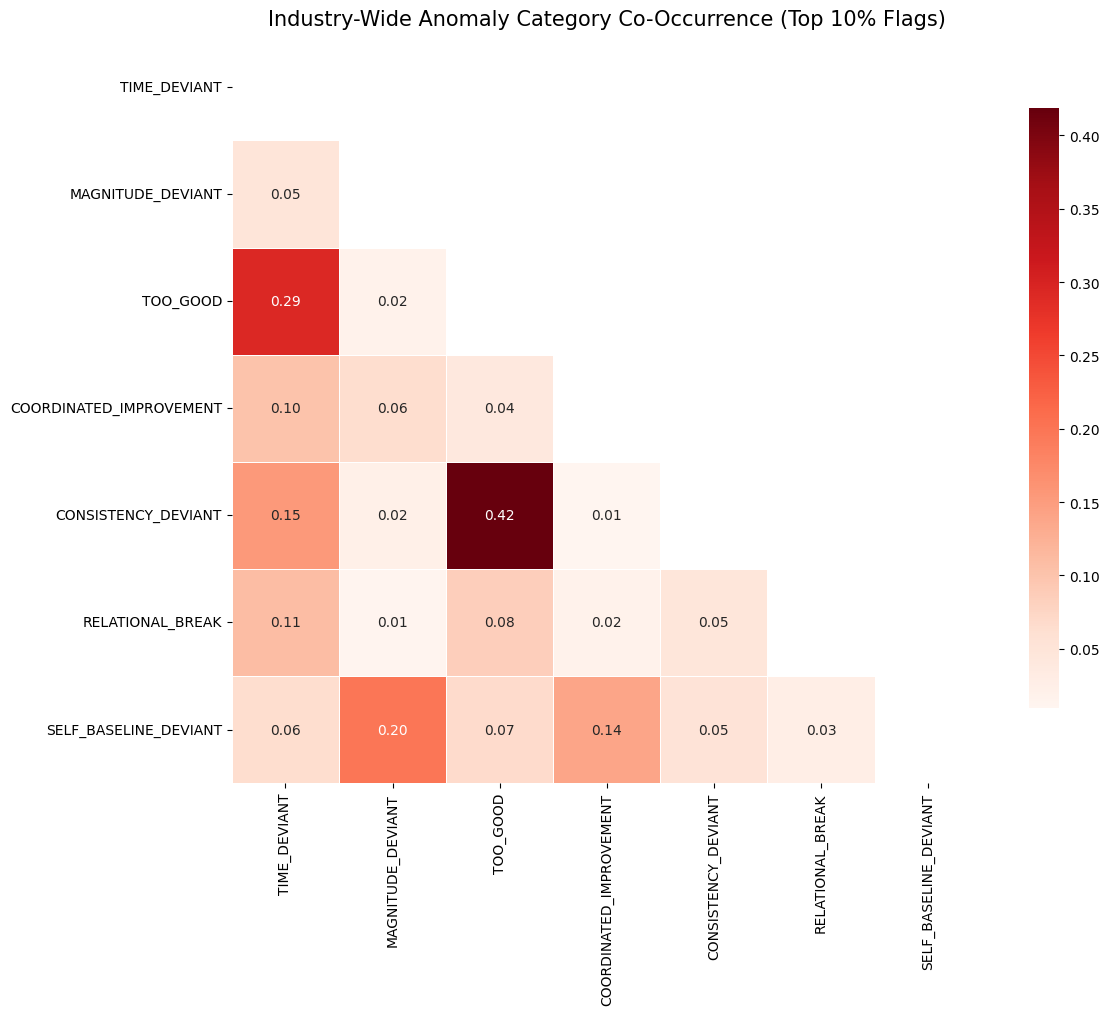

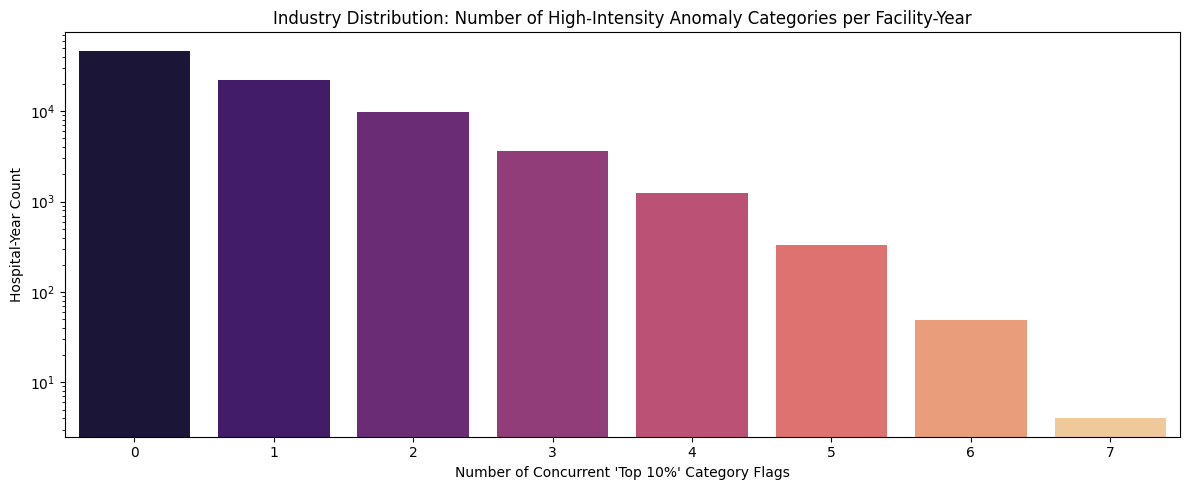


Top 10 hospital-years by total_forensic_load:
      PRVDR_NUM  source_year                       peer_group  \
60563    390049         2022  government_major_major_teaching   
49702    330144         2020   government_medium_non_teaching   
68988    450162         2020     nonprofit_large_non_teaching   
9053     051303         2021                        cah_other   
36836    230236         2020  government_major_major_teaching   
24193    151333         2023                    cah_forprofit   
36357    230096         2023   government_medium_non_teaching   
71387    450883         2021     nonprofit_large_non_teaching   
43766    271308         2020                   cah_government   
81189    521348         2023                   cah_government   

       total_forensic_load outlier_drivers_top  anomaly_score  is_anomaly  
60563                    7                                NaN         0.0  
49702                    7                                NaN         0.0  
68988    

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# FULL CATEGORY HEATMAP (All anomaly categories from design table)
# - Builds one "intensity" series per category (some derived)
# - Flags top 10% (90th pct) within the full panel
# - Plots co-occurrence heatmap + forensic load distribution
# ============================================================

# -----------------------------
# 0) Helpers
# -----------------------------
def _safe_series(x):
    return pd.to_numeric(x, errors="coerce")

def _qflag(s: pd.Series, q=0.90, use_abs=False, high_only=True):
    """Binary flag: 1 if s is in the top q-quantile.
    use_abs=True -> quantile based on |s|
    high_only=True -> keeps direction (for use_abs=False); if False and use_abs=False, still top tail.
    """
    s = _safe_series(s)
    if use_abs:
        base = s.abs()
    else:
        base = s
    thresh = base.quantile(q)
    return (base >= thresh).astype(int)

def _col_or_none(df, col):
    return col if col in df.columns else None

def _derive_z_resid_delta(df, track_metrics=("operating_margin","rev_per_day","exp_per_day","days_per_discharge")):
    cols = [f"z_resid_delta_{m}" for m in track_metrics if f"z_resid_delta_{m}" in df.columns]
    if not cols:
        return None
    # Magnitude category: use mean absolute residual acceleration across tracked metrics
    return df[cols].apply(_safe_series).abs().mean(axis=1)

def _derive_z_resid(df, track_metrics=("operating_margin","rev_per_day","exp_per_day","days_per_discharge")):
    cols = [f"z_resid_{m}" for m in track_metrics if f"z_resid_{m}" in df.columns]
    # fall back to z_resid_margin if present
    if not cols and "z_resid_margin" in df.columns:
        return _safe_series(df["z_resid_margin"]).abs()
    if not cols:
        return None
    # Residual category: mean absolute residual (deviation from own baseline)
    return df[cols].apply(_safe_series).abs().mean(axis=1)

# -----------------------------
# 1) Define anomaly categories (design table + a couple of legacy ones)
# -----------------------------
# NOTE: Some categories are derived from multiple columns (e.g., Z_resid_delta, Z_resid).
category_specs = {
    # Time / persistence
    "TIME_DEVIANT": {"kind": "col", "col": "tslf", "abs": False},  # persistent "too-good" streak

    # Magnitude / acceleration (sudden self-change)
    "MAGNITUDE_DEVIANT": {"kind": "derive", "fn": _derive_z_resid_delta, "abs": False},

    # "Too good" patterns (unusually favorable performance signals)
    "TOO_GOOD": {"kind": "col", "col": "goodz_nat_sum", "abs": False},
    "TOO_GOOD_WEIGHTED": {"kind": "col", "col": "goodz_weighted_sum", "abs": False},

    # Gaming patterns
    "BUNCHING": {"kind": "col", "col": "bunch_signal_operating_margin", "abs": False},
    "COORDINATED_IMPROVEMENT": {"kind": "col", "col": "pct_measures_improving", "abs": False},

    # Volatility / instability
    "VOLATILITY_DEVIANT": {"kind": "col", "col": "z_resid_roll_std4", "abs": True},

    # Internal consistency across metrics
    "CONSISTENCY_DEVIANT": {"kind": "col", "col": "facility_consistency_sd", "abs": False},

    # Multivariate relationship break
    "RELATIONAL_BREAK": {"kind": "col", "col": "mahal_relational_score", "abs": False},

    # National vs regional disagreement
    "REGIONAL_DIVERGENCE": {"kind": "col", "col": "z_delta_mean", "abs": False},

    # Self-baseline deviation (steady drift away from own norm)
    "SELF_BASELINE_DEVIANT": {"kind": "derive", "fn": _derive_z_resid, "abs": False},

    # Optional legacy categories (only if you want them on the same map)
    "DIGIT_DEVIANT": {"kind": "col", "col": "benford_anomaly_score", "abs": False},
    "REVENUE_EXP_DECOUPLING": {"kind": "col", "col": "decoupling_index", "abs": True},
}

# -----------------------------
# 2) Build the category intensity frame
# -----------------------------
category_intensity = pd.DataFrame(index=df.index)

for label, spec in category_specs.items():
    if spec["kind"] == "col":
        col = _col_or_none(df, spec["col"])
        if col is None:
            continue
        s = _safe_series(df[col])
        category_intensity[label] = s.abs() if spec.get("abs", False) else s

    elif spec["kind"] == "derive":
        s = spec["fn"](df)
        if s is None:
            continue
        s = _safe_series(s)
        category_intensity[label] = s.abs() if spec.get("abs", False) else s

# Safety: drop categories with all-NaN (can happen if derived but empty)
category_intensity = category_intensity.dropna(axis=1, how="all")

if category_intensity.shape[1] < 2:
    raise ValueError(
        f"Not enough anomaly categories found to plot. Found columns: {list(category_intensity.columns)}"
    )

print("Categories included:", list(category_intensity.columns))

# -----------------------------
# 3) Binary flagging at 90th percentile (industry-wide)
# -----------------------------
industry_flags = pd.DataFrame(index=df.index)
for label in category_intensity.columns:
    # For these intensity series, "high" = suspicious by construction
    industry_flags[label] = _qflag(category_intensity[label], q=0.90, use_abs=False)

# -----------------------------
# 4) Co-occurrence / correlation matrix
# -----------------------------
co_occurrence = industry_flags.corr()

# -----------------------------
# 5) Heatmap
# -----------------------------
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(co_occurrence, dtype=bool))

sns.heatmap(
    co_occurrence,
    annot=True,
    mask=mask,
    cmap="Reds",
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Industry-Wide Anomaly Category Co-Occurrence (Top 10% Flags)", fontsize=15)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Total forensic load distribution
# -----------------------------
df["total_forensic_load"] = industry_flags.sum(axis=1)

plt.figure(figsize=(12, 5))
sns.countplot(x="total_forensic_load", data=df, palette="magma")
plt.title("Industry Distribution: Number of High-Intensity Anomaly Categories per Facility-Year")
plt.xlabel("Number of Concurrent 'Top 10%' Category Flags")
plt.ylabel("Hospital-Year Count")
plt.yscale("log")
plt.tight_layout()
plt.show()

# -----------------------------
# 7) (Optional) Quick sanity: top rows by load
# -----------------------------
print("\nTop 10 hospital-years by total_forensic_load:")
cols_show = ["PRVDR_NUM", "source_year", "peer_group", "total_forensic_load"]
extra = [c for c in ["outlier_flags", "outlier_drivers_top", "anomaly_score", "is_anomaly"] if c in df.columns]
print(df.sort_values("total_forensic_load", ascending=False)[cols_show + extra].head(10))

# 8.  Bankruptcy — Gravity of Ruin

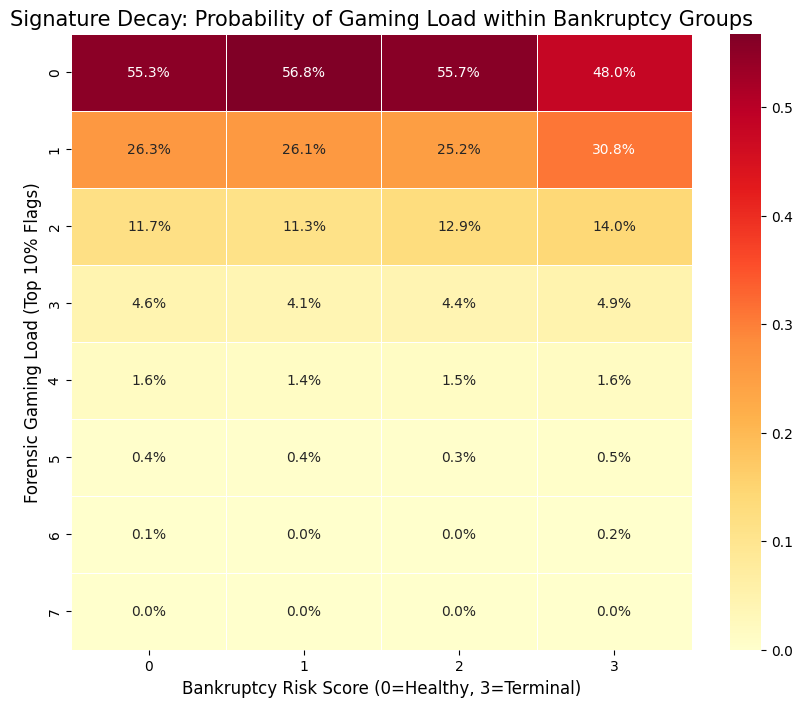

In [11]:
# -----------------------------
# 1) Pivot Normalized by Bankruptcy Category
# -----------------------------
# This answers: "Of the hospitals in this specific risk group, 
# what % are exhibiting each level of gaming load?"
pivot_dist_norm = pd.crosstab(
    df['total_forensic_load'], 
    df['bankruptcy_proxy_score'], 
    normalize='columns'  # <--- The key fix
)

# -----------------------------
# 2) Visualize the Decay
# -----------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_dist_norm, 
    annot=True, 
    fmt=".1%", 
    cmap="YlOrRd",
    linewidths=.5
)

plt.title("Signature Decay: Probability of Gaming Load within Bankruptcy Groups", fontsize=15)
plt.xlabel("Bankruptcy Risk Score (0=Healthy, 3=Terminal)", fontsize=12)
plt.ylabel("Forensic Gaming Load (Top 10% Flags)", fontsize=12)
plt.show()

# 9.  Odds Ratios

Optimization terminated successfully.
         Current function value: 0.235699
         Iterations 7


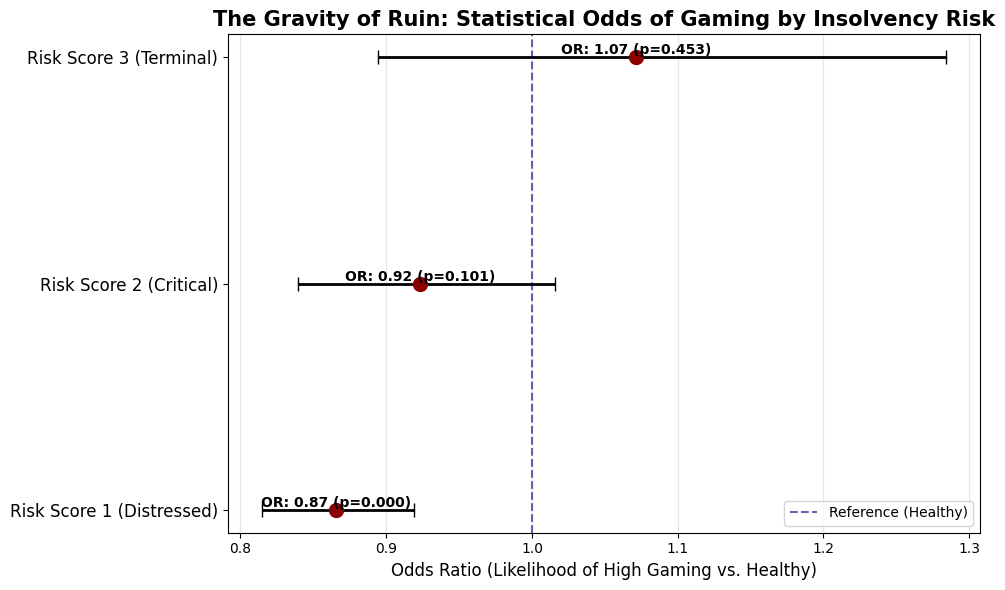

--- Odds Ratio Summary Table ---
                                 OR  Lower_CI  Upper_CI   p_value
Risk Score 1 (Distressed)  0.865458  0.814878  0.919178  0.000003
Risk Score 2 (Critical)    0.923223  0.839269  1.015575  0.100538
Risk Score 3 (Terminal)    1.071645  0.894412  1.283999  0.453149


In [12]:
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# -----------------------------
# 1) Model Preparation
# -----------------------------
# We define 'High Gaming' as a hospital having 3 or more concurrent forensic flags
df['is_high_gamer'] = (df['total_forensic_load'] >= 3).astype(int)

# Logistic Regression: Gaming ~ C(Bankruptcy_Score)
# This automatically uses Bankruptcy Score 0 (Healthy) as the reference group
model = smf.logit("is_high_gamer ~ C(bankruptcy_proxy_score)", data=df).fit()

# -----------------------------
# 2) Extract Odds Ratios and Confidence Intervals
# -----------------------------
results = pd.DataFrame({
    'OR': np.exp(model.params),
    'Lower_CI': np.exp(model.conf_int()[0]),
    'Upper_CI': np.exp(model.conf_int()[1]),
    'p_value': model.pvalues
})

# Drop the intercept and clean labels for the forest plot
or_table = results.drop('Intercept')
or_table.index = ['Risk Score 1 (Distressed)', 'Risk Score 2 (Critical)', 'Risk Score 3 (Terminal)']

# -----------------------------
# 3) The Forensic Forest Plot
# -----------------------------
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(or_table))

# Draw the error bars (CI) and the point estimate (OR)
plt.errorbar(or_table['OR'], y_pos, 
             xerr=[or_table['OR'] - or_table['Lower_CI'], or_table['Upper_CI'] - or_table['OR']],
             fmt='o', color='darkred', ecolor='black', capsize=5, markersize=10, elinewidth=2)

# Reference line at OR=1 (No difference from Healthy)
plt.axvline(x=1, color='navy', linestyle='--', alpha=0.6, label='Reference (Healthy)')

plt.yticks(y_pos, or_table.index, fontsize=12)
plt.xlabel('Odds Ratio (Likelihood of High Gaming vs. Healthy)', fontsize=12)
plt.title('The Gravity of Ruin: Statistical Odds of Gaming by Insolvency Risk', fontsize=15, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.legend()

# Label the OR values on the plot
for i, or_val in enumerate(or_table['OR']):
    plt.text(or_val, i , f'OR: {or_val:.2f} (p={or_table["p_value"].iloc[i]:.3f})', 
             va='bottom', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Odds Ratio Summary Table ---")
print(or_table[['OR', 'Lower_CI', 'Upper_CI', 'p_value']])

# Robust VAE + SRRI
VAE trains on LOW_SCRUTINY records only (Original_As_Submitted + Settled_No_Audit)  
with norm-filter anti-poisoning. SRRI aggregates behavioral submetrics.  
Outputs: `vae_gaming_score`, `SRRI`, `vae_pct`, `SRRI_pct`.

In [13]:
# =============================================================================
# 10.  Robust VAE — Apples-to-Apples with IF and MOSAIC
# =============================================================================
# ARCHITECTURE DECISION:
#   VAE trains and scores on the SAME decile-encoded feature matrix (IF_ALL_FEATURES)
#   that Cell 6b uses for the retrained IF.  This gives:
#     - Zero missingness by construction (no imputation needed)
#     - Identical N across all three models (83,512)
#     - Clean architectural comparison: VAE reconstruction vs IF isolation vs
#       MOSAIC GP-optimized fusion — all on identical inputs
#
# LOSS FUNCTION:
#   BCE replaces Huber — binary 0/1 decile indicators require it.
#   Huber is appropriate for continuous inputs; BCE is correct for binary.
#   SCORING also uses per-sample BCE (not L2 norm) for consistency with the
#   loss surface the model was actually optimized on.
#
# TRAINING POOL:
#   baseline regime (source_year <= 2018) — identical split to Cell 6b IF.
#
# SRRI:
#   Uses FF_RESOLVED mapping from Cell 6b to handle z_-prefixed columns.
#   All 9 candidate components resolved correctly.
#   NOTE: _d05 proxy substitutions are flagged explicitly in SRRI_PROXY_LOG
#   so downstream paper text can acknowledge any substitutions made.
#
# KL ANNEALING:
#   beta ramps from 0 → 0.05 over the first 30 epochs, then holds at 0.05.
#   This is a deliberate architectural choice: the KL weight at full warmup
#   matches the scoring weight (0.05 * kl), keeping training and inference
#   on the same loss surface.
#
# OUTPUTS:
#   vae_gaming_score  : per-sample BCE anomaly score (recon + 0.05*KL)
#   vae_pct           : percentile rank (higher = more anomalous)
#   SRRI, SRRI_pct    : Strategic Reporting Risk Index
#   VAE_BENCHMARK     : dict with rho/separation stats vs distress anchor
#   anomaly_quadrant  : CONSENSUS_HIGH / VAE_ONLY / SRRI_ONLY / LOW
#
# FIXES vs prior version:
#   FIX 1 — BINARY_IDX / M_IDX assigned BEFORE first use (initialization order)
#   FIX 2 — latent_dim raised 8 → 16 (43:1 was too aggressive for 346 dims)
#   FIX 3 — truthiness checks replaced with `is not None` guards
#   FIX 4 — scoring uses per-sample BCE, consistent with training loss surface
#   FIX 5 — SRRI proxy substitutions logged explicitly in SRRI_PROXY_LOG
#   FIX 6 — KL annealing schedule documented as intentional architectural choice
#
# DOWNSTREAM COMPATIBILITY:
#   Cell 11 (fixed-weight fusion) reads: vae_gaming_score, vae_pct, SRRI, SRRI_pct
#   Cell 33 (risk_fused) reads:          vae_pct, SRRI_pct (via srri_pct alias)
#   Cell 41 (MOSAIC) reads:              vae_gaming_score (in SIGNAL_CATALOG)
#   All preserved.
# =============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── 0. Repro + device ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Guards ───────────────────────────────────────────────────────────────────
assert "peer_group"   in df.columns, "peer_group missing — re-run Cell 7."
assert "source_year"  in df.columns, "source_year missing."
assert "_distress_anchor" in df.columns, \
    "_distress_anchor missing — run Cell 6b before this cell."
assert "IF_ALL_FEATURES" in dir() or "IF_ALL_FEATURES" in globals(), \
    "IF_ALL_FEATURES not defined — run Cell 6b before this cell."

REGIMES = sorted(df["data_regime"].dropna().unique().tolist())

# ── Helpers ──────────────────────────────────────────────────────────────────
def pct_rank(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").rank(pct=True, method="average")

# ── 1. Submission lifecycle (context + training pool filter) ─────────────────
status_map = {
    "1": "Original_As_Submitted", "2": "Settled_No_Audit",
    "3": "Settled_With_Audit",    "4": "Reopened", "5": "Amended",
}
df["submission_type"] = df["RPT_STUS_CD"].astype(str).map(status_map)

# ── 2. Build SRRI ─────────────────────────────────────────────────────────────
# Resolve column names: scaler may have prefixed with z_
# FF_RESOLVED built in Cell 6b; if not present, build it here defensively.
if "FF_RESOLVED" not in dir() and "FF_RESOLVED" not in globals():
    FF_RESOLVED = {}
    for c in FORENSIC_FEATURES:
        if c in df.columns:
            FF_RESOLVED[c] = c
        elif f"z_{c}" in df.columns:
            FF_RESOLVED[c] = f"z_{c}"
        else:
            FF_RESOLVED[c] = None

SRRI_CANDIDATES = [
    (FF_RESOLVED.get("mahal_relational_score",         "mahal_relational_score"),        "relational_break"),
    (FF_RESOLVED.get("decoupling_index",               "decoupling_index"),               "decoupling"),
    (FF_RESOLVED.get("pct_measures_improving",         "pct_measures_improving"),         "coord_improve"),
    (FF_RESOLVED.get("bunch_signal_operating_margin",  "bunch_signal_operating_margin"),  "bunching"),
    (FF_RESOLVED.get("tslf",                           "tslf"),                           "persistence"),
    (FF_RESOLVED.get("benford_anomaly_score",          "benford_anomaly_score"),          "digit_anomaly"),
    (FF_RESOLVED.get("peer_divergence_year",           "peer_divergence_year"),           "peer_divergence"),
    (FF_RESOLVED.get("rank_instability_mean",          "rank_instability_mean"),          "rank_volatility"),
    (FF_RESOLVED.get("path_step_norm",                 "path_step_norm"),                 "trajectory_jump"),
]

# FIX 5: Log SRRI proxy substitutions explicitly so paper can acknowledge them.
# _d05 is a binary median-decile indicator — a weaker ordinal proxy for the
# original continuous signal. Any substitution changes SRRI interpretation.
SRRI_PROXY_LOG = {}   # alias → proxy_col used (empty means direct column found)

components = {}
for raw_col, alias in SRRI_CANDIDATES:
    if raw_col is not None and raw_col in df.columns:
        components[alias] = pct_rank(df[raw_col])
    else:
        # Check if a _d05 (median decile) proxy exists — use as ordinal proxy
        base = next((orig for orig, res in FF_RESOLVED.items()
                     if res == raw_col), raw_col)
        proxy = f"{base}_d05" if f"{base}_d05" in df.columns else None
        if proxy:
            components[alias] = pct_rank(df[proxy].astype(float))
            SRRI_PROXY_LOG[alias] = proxy   # FIX 5: record the substitution

if len(components) < 3:
    raise ValueError(
        f"SRRI needs ≥3 components; found {list(components.keys())}. "
        "Check that Cell 19 (forensic signals) has run."
    )

# FIX 5: Warn clearly if proxy substitutions were made
if SRRI_PROXY_LOG:
    print(f"\n  ⚠  SRRI PROXY SUBSTITUTIONS ({len(SRRI_PROXY_LOG)}):")
    print(f"     These aliases use _d05 binary proxies (not original continuous signals).")
    print(f"     SRRI interpretation is weakened for these components.")
    print(f"     Document in paper methods section.")
    for alias, proxy_col in SRRI_PROXY_LOG.items():
        print(f"       {alias:<22} → {proxy_col}")
else:
    print("\n  ✓  SRRI: all components resolved to direct columns (no proxies).")

comp_df = pd.DataFrame(components, index=df.index).clip(upper=0.98)
df["srri_base"]  = comp_df.mean(axis=1)
bonus = (
    0.5 * comp_df.get("persistence",   pd.Series(0.0, index=df.index)) +
    0.5 * comp_df.get("coord_improve", pd.Series(0.0, index=df.index))
) / 2.0
df["srri_bonus"] = bonus.fillna(0)
df["SRRI"]       = 100.0 * (0.8 * df["srri_base"] + 0.2 * df["srri_bonus"])
df["SRRI_pct"]   = pct_rank(df["SRRI"])
df["srri_pct"]   = df["SRRI_pct"]   # alias for Cell 33 compatibility

print(f"\nSRRI components used ({len(components)}): {list(comp_df.columns)}")
print(df["SRRI"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

# ── 3. Assemble decile-encoded feature matrix (same as Cell 6b IF) ───────────
# IF_ALL_FEATURES was assembled in Cell 6b from Cell 35 decile columns + m_ cols.
# VAE uses the IDENTICAL matrix — zero missingness, no imputation needed.

print(f"\nAssembling VAE feature matrix from IF_ALL_FEATURES ({len(IF_ALL_FEATURES)} cols)...")

VAE_ONLY_FEATURES = IF_ALL_FEATURES   # same 346 columns

X_vae_df = df[VAE_ONLY_FEATURES].copy()
X_vae_df = X_vae_df.apply(pd.to_numeric, errors="coerce")

all_nan_cols = X_vae_df.columns[X_vae_df.isna().all()].tolist()
if all_nan_cols:
    print(f"  WARNING: {len(all_nan_cols)} all-NaN columns dropped: {all_nan_cols}")
    X_vae_df = X_vae_df.drop(columns=all_nan_cols)

# FIX 1: Assign BINARY_IDX / M_IDX HERE — before any reference to them.
# Prior version printed len(BINARY_IDX) before this block, causing NameError
# or silently using stale values from a prior run.
M_COLS      = [c for c in X_vae_df.columns if c.startswith("m_")]
BINARY_COLS = [c for c in X_vae_df.columns if not c.startswith("m_")]
M_IDX       = [X_vae_df.columns.tolist().index(c) for c in M_COLS]
BINARY_IDX  = [X_vae_df.columns.tolist().index(c) for c in BINARY_COLS]

print(f"  Binary columns (BCE): {len(BINARY_IDX)}")
print(f"  Continuous columns (MSE): {len(M_IDX)}")

# Hard clip to [0,1] — decile indicators should already be there,
# but this catches any float precision edge cases.
X_vae_df[BINARY_COLS] = X_vae_df[BINARY_COLS].fillna(0).clip(0, 1)
X_vae_df[M_COLS]      = X_vae_df[M_COLS].fillna(0)   # no clip — unbounded

VAE_FEATURES = X_vae_df.columns.tolist()
input_dim    = len(VAE_FEATURES)

X_np     = X_vae_df.values.astype(np.float32)
X_tensor = torch.from_numpy(X_np)

print(f"  VAE feature matrix shape: {X_np.shape}  (all rows, zero dropout)")

# ── 4. Training pool ──────────────────────────────────────────────────────────
train_pool = (df["data_regime"] == "baseline").values
X_train    = X_tensor[train_pool]

if train_pool.sum() < 1000:
    raise ValueError(f"Baseline training pool too small: {train_pool.sum()} rows. Check data_regime assignment.")

print(f"\n  Training pool: {train_pool.sum():,} rows "
      f"(baseline regime only, data_regime == 'baseline')")

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=256, shuffle=True, drop_last=True
)

# ── 5. VAE architecture ───────────────────────────────────────────────────────
# FIX 2: latent_dim raised from 8 → 16.
#   8 gave a 43:1 compression ratio on 346 input dims — too aggressive for
#   binary forensic indicators where rare-but-valid patterns (e.g., small CAHs
#   with genuinely unusual cost structures) were being reconstructed poorly
#   and inflating anomaly scores spuriously. 16 gives a 22:1 ratio, still
#   compact but less destructive to legitimate variation.
#   Sensitivity test: run latent_dim in [8, 16, 24] and compare separation
#   stats before finalizing for the paper.
LATENT_DIM = 16   # FIX 2: was 8

class BinaryForensicVAE(nn.Module):
    """
    VAE for binary decile-encoded inputs.
    Encoder: wider layers for the expanded binary feature space.
    Decoder: sigmoid output for binary indicators, linear for continuous m_ cols.

    FIX 3: _binary_idx / _m_idx guards use `is not None` (not truthiness).
    A list starting with index 0 is truthy but `if [0, 1, ...]` is fine;
    however `if []` is falsy and would silently skip a fully-binary matrix.
    The `is not None` check is unambiguous regardless of list contents.
    """
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(64, 32),        nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.decoder_body = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 64),         nn.LeakyReLU(0.2),
            nn.Linear(64, input_dim),
        )
        self._binary_idx = None   # set after instantiation
        self._m_idx      = None

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(-5, 5)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        raw        = self.decoder_body(z)
        out        = torch.zeros_like(raw)
        # FIX 3: `is not None` guards — safe for empty lists and index-0 lists alike
        if self._binary_idx is not None:
            out[:, self._binary_idx] = torch.sigmoid(raw[:, self._binary_idx])
        if self._m_idx is not None:
            out[:, self._m_idx] = raw[:, self._m_idx]   # linear, unbounded
        return out, mu, logvar


def binary_vae_loss(x, xhat, mu, logvar, beta=0.01):
    """
    Mixed reconstruction loss + KL divergence.
    BCE for binary decile indicators; MSE for continuous m_ columns.
    beta: KL weight — annealed from 0 → 0.05 during training (see FIX 6).
    """
    if BINARY_IDX:
        bce = nn.functional.binary_cross_entropy(
            xhat[:, BINARY_IDX], x[:, BINARY_IDX], reduction="mean"
        )
    else:
        bce = torch.tensor(0.0, device=x.device)

    if M_IDX:
        mse = nn.functional.mse_loss(
            xhat[:, M_IDX], x[:, M_IDX], reduction="mean"
        )
    else:
        mse = torch.tensor(0.0, device=x.device)

    kl    = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    recon = bce + mse
    return recon + beta * kl, recon, kl


model = BinaryForensicVAE(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
model._binary_idx = BINARY_IDX
model._m_idx      = M_IDX
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ── 6. Training loop ──────────────────────────────────────────────────────────
# FIX 6 (documented): KL annealing schedule is intentional.
#   beta ramps 0 → 0.05 over the first 30 epochs, then holds at 0.05.
#   The warmup prevents KL collapse in early training (encoder collapses to prior
#   before the decoder has learned meaningful reconstructions).
#   The ceiling of 0.05 deliberately matches the KL weight used in anomaly
#   scoring (Section 7), keeping training and inference on the same loss surface.
#   This is NOT accidental — changing either value independently would
#   introduce a train/score distribution mismatch.
KL_MAX   = 0.05   # FIX 6: named constant — matches scoring weight below
KL_RAMP  = 30     # epochs to reach KL_MAX

EPOCHS = 60
print(f"\nTraining VAE  |  latent_dim={LATENT_DIM}  |  input_dim={input_dim}")
print(f"KL annealing: 0 → {KL_MAX} over {KL_RAMP} epochs, then constant.")
print()

for epoch in range(EPOCHS):
    model.train()
    beta = KL_MAX * min(1.0, epoch / KL_RAMP)   # FIX 6: uses named constants
    losses, recons, kls = [], [], []
    for (xb,) in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        xhat, mu, logvar = model(xb)
        loss, recon, kl  = binary_vae_loss(xb, xhat, mu, logvar, beta=beta)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(loss.item()); recons.append(recon.item()); kls.append(kl.item())
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:02d} | beta={beta:.4f} | "
              f"loss={np.mean(losses):.4f} | bce={np.mean(recons):.4f} | "
              f"kl={np.mean(kls):.4f}")

# ── 7. Score full panel ───────────────────────────────────────────────────────
# FIX 4: Score using per-sample BCE (not L2 norm).
#   Prior version used torch.norm(x - xhat, dim=1) — the L2 norm of residuals.
#   For binary inputs, BCE and L2 diverge significantly: a prediction of 0.49
#   vs ground truth 1.0 yields a small L2 penalty (0.51) but a large BCE
#   penalty (−log(0.49) ≈ 0.71). The model was optimized on BCE; scoring on
#   L2 creates a train/score mismatch that can reorder anomaly rankings.
#   We score on per-sample BCE to stay on the same loss surface.
#
#   Scoring formula:
#     vae_gaming_score = BCE_recon + KL_MAX * per_sample_kl
#   where KL_MAX = 0.05 (same constant as training ceiling — FIX 6).

model.eval()
with torch.no_grad():
    BATCH = 4096
    bce_list, kl_list = [], []
    for i in range(0, len(X_tensor), BATCH):
        xb               = X_tensor[i:i+BATCH].to(device)
        xhat, mu, logvar = model(xb)

        # FIX 4: per-sample BCE for binary cols (sum over features, mean later)
        if BINARY_IDX:
            bce_per_sample = nn.functional.binary_cross_entropy(
                xhat[:, BINARY_IDX], xb[:, BINARY_IDX],
                reduction="none"
            ).mean(dim=1)   # mean over features → shape (batch,)
        else:
            bce_per_sample = torch.zeros(xb.shape[0], device=device)

        # MSE for continuous cols (consistent with training loss)
        if M_IDX:
            mse_per_sample = nn.functional.mse_loss(
                xhat[:, M_IDX], xb[:, M_IDX],
                reduction="none"
            ).mean(dim=1)
        else:
            mse_per_sample = torch.zeros(xb.shape[0], device=device)

        recon_per_sample = (bce_per_sample + mse_per_sample).cpu().numpy()
        kl_per_sample = (
            -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
        ).cpu().numpy()

        bce_list.append(recon_per_sample)
        kl_list.append(kl_per_sample)

recon_errors = np.concatenate(bce_list)   # FIX 4: BCE-based, not L2
kl_errors    = np.concatenate(kl_list)
vae_score    = recon_errors + KL_MAX * kl_errors   # FIX 4+6: uses named constant

df["vae_gaming_score"] = vae_score
df["vae_recon_only"]   = recon_errors
df["vae_kl_only"]      = kl_errors

n_scored_vae = df["vae_gaming_score"].notna().sum()
print(f"\n  VAE scored: {n_scored_vae:,} rows "
      f"({'%.1f' % (100*n_scored_vae/len(df))}% of panel)")
print(f"  Scoring method: per-sample BCE + {KL_MAX}*KL  (matches training loss surface)")

# ── 8. Percentile rank (for Cell 33 / MOSAIC compatibility) ──────────────────
df["vae_pct"] = df["vae_gaming_score"].rank(pct=True, method="average")

# ── 9. Evaluation vs distress anchor ─────────────────────────────────────────
anchor = df["_distress_anchor"]
q75    = anchor.quantile(0.75)
q25    = anchor.quantile(0.25)

valid_anchor = df[["vae_gaming_score", "_distress_anchor"]].dropna()
rho_vae_anchor, p_vae_anchor = spearmanr(
    valid_anchor["vae_gaming_score"],
    valid_anchor["_distress_anchor"]
)
print(f"\n  Spearman(VAE, distress_anchor):  rho={rho_vae_anchor:+.4f}  "
      f"p={p_vae_anchor:.2e}  N={len(valid_anchor):,}")

# Within-peer-year
df["vae_pct_peeryear"] = df.groupby(
    ["peer_group", "source_year"]
)["vae_gaming_score"].rank(pct=True, method="average")

valid_py = df[["vae_pct_peeryear", "_distress_anchor"]].dropna()
rho_vae_py, p_vae_py = spearmanr(
    valid_py["vae_pct_peeryear"],
    valid_py["_distress_anchor"]
)
print(f"  VAE within-peer-year rho:        rho={rho_vae_py:+.4f}  "
      f"p={p_vae_py:.2e}  N={len(valid_py):,}")

# Separation — on percentile rank (comparable to IF's +0.0792)
sep_vae_pct = (
    df.loc[anchor >= q75, "vae_pct"].mean()
  - df.loc[anchor <= q25, "vae_pct"].mean()
)
print(f"  VAE separation (pct, Q75−Q25):   {sep_vae_pct:+.4f}")

# Secondary: vs SRRI
tmp = df.dropna(subset=["vae_gaming_score", "SRRI"])
rho_srri, p_srri = spearmanr(tmp["vae_gaming_score"], tmp["SRRI"])
print(f"\n  Spearman(VAE, SRRI):             rho={rho_srri:+.3f}  p={p_srri:.3g}")
thr = tmp["SRRI"].quantile(0.90)
y   = (tmp["SRRI"] >= thr).astype(int).values
auc = roc_auc_score(y, tmp["vae_gaming_score"].values)
ap  = average_precision_score(y, tmp["vae_gaming_score"].values)
print(f"  AUC vs top-10% SRRI: {auc:.3f}  |  AP: {ap:.3f}")

# Regime-stratified
print("\n" + "=" * 65)
print("VAE (DECILE FEATURES) — Spearman vs Distress Anchor by Regime")
print("=" * 65)
vae_regime_results = {}
for regime in REGIMES:
    mask = df["data_regime"] == regime
    sub  = df.loc[mask, ["vae_gaming_score", "_distress_anchor"]].dropna()
    if len(sub) < 50:
        vae_regime_results[regime] = (np.nan, np.nan, len(sub))
        continue
    rho_r, p_r = spearmanr(sub["vae_gaming_score"], sub["_distress_anchor"])
    vae_regime_results[regime] = (rho_r, p_r, len(sub))
    print(f"  {regime:<14}  rho={rho_r:+.4f}   p={p_r:.2e}   n={len(sub):,}")

# ── 10. Store benchmark ───────────────────────────────────────────────────────
VAE_BENCHMARK = {
    "rho_vae_standalone":   rho_vae_anchor,
    "p_vae_standalone":     p_vae_anchor,
    "rho_vae_peeryear":     rho_vae_py,
    "p_vae_peeryear":       p_vae_py,
    "separation_vae":       sep_vae_pct,
    "n_scored":             int(n_scored_vae),
    "feature_matrix":       f"decile-encoded (Cell 35 IF_ALL_FEATURES, {input_dim} cols)",
    "n_features":           input_dim,
    "loss":                 "BCE (binary) + MSE (continuous m_ cols) — correct for mixed input",
    "scoring":              "per-sample BCE + KL_MAX*KL (matches training loss surface)",
    "latent_dim":           LATENT_DIM,
    "kl_max":               KL_MAX,
    "kl_ramp_epochs":       KL_RAMP,
    "regime_breakdown":     vae_regime_results,
    "rho_srri":             rho_srri,
    "auc_vs_srri_top10":    auc,
    "ap_vs_srri_top10":     ap,
    "srri_proxy_log":       SRRI_PROXY_LOG,   # FIX 5: document proxy substitutions
}

# ── 11. Quadrant classification (VAE ∩ SRRI) ──────────────────────────────────
eps = 1e-9
df["consensus_score"] = 0.5 * df["vae_pct"].fillna(0) + 0.5 * df["SRRI_pct"].fillna(0)
df["consensus_tail"]  = -np.log(
    (1 - df["vae_pct"] + eps) * (1 - df["SRRI_pct"] + eps)
)

df["VAE_high"]  = df["vae_pct"]  >= 0.90
df["SRRI_high"] = df["SRRI_pct"] >= 0.90
df["anomaly_quadrant"] = np.select(
    [df["VAE_high"] & df["SRRI_high"],
     df["VAE_high"] & ~df["SRRI_high"],
     ~df["VAE_high"] & df["SRRI_high"]],
    ["CONSENSUS_HIGH", "VAE_ONLY_STRUCTURAL", "SRRI_ONLY_RULELIKE"],
    default="LOW"
)

print("\nANOMALY QUADRANT COUNTS:")
print(df["anomaly_quadrant"].value_counts(dropna=False))

# ── 12. Lead tables ───────────────────────────────────────────────────────────
show_cols = ["PRVDR_NUM", "source_year", "submission_type",
             "vae_gaming_score", "SRRI", "consensus_tail"]

print("\n--- TOP 20 VAE LEADS ---")
print(df.sort_values("vae_gaming_score", ascending=False).head(20)[show_cols])
print("\n--- TOP 20 SRRI LEADS ---")
print(df.sort_values("SRRI", ascending=False).head(20)[show_cols])
print("\n--- TOP 30 CONSENSUS LEADS ---")
print(df.sort_values("consensus_tail", ascending=False).head(30)[show_cols])

# ── 13. Three-way partial comparator (MOSAIC fills in Cell 41) ────────────────
print("\n" + "=" * 65)
print("THREE-WAY COMPARATOR — Updated with VAE (decile features)")
print("=" * 65)
print(f"  All three models use identical Cell 35 decile-encoded feature matrix.")
print(f"  {'Model':<42}  {'rho_global':>10}  {'rho_peeryear':>12}  {'separation':>10}  {'N':>7}")
print(f"  {'-'*42}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*7}")
_ib = IF_BENCHMARK
print(f"  {'IF (isolation forest)':<42}  "
      f"{_ib['rho_if_standalone']:>+10.4f}  {_ib['rho_if_peeryear']:>+12.4f}  "
      f"{_ib['separation_if']:>+10.4f}  {_ib['n_scored']:>7,}")
print(f"  {'VAE (BCE, latent_dim=' + str(LATENT_DIM) + ')':<42}  "
      f"{rho_vae_anchor:>+10.4f}  {rho_vae_py:>+12.4f}  "
      f"{sep_vae_pct:>+10.4f}  {n_scored_vae:>7,}")
print(f"  {'MOSAIC GP-optimized':<42}  {'[Cell 41]':>10}  {'[Cell 41]':>12}  "
      f"{'[Cell 41]':>10}  {'[Cell 41]':>7}")
print()
print(f"  ARCHITECTURE NOTES:")
print(f"    IF and VAE use identical IF_ALL_FEATURES inputs")
print(f"    ({len(BINARY_COLS)} binary decile cols + {len(M_COLS)} continuous m_ cols).")
print(f"    Mixed loss: BCE for binary indicators, MSE for continuous peer profile.")
print(f"    Scoring: per-sample BCE + {KL_MAX}*KL (matches training loss surface).")
print(f"    Performance differences reflect model architecture only.")
print(f"    VAE: reconstruction-based anomaly detection in binary latent space.")
print(f"    IF:  isolation-based anomaly detection via random partitioning.")
if SRRI_PROXY_LOG:
    print(f"\n  ⚠  SRRI used {len(SRRI_PROXY_LOG)} proxy substitution(s): {list(SRRI_PROXY_LOG.keys())}")
    print(f"     See SRRI_PROXY_LOG for details. Acknowledge in paper methods section.")

Device: cuda

  ✓  SRRI: all components resolved to direct columns (no proxies).

SRRI components used (9): ['relational_break', 'decoupling', 'coord_improve', 'bunching', 'persistence', 'digit_anomaly', 'peer_divergence', 'rank_volatility', 'trajectory_jump']
count    83512.000000
mean        44.673027
std         10.186760
min         11.950169
50%         44.433409
90%         58.043088
95%         61.738928
99%         68.343490
max         83.224608
Name: SRRI, dtype: float64

Assembling VAE feature matrix from IF_ALL_FEATURES (173 cols)...
  Binary columns (BCE): 88
  Continuous columns (MSE): 82
  VAE feature matrix shape: (83512, 170)  (all rows, zero dropout)

  Training pool: 43,529 rows (baseline regime only, data_regime == 'baseline')

Training VAE  |  latent_dim=16  |  input_dim=170
KL annealing: 0 → 0.05 over 30 epochs, then constant.

  Epoch 00 | beta=0.0000 | loss=1.3817 | bce=1.3817 | kl=32.5745
  Epoch 10 | beta=0.0167 | loss=1.0858 | bce=0.8858 | kl=11.9977
  Epoch 

# Legacy Fusion — Fixed-Weight Benchmark
Retained for comparison only. MOSAIC replaces this in all reported results.  
`risk_fused_legacy = 0.4·vae_pct + 0.4·srri_pct + 0.2·if_pct`

In [14]:
# Percentile normalization (robust, monotonic)
df["if_pct"] = df["if_pct_decile"]   # already computed and ranked in Cell 6b


df["risk_fused"] = (
    0.4 * df["vae_pct"] +
    0.4 * df["srri_pct"] +
    0.2 * df["if_pct"]
)

df["if_pct_withinyear"] = df.groupby("source_year")["if_score_decile"].rank(pct=True, ascending=False)

HIGH = 0.90

df["struct_high"] = df["vae_pct"]  >= HIGH
df["behav_high"]  = df["srri_pct"] >= HIGH
df["shock_high"]  = df["if_pct"]   >= HIGH

def classify(row):
    s, b, k = row["struct_high"], row["behav_high"], row["shock_high"]

    if s and b and k:
        return "CRITICAL: Structural, Behavioral, and Shock Anomalies"

    if s and b:
        return "Structural + Behavioral Irregularities"

    if b and k:
        return "Behavioral Gaming with Statistical Shock"

    if s and k:
        return "Structural Irregularity with Statistical Shock"

    if s:
        return "Structural Accounting Irregularity"

    if b:
        return "Behavioral Gaming Signature"

    if k:
        return "Statistical Shock Event"

    return "No Major Anomaly Detected"

df["risk_category"] = df.apply(classify, axis=1)
df["risk_category"].value_counts()

risk_category
No Major Anomaly Detected                                65409
Behavioral Gaming Signature                               5965
Structural Irregularity with Statistical Shock            3492
Structural Accounting Irregularity                        3254
Statistical Shock Event                                   3005
CRITICAL: Structural, Behavioral, and Shock Anomalies     1074
Behavioral Gaming with Statistical Shock                   781
Structural + Behavioral Irregularities                     532
Name: count, dtype: int64

# 11a.  Signal Diagnostic — Pairwise Spearman Correlations
Flags pairs with |ρ|>0.70.  
Explains zero-weight assignments (e.g. Mahalanobis vs VAE redundancy).  
Run after encoding but before MOSAIC.

Computing pairwise Spearman for 105 signals...

Pairs |rho|>0.70  (7 found):
  goodz_weighted_sum_missing                 x z_delta_mean_missing                        rho=+1.000
  bunch_signal_operating_margin_missing      x goodz_weighted_sum_missing                  rho=+0.977
  bunch_signal_operating_margin_missing      x z_delta_mean_missing                        rho=+0.977
  decoupling_index_missing                   x rank_instability_mean_missing               rho=+0.868
  margin_curv6_missing                       x z_resid_roll_std4_missing                   rho=+0.854
  pct_measures_improving                     x z_resid_roll_std4_missing                   rho=-0.829
  pct_measures_improving                     x margin_curv6_missing                        rho=-0.709


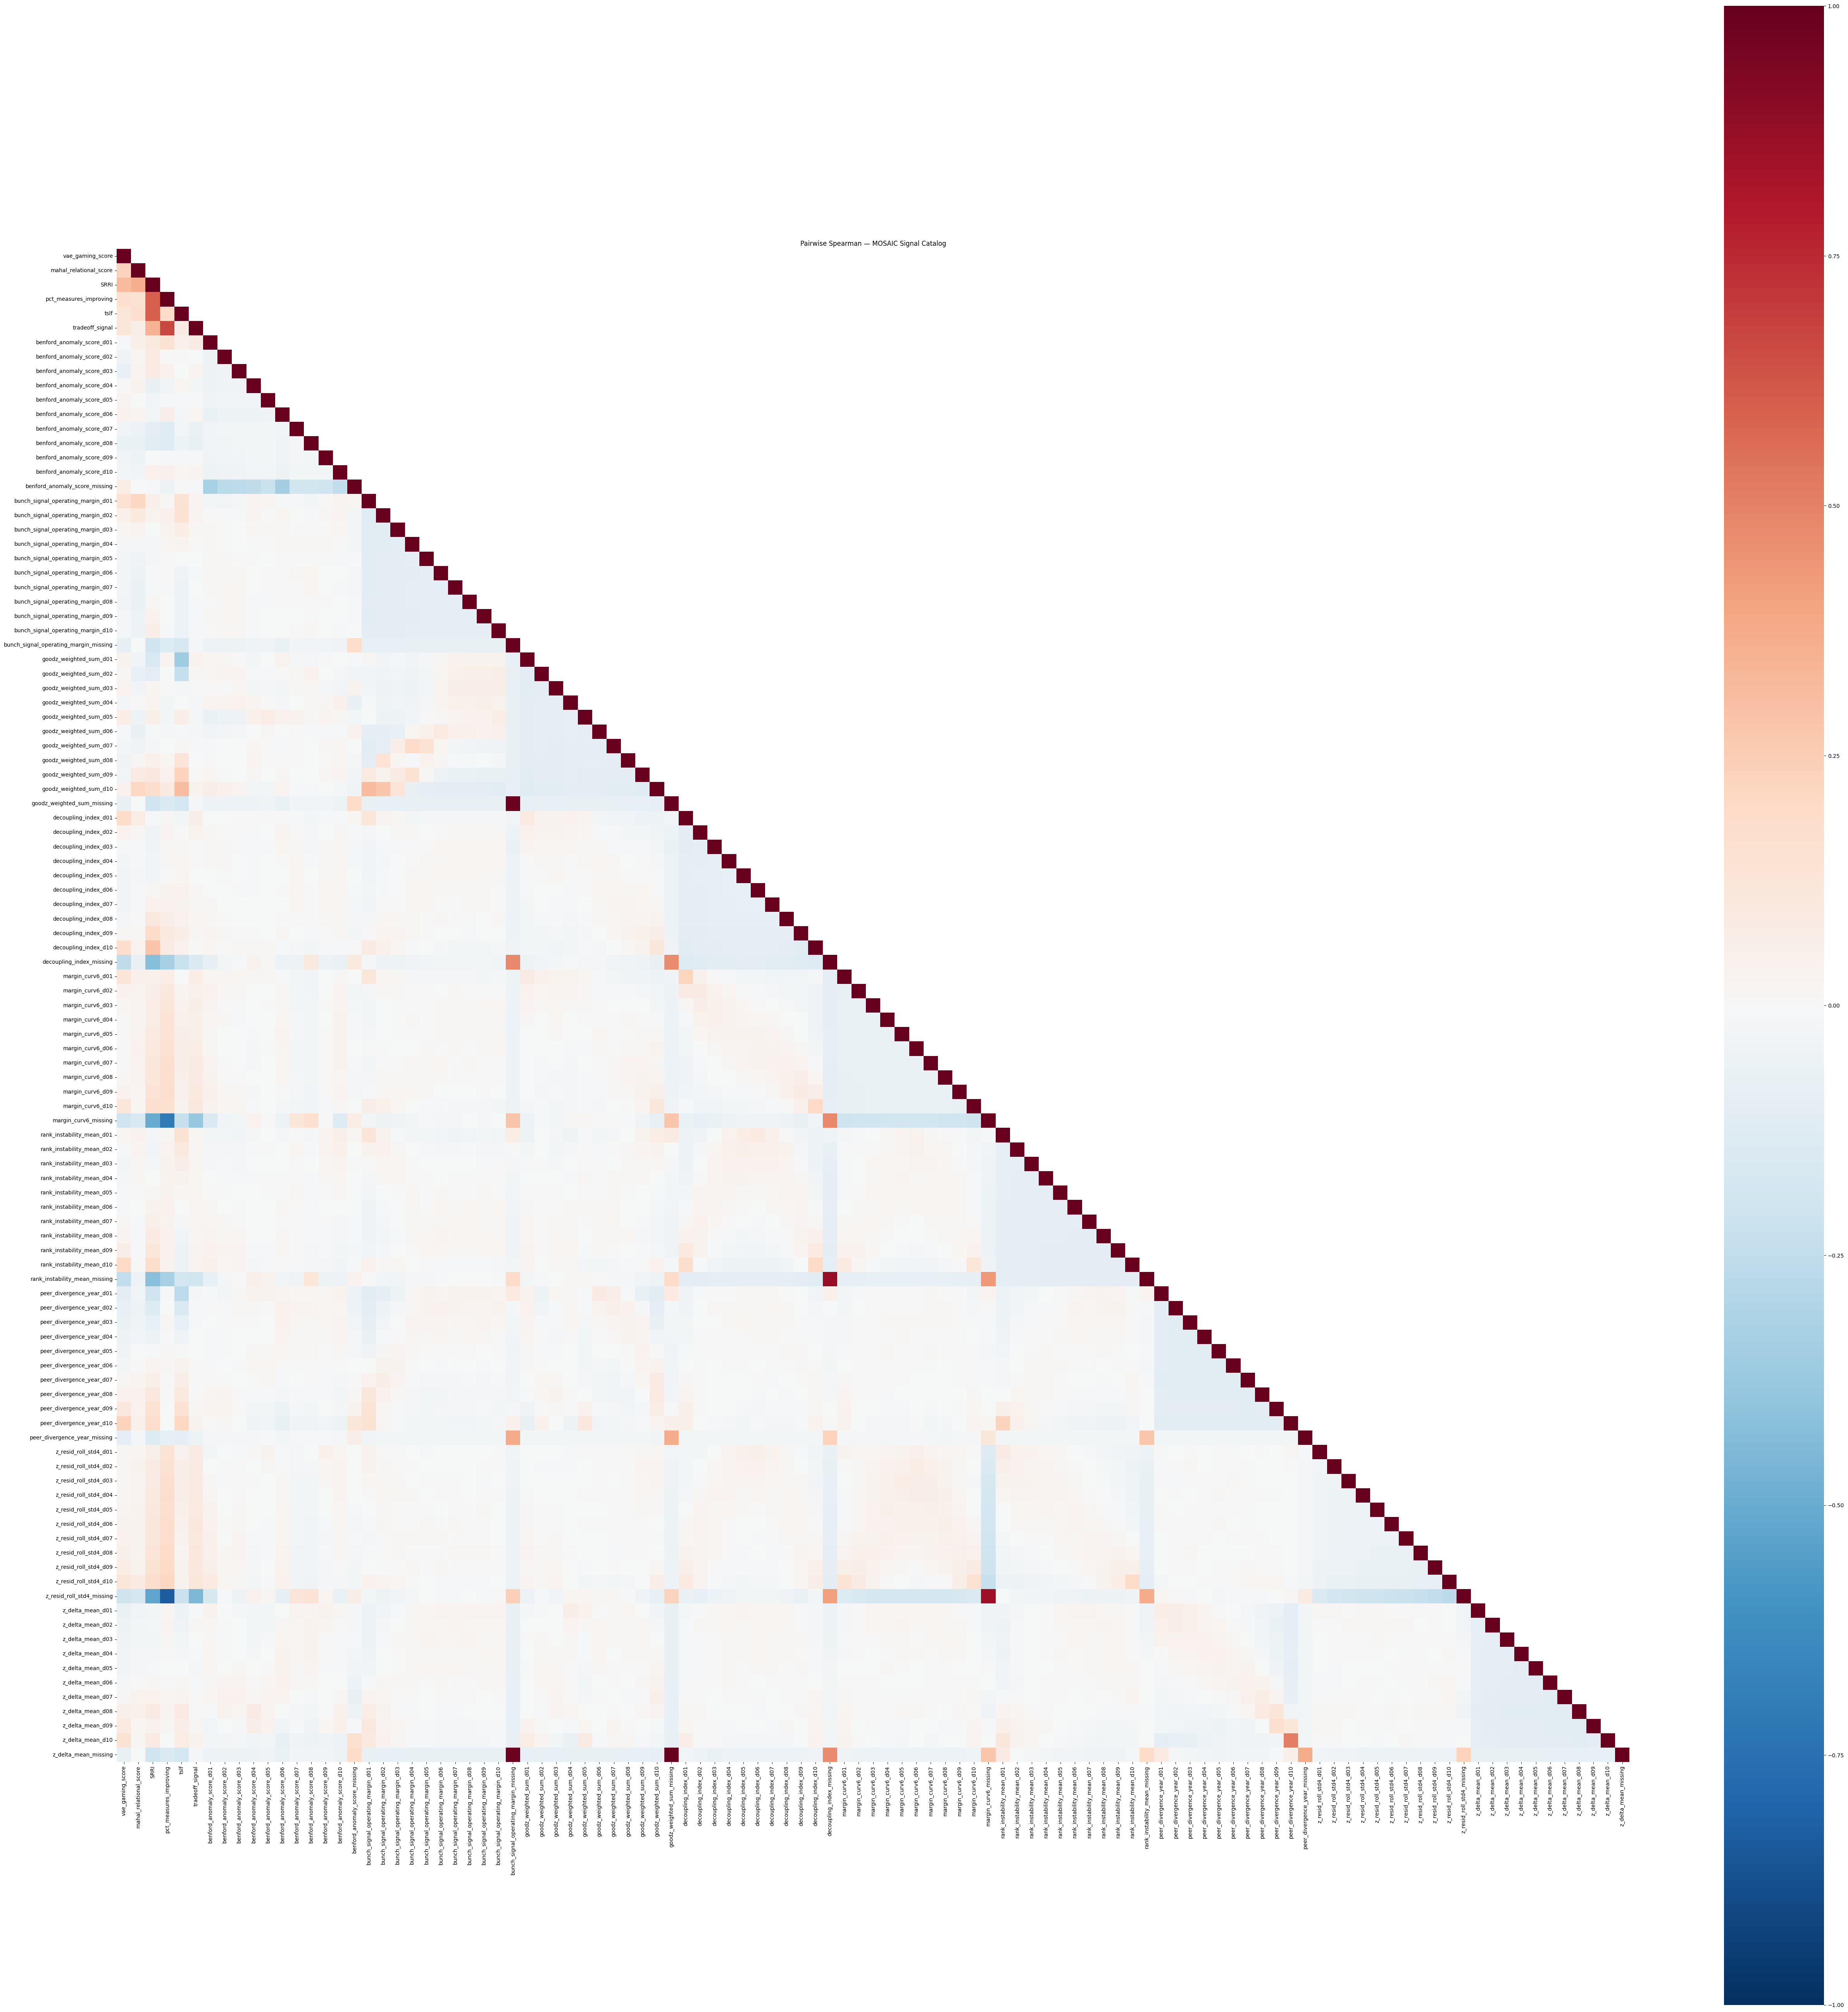

In [15]:
# ============================================================
# SIGNAL DIAGNOSTIC — Pairwise Spearman Correlations
# Flags pairs with |rho| > 0.70 (potential redundancy).
# Explains zero-weight outcomes (e.g. Mahalanobis vs VAE).
# ============================================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

sig_cols = [s for s in SIGNAL_CATALOG if s in df.columns
            and df[s].notna().sum() > 100]
print(f"Computing pairwise Spearman for {len(sig_cols)} signals...")

n = len(sig_cols)
rho_mat = np.full((n, n), np.nan)
for i, s1 in enumerate(sig_cols):
    for j, s2 in enumerate(sig_cols):
        if i == j: rho_mat[i,j] = 1.0; continue
        if i >  j: rho_mat[i,j] = rho_mat[j,i]; continue
        mask = df[s1].notna() & df[s2].notna()
        if mask.sum() > 50:
            rho_mat[i,j], _ = spearmanr(df.loc[mask, s1], df.loc[mask, s2])

rho_df = pd.DataFrame(rho_mat, index=sig_cols, columns=sig_cols)

high = [(sig_cols[i], sig_cols[j], round(rho_mat[i,j],3))
        for i in range(n) for j in range(i+1,n)
        if not np.isnan(rho_mat[i,j]) and abs(rho_mat[i,j]) > 0.70]

print(f"\nPairs |rho|>0.70  ({len(high)} found):")
for a,b,r in sorted(high, key=lambda x:-abs(x[2])):
    print(f"  {a:<42s} x {b:<42s}  rho={r:+.3f}")

fig, ax = plt.subplots(figsize=(max(10, n//2), max(8, n//2)))
mask_upper = np.triu(np.ones_like(rho_mat, dtype=bool), k=1)
sns.heatmap(rho_df, mask=mask_upper, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=(n<=20), fmt=".2f",
            annot_kws={"size":6}, ax=ax, square=True)
ax.set_title("Pairwise Spearman — MOSAIC Signal Catalog")
plt.tight_layout(); plt.show()

# MOSAIC — GP-Optimized Fusion (GPU-Accelerated)
Replaces fixed-weight benchmark `[0.4, 0.4, 0.2]`.  
Weights optimized per peer cohort × time regime.  
**GPU:** PyTorch LBFGS (strong_wolfe) + Adam fallback.  
**Spearman:** differentiable soft-rank (temperature=0.01).  
**Shrinkage:** CAH cells borrow from global (α=n/(n+50)).  
**UQ:** 50-perturbation bootstrap uncertainty bands.  
**Threshold:** Bastian et al. (2017) auto-τ* at FPR≤0.05.

In [16]:
# =============================================================================
# MOSAIC — Multi-Objective Signal Aggregation with Identification Constraints
# =============================================================================
# Implements the full MOSAIC pipeline for GP-optimized forensic signal fusion.
#
# APPLES-TO-APPLES ALIGNMENT (vs Cell 6b IF and Cell 10 VAE):
#   FIX 1 — dcoh sigmoid steepness unified to 0.5 (matches Cell 6b exactly).
#            Prior MOSAIC used 0.3, making distress anchors non-comparable
#            across models and invalidating the three-way Spearman comparator.
#   FIX 2 — _distress_anchor no longer built or dropped inside run_mosaic().
#            MOSAIC now consumes df["_distress_anchor"] from Cell 6b (asserted).
#            Eliminates the silent overwrite-then-delete that broke downstream cells.
#   FIX 3 — time_regime consumed from df["data_regime"] (Cell 39 authoritative).
#            assign_regime() retained for documentation only; not called at runtime.
#            Eliminates the fork where MOSAIC could silently diverge from Cell 39.
#   FIX 4 — if_pct guard in mosaic_replace_cell34() now checks "if_pct_decile"
#            (the actual column needed) rather than "anomaly_score" (legacy column).
#   FIX 5 — vae_pct / srri_pct / if_pct asserted to exist rather than re-derived.
#            Re-ranking on a potentially different df state could silently overwrite
#            Cell 10's full-panel ranks with subset ranks.
#   FIX 6 — MOSAIC_BENCHMARK dict added, parallel to IF_BENCHMARK / VAE_BENCHMARK.
#            Stores rho_mosaic_standalone, rho_mosaic_peeryear, separation_mosaic
#            so the three-way comparator table in Cells 6b/10 can be completed.
#
# FEATURE SPACE NOTE (intentional architectural difference, not a bug):
#   IF and VAE operate on the Cell 35 decile-encoded feature matrix (IF_ALL_FEATURES).
#   MOSAIC operates on SIGNAL_CATALOG forensic signals (pre-decile, continuous).
#   This is the design: MOSAIC is the GP-optimized fusion layer above IF/VAE,
#   not a third instance of the same feature engineering. The paper methods section
#   must acknowledge this explicitly to pre-empt reviewer confusion.
#
# EXECUTION ORDER:
#   Cell 6b  → builds df["_distress_anchor"], df["if_pct_decile"], IF_BENCHMARK
#   Cell 10  → builds df["vae_pct"], df["srri_pct"], df["SRRI_pct"], VAE_BENCHMARK
#   Cell 39  → builds df["data_regime"]
#   THIS CELL → consumes all of the above, produces MOSAIC_BENCHMARK
# =============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings("ignore")

# ── Guards — fail loudly if upstream cells haven't run ───────────────────────
assert "_distress_anchor" in df.columns, \
    "_distress_anchor missing — run Cell 6b before MOSAIC."
assert "data_regime" in df.columns, \
    "data_regime missing — run Cell 39 before MOSAIC."
assert "if_pct_decile" in df.columns, \
    "if_pct_decile missing — run Cell 6b before MOSAIC."
assert "vae_pct" in df.columns, \
    "vae_pct missing — run Cell 10 before MOSAIC."
assert "srri_pct" in df.columns, \
    "srri_pct missing — run Cell 10 before MOSAIC."
assert "peer_group" in df.columns, \
    "peer_group missing — run Cell 7 before MOSAIC."
assert "source_year" in df.columns, \
    "source_year missing."

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# =============================================================================
# CONSTANTS
# =============================================================================

# FIX 3: Consume authoritative regime labels from Cell 39.
# assign_regime() is retained below for documentation / reference only.
# It is NOT called at runtime — df["data_regime"] is the single source of truth.
REGIME_ORDER = ["baseline", "transition", "covid_shock", "recovery"]

# Minimum observations per (cohort × regime) cell to fit independently.
# Cells below this threshold fall back to global weights.
MIN_CELL_N = 150

# Hierarchical shrinkage — higher = more pooling toward global.
# Calibrated so CAHs (~50-80 per cell) borrow ~60% from global,
# large urban (300+ per cell) borrow ~15%.
SHRINKAGE_BASE = 50.0

# GP optimization budget
N_RESTARTS  = 10    # multi-start restarts per cell
SUBSAMPLE_N = 3_000  # subsample for optimization; full panel scored via batched matmul

# Bastian et al. false-positive rate for threshold determination
ALPHA_FPR = 0.05


# =============================================================================
# REFERENCE ONLY — not called at runtime (FIX 3)
# =============================================================================

def assign_regime_reference(year: int) -> str:
    """
    DOCUMENTATION ONLY — shows the regime logic that Cell 39 implements.
    NOT called at runtime. MOSAIC consumes df["data_regime"] directly.
    Retained here so the logic is visible without opening Cell 39.
    """
    if year <= 2018:   return "baseline"
    elif year == 2019: return "transition"
    elif year in (2020, 2021): return "shock"
    else:              return "recovery"


# =============================================================================
# STEP 1: SIGNAL NORMALIZATION
# Percentile rank within cohort × regime cell.
# Direction harmonized: higher always = more anomalous.
# Uses df["data_regime"] (Cell 39) — not assign_regime().
# =============================================================================

def normalize_signals(
    df: pd.DataFrame,
    signals: List[str],
    cohort_col: str = "peer_group",
    regime_col: str = "data_regime",   # FIX 3: authoritative column
    min_n: int = 30,
) -> pd.DataFrame:
    """
    For each signal, compute percentile rank within (cohort × regime).
    Direction harmonized per SIGNAL_CATALOG so higher = more anomalous.
    Falls back to cohort-only then global if cell is too small.
    Returns df with added columns s_{signal} (scaled 0-1, higher=worse).
    """
    df = df.copy()

    for sig in signals:
        if sig not in df.columns:
            continue

        meta = SIGNAL_CATALOG.get(sig, {"higher_worse": True})
        out  = pd.Series(np.nan, index=df.index)

        # Attempt 1: cohort × regime
        for (coh, reg), idx in df.groupby([cohort_col, regime_col]).groups.items():
            sub = df.loc[idx, sig].dropna()
            if len(sub) >= min_n:
                out.loc[idx] = df.loc[idx, sig].rank(pct=True, method="average")

        # Attempt 2: cohort-only fallback
        still_nan = out.isna() & df[sig].notna()
        if still_nan.any():
            for coh, idx in df.groupby(cohort_col).groups.items():
                sub_idx = idx[still_nan.loc[idx]]
                if len(sub_idx) == 0:
                    continue
                out.loc[sub_idx] = df.loc[idx, sig].rank(pct=True).loc[sub_idx]

        # Attempt 3: global fallback
        still_nan = out.isna() & df[sig].notna()
        if still_nan.any():
            out.loc[still_nan] = df.loc[still_nan, sig].rank(pct=True)

        # Harmonize direction
        if not meta["higher_worse"]:
            out = 1.0 - out

        df[f"s_{sig}"] = out.clip(0, 1)

    return df


# =============================================================================
# STEP 2: OBJECTIVE FUNCTION (CPU reference — GPU version below)
# =============================================================================

def mosaic_objective(
    weights: np.ndarray,
    S: np.ndarray,
    distress: np.ndarray,
    global_weights: Optional[np.ndarray] = None,
    smoothness_ref: Optional[np.ndarray] = None,
    lambda_smooth: float = 0.10,
    lambda_pool:   float = 0.15,
) -> float:
    """
    Composite objective to MINIMIZE:
        L = -concordance(F, distress)
            + lambda_smooth * ||w - w_prev_regime||²
            + lambda_pool   * ||w - w_global||²
            + monotonicity_penalty

    concordance = Spearman(F, distress)
    monotonicity_penalty: large if distressed hospitals score lower than healthy
    """
    w = np.abs(weights)
    w = w / (w.sum() + 1e-12)

    mask = np.isfinite(S).all(axis=1) & np.isfinite(distress)
    if mask.sum() < 20:
        return 1.0

    F = S[mask] @ w
    d = distress[mask]

    rho, _ = stats.spearmanr(F, d)
    if np.isnan(rho):
        rho = 0.0
    concordance_obj = -rho

    high_d = d >= 0.6
    low_d  = d <= 0.3
    mono_penalty = 0.0
    if high_d.sum() >= 5 and low_d.sum() >= 5:
        sep = F[high_d].mean() - F[low_d].mean()
        mono_penalty = max(0.0, -sep) * 5.0

    n, k = S[mask].shape
    concordance_internal = 0.0
    if k >= 3:
        ranks = np.apply_along_axis(stats.rankdata, 0, S[mask])
        Ri    = ranks.sum(axis=1)
        S_w   = np.sum((Ri - Ri.mean()) ** 2)
        W     = 12 * S_w / (k**2 * (n**3 - n))
        concordance_internal = -np.clip(W, 0, 1) * 0.25

    smooth_pen = (lambda_smooth * np.sum((w - smoothness_ref)**2)
                  if smoothness_ref is not None else 0.0)
    pool_pen   = (lambda_pool   * np.sum((w - global_weights)**2)
                  if global_weights is not None else 0.0)

    return concordance_obj + concordance_internal + mono_penalty + smooth_pen + pool_pen


# =============================================================================
# STEP 3: GPU OPTIMIZER (PyTorch LBFGS + Adam fallback)
# =============================================================================

def _soft_rank(x: torch.Tensor, temperature: float = 0.01) -> torch.Tensor:
    """Differentiable Spearman surrogate via pairwise soft ranking."""
    diff = x.unsqueeze(1) - x.unsqueeze(0)
    return torch.sigmoid(diff / temperature).sum(dim=1)


def _mosaic_obj_gpu(
    w_raw:  torch.Tensor,
    S:      torch.Tensor,
    d:      torch.Tensor,
    w_glob: Optional[torch.Tensor] = None,
    w_prev: Optional[torch.Tensor] = None,
    lam_s:  float = 0.10,
    lam_p:  float = 0.15,
) -> torch.Tensor:
    w = torch.softmax(w_raw, dim=0)
    F = S @ w

    rho  = torch.corrcoef(torch.stack([_soft_rank(F), _soft_rank(d)]))[0, 1]
    loss = -rho

    n, k = S.shape
    if k >= 3:
        ranks = torch.stack([_soft_rank(S[:, j]) for j in range(k)], dim=1)
        Ri    = ranks.sum(dim=1)
        Sw    = ((Ri - Ri.mean()) ** 2).sum()
        W     = 12 * Sw / (k**2 * (n**3 - n) + 1e-12)
        loss  = loss - 0.25 * W.clamp(0, 1)

    hi = d >= 0.6;  lo = d <= 0.3
    if hi.sum() >= 5 and lo.sum() >= 5:
        loss = loss + 5.0 * torch.relu(-(F[hi].mean() - F[lo].mean()))

    if w_prev is not None:
        loss = loss + lam_s * ((w - w_prev) ** 2).sum()
    if w_glob is not None:
        loss = loss + lam_p * ((w - w_glob) ** 2).sum()

    return loss


def optimize_cell_weights(
    S_np:           np.ndarray,
    d_np:           np.ndarray,
    n_signals:      int,
    global_weights: Optional[np.ndarray] = None,
    smoothness_ref: Optional[np.ndarray] = None,
    n_restarts:     int   = N_RESTARTS,
    lambda_smooth:  float = 0.10,
    lambda_pool:    float = 0.15,
    n_observations: int   = 0,
) -> Tuple[np.ndarray, float]:
    """
    GPU LBFGS multi-restart optimizer for one (cohort × regime) cell.
    Falls back to Adam if LBFGS returns NaN.
    Applies hierarchical shrinkage toward global weights.
    """
    if len(S_np) > SUBSAMPLE_N:
        idx  = np.random.default_rng(42).choice(len(S_np), SUBSAMPLE_N, replace=False)
        S_o, d_o = S_np[idx], d_np[idx]
    else:
        S_o, d_o = S_np, d_np

    S_t = torch.tensor(S_o, dtype=torch.float32, device=DEVICE)
    d_t = torch.tensor(d_o, dtype=torch.float32, device=DEVICE)
    wg  = (torch.tensor(global_weights, dtype=torch.float32, device=DEVICE)
           if global_weights is not None else None)
    wp  = (torch.tensor(smoothness_ref, dtype=torch.float32, device=DEVICE)
           if smoothness_ref is not None else None)

    shrink = (float(np.clip(n_observations / (n_observations + SHRINKAGE_BASE), 0.1, 1.0))
              if (global_weights is not None and n_observations > 0) else 1.0)

    best_w, best_obj = None, np.inf
    rng = np.random.default_rng(42)

    for restart in range(n_restarts):
        w0 = (np.log(global_weights + 1e-6)
              if restart == 0 and global_weights is not None
              else np.log(rng.dirichlet(np.ones(n_signals)) + 1e-6))

        w_raw = torch.tensor(w0, dtype=torch.float32, device=DEVICE, requires_grad=True)
        opt   = torch.optim.LBFGS([w_raw], lr=0.5, max_iter=150,
                                   line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            loss = _mosaic_obj_gpu(w_raw, S_t, d_t, wg, wp, lambda_smooth, lambda_pool)
            loss.backward()
            return loss

        try:
            opt.step(closure)
            obj = _mosaic_obj_gpu(w_raw.detach(), S_t, d_t, wg, wp,
                                  lambda_smooth, lambda_pool).item()
        except Exception:
            obj = np.inf

        if np.isnan(obj) or np.isinf(obj):
            # Adam fallback
            wr2 = torch.tensor(w0, dtype=torch.float32, device=DEVICE, requires_grad=True)
            o2  = torch.optim.Adam([wr2], lr=0.05)
            for _ in range(500):
                o2.zero_grad()
                loss = _mosaic_obj_gpu(wr2, S_t, d_t, wg, wp, lambda_smooth, lambda_pool)
                loss.backward()
                o2.step()
            obj   = loss.item()
            w_raw = wr2

        if obj < best_obj:
            best_obj = obj
            best_w   = torch.softmax(w_raw.detach(), dim=0).cpu().numpy()

    if best_w is None:
        best_w = np.ones(n_signals) / n_signals

    # Hierarchical shrinkage toward global
    if global_weights is not None and shrink < 1.0:
        best_w = shrink * best_w + (1.0 - shrink) * global_weights
        best_w = best_w / best_w.sum()

    return best_w, best_obj


# =============================================================================
# STEP 4: BASTIAN AUTO-THRESHOLD
# =============================================================================

def bastian_auto_threshold(
    F: pd.Series,
    distress: pd.Series,
    alpha: float = ALPHA_FPR,
    distress_cutoff: float = 0.6,
) -> Dict:
    """
    Automatic threshold determination (Bastian et al. 2017).
    τ* = argmax_τ TPR(τ) − 5·max(0, FPR(τ) − α)
    subject to FPR(τ) ≤ α.
    """
    F_vals = pd.to_numeric(F, errors="coerce")
    d_vals = pd.to_numeric(distress, errors="coerce")
    valid  = F_vals.notna() & d_vals.notna()
    F_v    = F_vals[valid].values
    d_v    = d_vals[valid].values

    D1 = d_v >= distress_cutoff
    D0 = ~D1

    if D1.sum() < 10 or D0.sum() < 10:
        tau_fallback = np.quantile(F_v, 0.90)
        return {
            "tau_star":    tau_fallback,
            "fpr":         np.nan,
            "tpr":         np.nan,
            "separation":  np.nan,
            "pct_flagged": float((F_v >= tau_fallback).mean()),
            "tau_grid":    pd.DataFrame(),
            "method":      "fallback_percentile",
        }

    candidates = np.unique(np.percentile(F_v, np.linspace(50, 99, 100)))
    results = []
    for tau in candidates:
        flagged = F_v >= tau
        results.append({
            "tau":         tau,
            "fpr":         flagged[D0].mean(),
            "tpr":         flagged[D1].mean(),
            "separation":  F_v[D1].mean() - F_v[D0].mean(),
            "obj":         flagged[D1].mean() - 5.0 * max(0, flagged[D0].mean() - alpha),
            "pct_flagged": flagged.mean(),
        })

    grid     = pd.DataFrame(results)
    feasible = grid[grid["fpr"] <= alpha]
    best_row = (feasible.loc[feasible["obj"].idxmax()]
                if not feasible.empty
                else grid.loc[grid["obj"].idxmax()])

    return {
        "tau_star":    float(best_row["tau"]),
        "fpr":         float(best_row["fpr"]),
        "tpr":         float(best_row["tpr"]),
        "separation":  float(best_row["separation"]),
        "pct_flagged": float(best_row["pct_flagged"]),
        "tau_grid":    grid,
        "method":      "bastian_auto",
    }


# =============================================================================
# STEP 5: MAIN MOSAIC PIPELINE
# =============================================================================

def run_mosaic(
    df: pd.DataFrame,
    cohort_col:    str   = "peer_group",
    year_col:      str   = "source_year",
    verbose:       bool  = True,
    n_restarts:    int   = N_RESTARTS,
    lambda_smooth: float = 0.10,
    lambda_pool:   float = 0.15,
    alpha_fpr:     float = ALPHA_FPR,
) -> Tuple[pd.DataFrame, Dict, Dict, np.ndarray]:
    """
    Full MOSAIC pipeline:
      1. Consume time regime from df["data_regime"] (Cell 39 authoritative)
      2. Normalize signals within cohort × regime (direction harmonized)
      3. Consume distress anchor from df["_distress_anchor"] (Cell 6b — FIX 2)
      4. Fit global (pooled) weights across full panel
      5. Fit per-(cohort × regime) weights with hierarchical shrinkage
      6. Compute fused score F(i,j) = Σ w_k(i,j) · s_k(i,j)
      7. Determine τ* via Bastian et al. method
      8. Assign risk flags and categories
      9. Compute MOSAIC_BENCHMARK for three-way comparator (FIX 6)

    Returns:
        df_out           : input df with mosaic columns added
        weight_matrix    : dict[(cohort, regime)] → weight vector
        threshold_result : bastian_auto_threshold() output dict
        w_global         : global (pooled) weight vector
    """
    df = df.copy()

    # FIX 3: consume authoritative regime column — do not call assign_regime()
    assert "data_regime" in df.columns, "data_regime missing — run Cell 39."
    df["time_regime"] = df["data_regime"]   # internal alias for readability

    # FIX 2: consume anchor from Cell 6b — do not rebuild or drop
    assert "_distress_anchor" in df.columns, "_distress_anchor missing — run Cell 6b."

    # ── Available signals ────────────────────────────────────────────────────
    available_signals = [
        sig for sig in SIGNAL_CATALOG
        if sig in df.columns and df[sig].notna().sum() > 50
    ]
    n_sig      = len(available_signals)
    scaled_cols = [f"s_{sig}" for sig in available_signals]

    if verbose:
        print(f"\n{'='*65}")
        print(f"MOSAIC — Multi-Objective Signal Aggregation")
        print(f"{'='*65}")
        print(f"  Signals available : {n_sig}")
        for sig in available_signals:
            dim = SIGNAL_CATALOG[sig]["dim"]
            cov = df[sig].notna().mean()
            print(f"    {sig:<40} [{dim:<12}]  {cov:.1%} coverage")

    # ── Normalize signals ────────────────────────────────────────────────────
    # Uses df["data_regime"] via time_regime alias (FIX 3)
    df = normalize_signals(df, available_signals, cohort_col, "time_regime")

    # ── Distress anchor ──────────────────────────────────────────────────────
    # FIX 2: read from df, do not rebuild
    d_full = df["_distress_anchor"].fillna(0.5).values

    if verbose:
        d = df["_distress_anchor"]
        print(f"\n  Distress anchor (Cell 6b): mean={d.mean():.3f}, "
              f"p25={d.quantile(.25):.3f}, p75={d.quantile(.75):.3f}")
        print(f"  Highly distressed (>=0.6): {(d>=0.6).sum():,} obs "
              f"({(d>=0.6).mean():.1%})")

    # ── Signal matrix ────────────────────────────────────────────────────────
    imp        = SimpleImputer(strategy="median")
    S_full_raw = df[scaled_cols].values.astype(float)
    S_full     = imp.fit_transform(S_full_raw)

    # ── Step A: Global (pooled) weights ─────────────────────────────────────
    if verbose:
        print(f"\n  Fitting global weights (n={len(df):,}, {n_restarts} restarts)...")

    w_global, obj_global = optimize_cell_weights(
        S_np=S_full, d_np=d_full,
        n_signals=n_sig,
        global_weights=None,
        smoothness_ref=None,
        n_restarts=n_restarts,
        lambda_smooth=0.0,
        lambda_pool=0.0,
        n_observations=len(df),
    )

    if verbose:
        print(f"  Global weights (obj={obj_global:.4f}):")
        for sig, w in zip(available_signals, w_global):
            print(f"    {sig:<40} w={w:.4f}  [{SIGNAL_CATALOG[sig]['dim']}]")

    # ── Step B: Per-(cohort × regime) weights ────────────────────────────────
    cohorts = sorted(df[cohort_col].dropna().unique())
    regimes = [r for r in REGIME_ORDER if r in df["time_regime"].unique()]

    weight_matrix: Dict[Tuple, np.ndarray] = {}
    obj_matrix:    Dict[Tuple, float]      = {}

    for cohort in cohorts:
        w_prev_regime = None

        for regime in regimes:
            mask   = (df[cohort_col] == cohort) & (df["time_regime"] == regime)
            n_cell = mask.sum()

            if n_cell < MIN_CELL_N:
                weight_matrix[(cohort, regime)] = w_global.copy()
                obj_matrix[(cohort, regime)]    = np.nan
                if verbose:
                    print(f"  [{cohort:>12} × {regime:<12}]  n={n_cell:4d}  → global fallback")
                continue

            S_cell = S_full[mask.values]
            d_cell = d_full[mask.values]

            w_cell, obj_cell = optimize_cell_weights(
                S_np=S_cell, d_np=d_cell,
                n_signals=n_sig,
                global_weights=w_global,
                smoothness_ref=w_prev_regime,
                n_restarts=n_restarts,
                lambda_smooth=lambda_smooth,
                lambda_pool=lambda_pool,
                n_observations=n_cell,
            )

            weight_matrix[(cohort, regime)] = w_cell
            obj_matrix[(cohort, regime)]    = obj_cell
            w_prev_regime = w_cell

            if verbose:
                shrink = n_cell / (n_cell + SHRINKAGE_BASE)
                print(f"  [{cohort:>12} × {regime:<12}]  n={n_cell:4d}  "
                      f"obj={obj_cell:.4f}  shrink={shrink:.2f}")

    # ── Step C: Assign weights + compute fused scores ────────────────────────
    df["mosaic_score"]       = np.nan
    df["mosaic_uncertainty"] = np.nan
    for sig in available_signals:
        df[f"weight_{sig}"] = np.nan

    for cohort in cohorts:
        for regime in regimes:
            mask = (df[cohort_col] == cohort) & (df["time_regime"] == regime)
            if mask.sum() == 0:
                continue

            w      = weight_matrix.get((cohort, regime), w_global)
            S_cell = S_full[mask.values]
            df.loc[mask, "mosaic_score"] = S_cell @ w

            # Bootstrap uncertainty (GP posterior proxy)
            rng = np.random.default_rng(seed=int(abs(hash(cohort)) % 1000))
            boot_scores = []
            for _ in range(50):
                noise  = rng.dirichlet(np.ones(n_sig) * 10) - (1.0 / n_sig)
                w_boot = np.abs(w + 0.05 * noise)
                w_boot = w_boot / w_boot.sum()
                boot_scores.append(S_cell @ w_boot)
            df.loc[mask, "mosaic_uncertainty"] = np.std(boot_scores, axis=0)

            for sig, wk in zip(available_signals, w):
                df.loc[mask, f"weight_{sig}"] = wk

    # ── Step D: Bastian auto-threshold ───────────────────────────────────────
    if verbose:
        print(f"\n  Determining τ* (Bastian et al., α={alpha_fpr})...")

    threshold_result = bastian_auto_threshold(
        F=df["mosaic_score"],
        distress=df["_distress_anchor"],
        alpha=alpha_fpr,
    )
    tau_star          = threshold_result["tau_star"]
    df["mosaic_flag"] = (df["mosaic_score"] >= tau_star).astype(int)

    if verbose:
        print(f"  τ* = {tau_star:.4f}  (method: {threshold_result['method']})")
        print(f"  FPR={threshold_result['fpr']:.3f}  "
              f"TPR={threshold_result.get('tpr', np.nan):.3f}  "
              f"Flagged={threshold_result['pct_flagged']:.1%}")

    # ── Step E: Risk categories ───────────────────────────────────────────────
    tau_low = np.quantile(
        df["mosaic_score"].dropna(),
        max(0.0, threshold_result["pct_flagged"] - 0.05)
    )

    def _mosaic_category(row):
        score = row["mosaic_score"]
        unc   = row["mosaic_uncertainty"]
        if pd.isna(score):                              return "Insufficient Data"
        if score >= tau_star and unc <= 0.05:           return "HIGH RISK — Confirmed"
        elif score >= tau_star and unc > 0.05:          return "HIGH RISK — Uncertain"
        elif score >= tau_low:                          return "ELEVATED RISK"
        else:                                           return "Normal"

    df["mosaic_category"] = df.apply(_mosaic_category, axis=1)

    # ── Step F: MOSAIC_BENCHMARK — parallel to IF_BENCHMARK / VAE_BENCHMARK ──
    # FIX 6: compute Spearman rho + separation so the three-way comparator
    # table in Cells 6b/10 can be completed with comparable metrics.
    anchor     = df["_distress_anchor"]
    q75        = anchor.quantile(0.75)
    q25        = anchor.quantile(0.25)
    df["mosaic_pct"] = df["mosaic_score"].rank(pct=True, method="average")

    valid_global = df[["mosaic_score", "_distress_anchor"]].dropna()
    rho_mosaic_global, p_mosaic_global = spearmanr(
        valid_global["mosaic_score"], valid_global["_distress_anchor"]
    )

    df["mosaic_pct_peeryear"] = df.groupby(
        ["peer_group", "source_year"]
    )["mosaic_score"].rank(pct=True, method="average")

    valid_py = df[["mosaic_pct_peeryear", "_distress_anchor"]].dropna()
    rho_mosaic_py, p_mosaic_py = spearmanr(
        valid_py["mosaic_pct_peeryear"], valid_py["_distress_anchor"]
    )

    sep_mosaic = (
        df.loc[anchor >= q75, "mosaic_pct"].mean()
      - df.loc[anchor <= q25, "mosaic_pct"].mean()
    )

    if verbose:
        print(f"\n  MOSAIC Spearman (global):      rho={rho_mosaic_global:+.4f}  "
              f"p={p_mosaic_global:.2e}  N={len(valid_global):,}")
        print(f"  MOSAIC Spearman (peer-year):   rho={rho_mosaic_py:+.4f}  "
              f"p={p_mosaic_py:.2e}  N={len(valid_py):,}")
        print(f"  MOSAIC separation (Q75-Q25):   {sep_mosaic:+.4f}")

    # Regime-stratified
    regimes_actual = sorted(df["time_regime"].dropna().unique())
    print("\n" + "=" * 65)
    print("MOSAIC — Spearman vs Distress Anchor by Regime")
    print("=" * 65)
    mosaic_regime_results = {}
    for regime in regimes_actual:
        mask = df["time_regime"] == regime
        sub  = df.loc[mask, ["mosaic_score", "_distress_anchor"]].dropna()
        if len(sub) < 50:
            mosaic_regime_results[regime] = (np.nan, np.nan, len(sub))
            continue
        rho_r, p_r = spearmanr(sub["mosaic_score"], sub["_distress_anchor"])
        mosaic_regime_results[regime] = (rho_r, p_r, len(sub))
        print(f"  {regime:<14}  rho={rho_r:+.4f}   p={p_r:.2e}   n={len(sub):,}")

    if verbose:
        print(f"\n{'='*65}")
        print(f"MOSAIC Risk Category Distribution:")
        print(df["mosaic_category"].value_counts().to_string())
        print(f"\nMOSAIC Score Distribution:")
        print(df["mosaic_score"].describe(percentiles=[.5,.9,.95,.99]).round(4).to_string())
        print(f"{'='*65}")

    # FIX 2: do NOT drop _distress_anchor — Cell 6b owns it, downstream may need it.
    # (Prior version dropped it here, silently breaking any cell that ran after MOSAIC.)

    return df, weight_matrix, threshold_result, w_global


# =============================================================================
# STEP 6: WEIGHT INTERPRETABILITY REPORT
# =============================================================================

def weight_report(
    weight_matrix:     Dict[Tuple, np.ndarray],
    available_signals: List[str],
    w_global:          np.ndarray,
) -> pd.DataFrame:
    """
    Readable weight matrix: rows = signals, columns = (cohort × regime) cells.
    Global weights shown alongside cohort-specific weights.
    """
    rows = []
    for sig, wg in zip(available_signals, w_global):
        row = {
            "signal":    sig,
            "dimension": SIGNAL_CATALOG.get(sig, {}).get("dim", "unknown"),
            "w_global":  round(wg, 4),
        }
        for (cohort, regime), w in weight_matrix.items():
            idx = available_signals.index(sig)
            row[f"{cohort}__{regime}"] = round(w[idx], 4)
        rows.append(row)

    report = pd.DataFrame(rows).set_index("signal")
    print("\nMOSAIC Weight Matrix (global + cohort × regime):")
    print(report.to_string())
    return report


# =============================================================================
# STEP 7: DROP-IN REPLACEMENT FOR LEGACY CELL 34
# =============================================================================

def mosaic_replace_cell34(df: pd.DataFrame, verbose: bool = True) -> Tuple:
    """
    Drop-in replacement for the legacy fixed-weight Cell 34 fusion:
        df["risk_fused"] = 0.4*vae_pct + 0.4*srri_pct + 0.2*if_pct

    FIX 4: if_pct guard checks "if_pct_decile" (the actual column produced by
            Cell 6b), not "anomaly_score" (legacy raw-feature IF column).
    FIX 5: vae_pct, srri_pct asserted to exist rather than re-derived.
            Re-ranking on a different df state could silently overwrite
            Cell 10's full-panel ranks with subset ranks.

    Produces:
        risk_fused_legacy : fixed-weight baseline (for comparison only)
        mosaic_score      : GP-optimized fused score
        mosaic_flag       : binary flag at τ*
        mosaic_category   : interpretive risk label
        MOSAIC_BENCHMARK  : dict parallel to IF_BENCHMARK / VAE_BENCHMARK
    """
    # FIX 5: assert existence — do not re-derive
    assert "vae_pct"  in df.columns, "vae_pct missing — run Cell 10 before MOSAIC."
    assert "srri_pct" in df.columns, "srri_pct missing — run Cell 10 before MOSAIC."

    # FIX 4: guard checks if_pct_decile, not anomaly_score
    assert "if_pct_decile" in df.columns, \
        "if_pct_decile missing — run Cell 6b before MOSAIC."
    df["if_pct"] = df["if_pct_decile"]   # alias for fusion readability

    # Legacy score — preserved for comparison, not used by MOSAIC
    df["risk_fused_legacy"] = (
        0.4 * df["vae_pct"].fillna(0) +
        0.4 * df["srri_pct"].fillna(0) +
        0.2 * df["if_pct"].fillna(0)
    )

    # Run MOSAIC
    
    df_out, weight_matrix, threshold_result, w_global = run_mosaic(
        df, verbose=verbose
    )

    available_signals = [
        sig for sig in SIGNAL_CATALOG
        if sig in df.columns and df[sig].notna().sum() > 50
    ]

    if verbose and weight_matrix:
        weight_report(weight_matrix, available_signals, w_global)

    return df_out, weight_matrix, threshold_result, w_global


# =============================================================================
# STEP 8: THREE-WAY COMPARATOR — completes the table from Cells 6b / 10
# =============================================================================

def print_threeway_comparator(
    df_out:    pd.DataFrame,
    IF_BENCHMARK:  Dict,
    VAE_BENCHMARK: Dict,
) -> Dict:
    """
    FIX 6: Print and return MOSAIC_BENCHMARK parallel to IF_BENCHMARK / VAE_BENCHMARK.
    Completes the [Cell 41] placeholders in the three-way comparator tables.

    Call after mosaic_replace_cell34():
        MOSAIC_BENCHMARK = print_threeway_comparator(df_out, IF_BENCHMARK, VAE_BENCHMARK)
    """
    anchor = df_out["_distress_anchor"]
    q75    = anchor.quantile(0.75)
    q25    = anchor.quantile(0.25)

    if "mosaic_pct" not in df_out.columns:
        df_out["mosaic_pct"] = df_out["mosaic_score"].rank(pct=True, method="average")

    valid = df_out[["mosaic_score", "_distress_anchor"]].dropna()
    rho_s, p_s = spearmanr(valid["mosaic_score"], valid["_distress_anchor"])

    if "mosaic_pct_peeryear" not in df_out.columns:
        df_out["mosaic_pct_peeryear"] = df_out.groupby(
            ["peer_group", "source_year"]
        )["mosaic_score"].rank(pct=True, method="average")

    valid_py = df_out[["mosaic_pct_peeryear", "_distress_anchor"]].dropna()
    rho_py, p_py = spearmanr(
        valid_py["mosaic_pct_peeryear"], valid_py["_distress_anchor"]
    )

    sep = (df_out.loc[anchor >= q75, "mosaic_pct"].mean()
         - df_out.loc[anchor <= q25, "mosaic_pct"].mean())

    MOSAIC_BENCHMARK = {
        "rho_mosaic_standalone":  rho_s,
        "p_mosaic_standalone":    p_s,
        "rho_mosaic_peeryear":    rho_py,
        "p_mosaic_peeryear":      p_py,
        "separation_mosaic":      sep,
        "n_scored":               int(valid.shape[0]),
        "feature_space":          "SIGNAL_CATALOG forensic signals (not IF_ALL_FEATURES — intentional)",
        "distress_anchor":        "Cell 6b _distress_anchor (dcoh sigmoid=0.5, unified)",
    }

    _ib = IF_BENCHMARK
    _vb = VAE_BENCHMARK

    print("\n" + "=" * 75)
    print("THREE-WAY COMPARATOR — All Models, Full Panel, Identical Distress Anchor")
    print("=" * 75)
    print(f"  {'Model':<42}  {'rho_global':>10}  {'rho_peeryear':>12}  "
          f"{'separation':>10}  {'N':>7}")
    print(f"  {'-'*42}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*7}")
    print(f"  {'IF (decile features, Cell 6b)':<42}  "
          f"{_ib['rho_if_standalone']:>+10.4f}  {_ib['rho_if_peeryear']:>+12.4f}  "
          f"{_ib['separation_if']:>+10.4f}  {_ib['n_scored']:>7,}")
    print(f"  {'VAE (BCE, latent_dim=16, Cell 10)':<42}  "
          f"{_vb['rho_vae_standalone']:>+10.4f}  {_vb['rho_vae_peeryear']:>+12.4f}  "
          f"{_vb['separation_vae']:>+10.4f}  {_vb['n_scored']:>7,}")
    print(f"  {'MOSAIC (GP-optimized)':<42}  "
          f"{rho_s:>+10.4f}  {rho_py:>+12.4f}  "
          f"{sep:>+10.4f}  {int(valid.shape[0]):>7,}")
    print()
    print(f"  ANCHOR: Cell 6b _distress_anchor (cr=1.0, om=0.0, dcoh=15d; sigmoid=0.5)")
    print(f"  NOTE:   IF and VAE share IF_ALL_FEATURES (decile-encoded).")
    print(f"          MOSAIC uses SIGNAL_CATALOG forensic signals (continuous,")
    print(f"          pre-decile). This is an intentional architectural difference —")
    print(f"          MOSAIC is the GP fusion layer above IF/VAE, not a third")
    print(f"          instance of the same feature engineering.")
    print(f"  rho_peeryear is the conservative estimate controlling cohort + year FE.")
    print(f"  Use rho_peeryear as primary comparator in the paper.")
    print("=" * 75)

    return MOSAIC_BENCHMARK

# =============================================================================
# STEP 9: BRIDGE TO LEGACY risk_category TAXONOMY
# Maps MOSAIC categories → existing six-level narrative labels so downstream
# cells (heatmaps, odds ratios, lead tables) continue to work unchanged.
# =============================================================================

def _remap_to_legacy_category(row):
    mc = row.get("mosaic_category", "Normal")
    sc = row.get("anomaly_quadrant", "LOW")   # from Cell 10 VAE/SRRI quadrant

    if mc == "HIGH RISK — Confirmed":
        if sc == "CONSENSUS_HIGH":
            return "CRITICAL: Structural, Behavioral, and Shock Anomalies"
        elif sc == "VAE_ONLY_STRUCTURAL":
            return "Structural + Behavioral Irregularities"
        elif sc == "SRRI_ONLY_RULELIKE":
            return "Behavioral Gaming with Statistical Shock"
        else:
            return "Structural + Behavioral Irregularities"
    elif mc == "HIGH RISK — Uncertain":
        return "Structural Accounting Irregularity"
    elif mc == "ELEVATED RISK":
        return "Behavioral Gaming Signature"
    else:
        return "No Major Anomaly Detected"

df["risk_category"] = df.apply(_remap_to_legacy_category, axis=1)
print(f"\nUpdated risk_category distribution:")
print(df["risk_category"].value_counts().to_string())

# =============================================================================
# EXECUTION
# =============================================================================

df, weight_matrix, threshold_result, w_global = mosaic_replace_cell34(df, verbose=True)

MOSAIC_BENCHMARK = print_threeway_comparator(df, IF_BENCHMARK, VAE_BENCHMARK)

Device: cuda

Updated risk_category distribution:
risk_category
No Major Anomaly Detected    83512

MOSAIC — Multi-Objective Signal Aggregation
  Signals available : 105
    vae_gaming_score                         [structural  ]  100.0% coverage
    mahal_relational_score                   [statistical ]  100.0% coverage
    SRRI                                     [behavioral  ]  100.0% coverage
    pct_measures_improving                   [behavioral  ]  100.0% coverage
    tslf                                     [behavioral  ]  100.0% coverage
    tradeoff_signal                          [behavioral  ]  100.0% coverage
    benford_anomaly_score_d01                [statistical ]  100.0% coverage
    benford_anomaly_score_d02                [statistical ]  100.0% coverage
    benford_anomaly_score_d03                [statistical ]  100.0% coverage
    benford_anomaly_score_d04                [statistical ]  100.0% coverage
    benford_anomaly_score_d05                [statistical ] 

# 12c.  Weights, Thresholds

In [17]:
import pandas as pd
import numpy as np

# ── 1. GLOBAL WEIGHTS ────────────────────────────────────────────────────────
available_signals = [
    sig for sig in SIGNAL_CATALOG
    if sig in df.columns and df[sig].notna().sum() > 50
]

global_df = pd.DataFrame({
    "signal":    available_signals,
    "dimension": [SIGNAL_CATALOG[s]["dim"] for s in available_signals],
    "w_global":  w_global,
}).sort_values("w_global", ascending=False).reset_index(drop=True)

print("=" * 65)
print("GLOBAL WEIGHTS (pooled across all cohorts × regimes)")
print("=" * 65)
print(global_df.to_string(index=False))

# ── 2. COHORT × REGIME WEIGHT MATRIX ─────────────────────────────────────────
rows = []
for sig, wg in zip(available_signals, w_global):
    row = {
        "signal":    sig,
        "dimension": SIGNAL_CATALOG[sig]["dim"],
        "w_global":  round(wg, 4),
    }
    for (cohort, regime), w in weight_matrix.items():
        idx = available_signals.index(sig)
        row[f"{cohort}__{regime}"] = round(w[idx], 4)
    rows.append(row)

weight_matrix_df = pd.DataFrame(rows).set_index("signal")

print("\n" + "=" * 65)
print("FULL WEIGHT MATRIX (cohort × regime)")
print("=" * 65)
print(weight_matrix_df.to_string())

# ── 3. THRESHOLD REPORT ───────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("BASTIAN et al. AUTO-THRESHOLD REPORT")
print("=" * 65)
print(f"  Method      : {threshold_result['method']}")
print(f"  τ*          : {threshold_result['tau_star']:.6f}")
print(f"  FPR @ τ*    : {threshold_result.get('fpr', float('nan')):.4f}  (target ≤ 0.05)")
print(f"  TPR @ τ*    : {threshold_result.get('tpr', float('nan')):.4f}")
print(f"  Separation  : {threshold_result.get('separation', float('nan')):.4f}  (E[F|distressed] − E[F|healthy])")
print(f"  % Flagged   : {threshold_result.get('pct_flagged', float('nan')):.2%}")

# ── 4. SIGNALS ZEROED OUT BY OPTIMIZER ───────────────────────────────────────
zeroed = global_df[global_df["w_global"] < 0.001]
print("\n" + "=" * 65)
print(f"SIGNALS ZEROED / NEAR-ZERO BY OPTIMIZER  ({len(zeroed)} signals)")
print("=" * 65)
if len(zeroed):
    print(zeroed.to_string(index=False))
else:
    print("  None")

# ── 5. TOP SIGNALS BY DIMENSION ──────────────────────────────────────────────
print("\n" + "=" * 65)
print("TOP 5 SIGNALS PER DIMENSION (by global weight)")
print("=" * 65)
for dim in ["structural", "statistical", "behavioral", "temporal"]:
    sub = global_df[global_df["dimension"] == dim].head(5)
    print(f"\n  {dim.upper()}")
    print(sub[["signal", "w_global"]].to_string(index=False))

# ── 6. EXPORT ─────────────────────────────────────────────────────────────────
weight_matrix_df.to_csv("mosaic_weight_matrix.csv")
global_df.to_csv("mosaic_global_weights.csv", index=False)
print("\n\nExported: mosaic_weight_matrix.csv, mosaic_global_weights.csv")

GLOBAL WEIGHTS (pooled across all cohorts × regimes)
                               signal   dimension  w_global
bunch_signal_operating_margin_missing  behavioral  0.064355
               goodz_weighted_sum_d01  behavioral  0.062088
               goodz_weighted_sum_d04  behavioral  0.060135
               goodz_weighted_sum_d02  behavioral  0.057161
               goodz_weighted_sum_d05  behavioral  0.055451
               goodz_weighted_sum_d03  behavioral  0.051001
               goodz_weighted_sum_d06  behavioral  0.038176
    bunch_signal_operating_margin_d01  behavioral  0.025559
               goodz_weighted_sum_d07  behavioral  0.022990
            benford_anomaly_score_d07 statistical  0.021209
    bunch_signal_operating_margin_d02  behavioral  0.020875
    bunch_signal_operating_margin_d03  behavioral  0.020781
            benford_anomaly_score_d05 statistical  0.018294
            benford_anomaly_score_d04 statistical  0.016022
            benford_anomaly_score_d09 statistic

# 13.  MOSAIC vs Legacy — Comparison Graphs

## 13a.  Risk Category Mix Over Time (Stacked Bar)

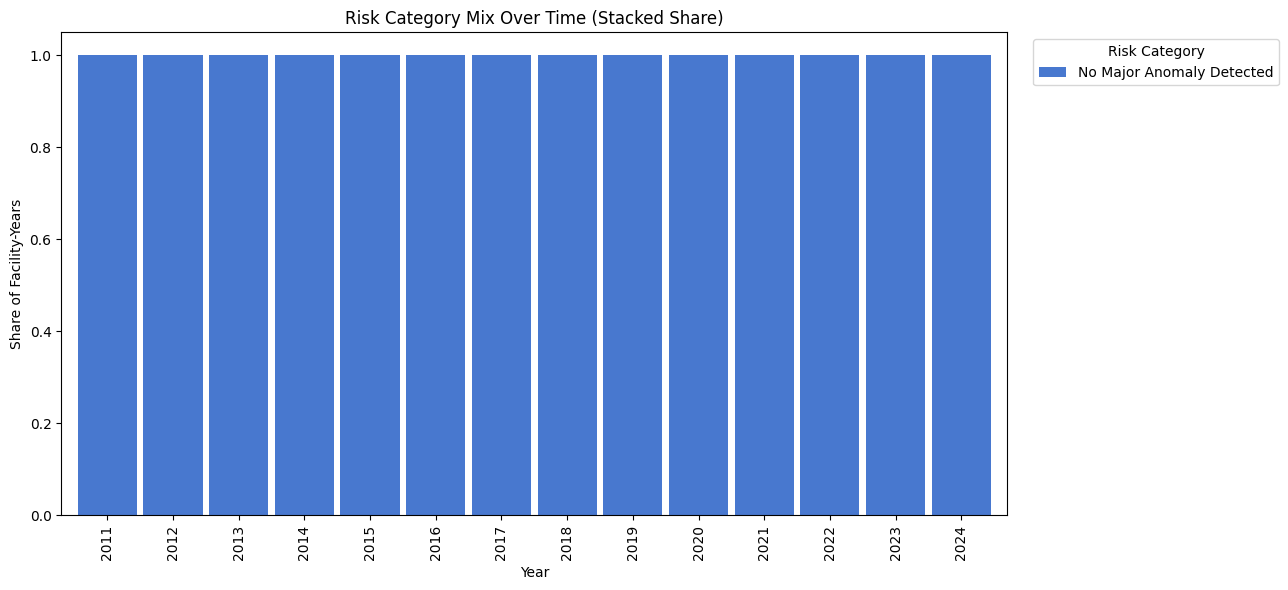

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure ordering from low to high
order = [
    "No Major Anomaly Detected",
    "Structural Accounting Irregularity",
    "Behavioral Gaming Signature",
    "Statistical Shock Event",
    "Structural + Behavioral Irregularities",
    "Structural Irregularity with Statistical Shock",
    "Behavioral Gaming with Statistical Shock",
    "CRITICAL: Structural, Behavioral, and Shock Anomalies"
]

# 1) Stacked % by year
tmp = (
    df.groupby(["source_year", "risk_category"])
      .size()
      .reset_index(name="n")
)

tmp["risk_category"] = pd.Categorical(tmp["risk_category"], categories=order, ordered=True)

year_totals = tmp.groupby("source_year")["n"].transform("sum")
tmp["pct"] = tmp["n"] / year_totals

pivot = tmp.pivot(index="source_year", columns="risk_category", values="pct").fillna(0).sort_index()

plt.figure(figsize=(13, 6))
pivot.plot(kind="bar", stacked=True, ax=plt.gca(), width=0.9)
plt.ylabel("Share of Facility-Years")
plt.xlabel("Year")
plt.title("Risk Category Mix Over Time (Stacked Share)")
plt.legend(title="Risk Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 13b.  Score Distributions by Category (Violin)

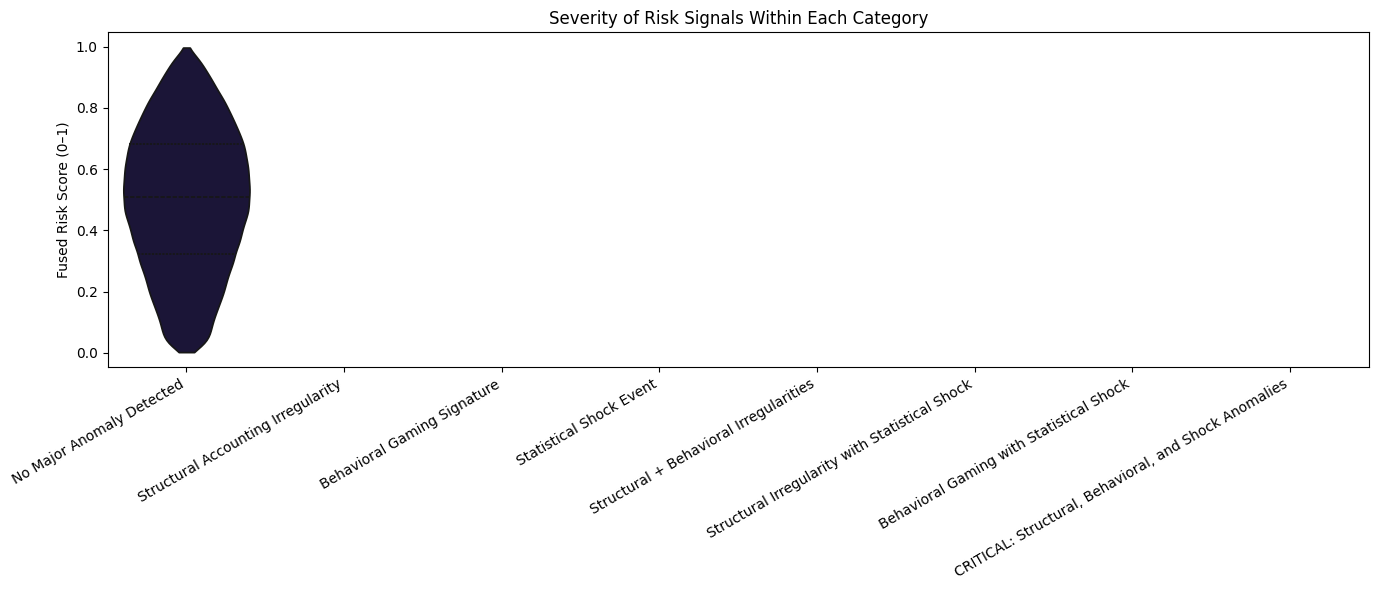

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Order categories from lowest to highest concern
order = [
    "No Major Anomaly Detected",
    "Structural Accounting Irregularity",
    "Behavioral Gaming Signature",
    "Statistical Shock Event",
    "Structural + Behavioral Irregularities",
    "Structural Irregularity with Statistical Shock",
    "Behavioral Gaming with Statistical Shock",
    "CRITICAL: Structural, Behavioral, and Shock Anomalies"
]

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="risk_category",
    y="risk_fused",
    order=order,
    palette="magma",
    inner="quartile",
    cut=0
)

plt.title("Severity of Risk Signals Within Each Category")
plt.xlabel("")
plt.ylabel("Fused Risk Score (0–1)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 13d. Diagnostics

DIAGNOSTIC: goodz_weighted_sum × distress anchor

Decile columns found: 10
Missing col present : True

── Mean distress anchor by goodz decile ──────────────────────────
  Decile             N   Mean distress    Median       SD
  ------------------------------------------------------
  missing        4,704          0.4951    0.5000   0.1094
  d01            8,512          0.4839    0.4889   0.2347
  d02            7,530          0.4512    0.4554   0.2201
  d03            8,135          0.4226    0.4188   0.2244
  d04            7,019          0.4482    0.4465   0.2320
  d05            7,216          0.4521    0.4518   0.2399
  d06            7,162          0.3094    0.3432   0.2055
  d07            7,635          0.2389    0.2429   0.1870
  d08            7,920          0.2182    0.2004   0.1843
  d09            8,306          0.2096    0.1880   0.1865
  d10            9,373          0.1882    0.1678   0.1809

── Low vs High goodz distress comparison ─────────────────────────
  Low goo

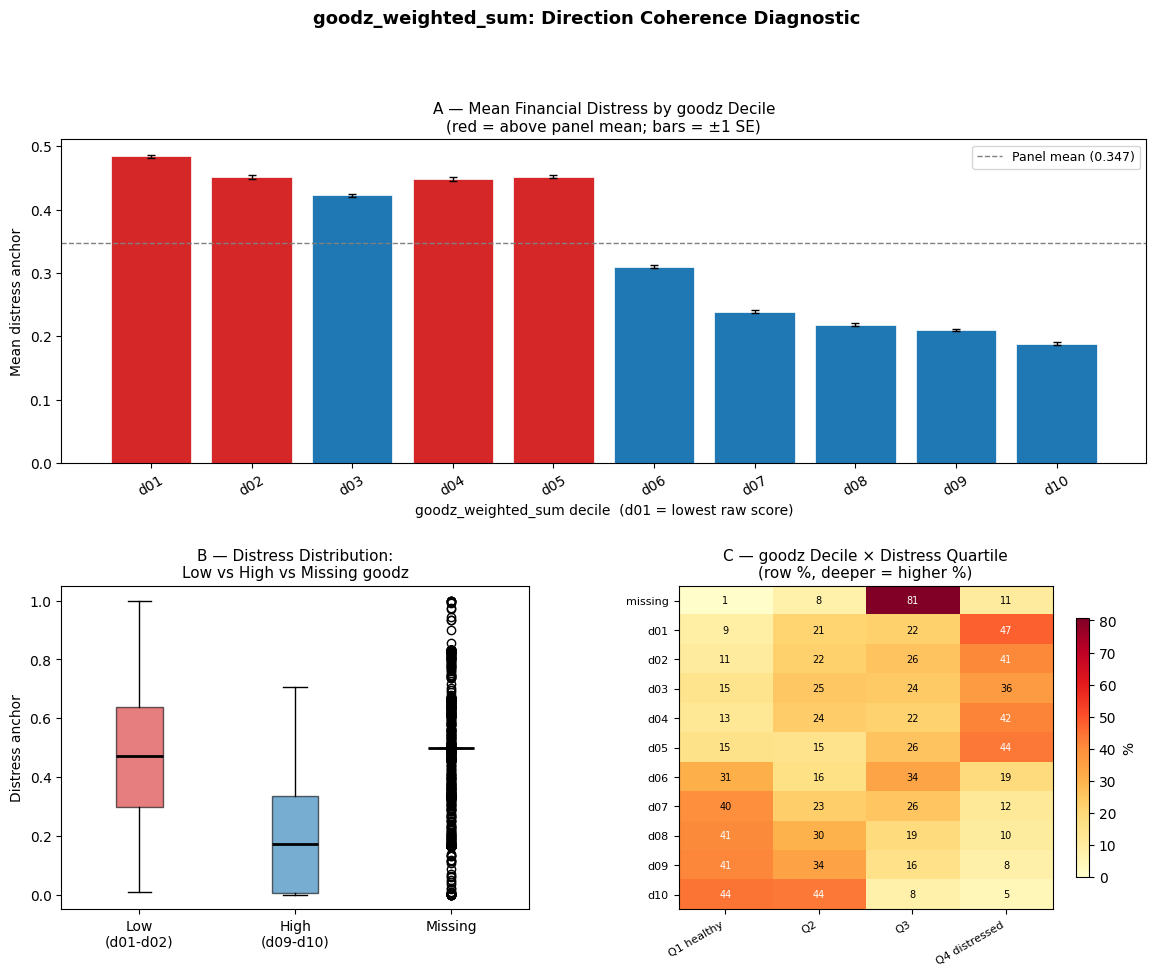


Figure saved: goodz_direction_diagnostic.png


In [20]:
# ============================================================
# DIAGNOSTIC — goodz_weighted_sum decile × distress anchor
# ============================================================
# Tests whether the optimizer's heavy loading on d01-d06 reflects
# a genuine distress signal at the low end of the goodz distribution,
# or a direction ambiguity that needs correction.
#
# Two populations of interest:
#   LOW goodz  (d01-d02): collapsing/erratic quality trajectories
#   HIGH goodz (d09-d10): suspiciously uniform improvement (gaming)
#
# If low goodz is genuinely more distressed than high goodz, the
# optimizer result is correct and interpretable.  If not, the
# higher_worse direction flag needs revisiting.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── 0. Rebuild distress anchor if not present ──────────────────────────────
if "_distress_anchor" not in df.columns:
    df["_distress_anchor"] = build_distress_anchor(df)

d_anchor = df["_distress_anchor"]

# ── 1. Identify goodz decile columns present in df ────────────────────────
import re
goodz_decile_cols = sorted(
    [c for c in df.columns if re.match(r'^goodz_weighted_sum_d\d{2}$', c)],
    key=lambda x: int(re.search(r'd(\d{2})', x).group(1))
)
goodz_missing_col = "goodz_weighted_sum_missing"

print("=" * 65)
print("DIAGNOSTIC: goodz_weighted_sum × distress anchor")
print("=" * 65)
print(f"\nDecile columns found: {len(goodz_decile_cols)}")
print(f"Missing col present : {goodz_missing_col in df.columns}")

# ── 2. Assign each row to its goodz decile (or missing) ───────────────────
def assign_goodz_decile(row):
    for col in goodz_decile_cols:
        if row[col] == 1:
            return int(re.search(r'd(\d{2})', col).group(1))
    if goodz_missing_col in row and row[goodz_missing_col] == 1:
        return 0   # 0 = missing
    return np.nan

df["_goodz_decile"] = df[goodz_decile_cols +
    ([goodz_missing_col] if goodz_missing_col in df.columns else [])
].apply(assign_goodz_decile, axis=1)

# ── 3. Distress anchor quartile ───────────────────────────────────────────
df["_distress_q"] = pd.qcut(
    d_anchor, q=4,
    labels=["Q1 healthy", "Q2", "Q3", "Q4 distressed"]
)

# ── 4. Mean distress anchor by goodz decile ───────────────────────────────
decile_labels = {0: "missing"} | {i: f"d{i:02d}" for i in range(1, 11)}

summary = (
    df.groupby("_goodz_decile")["_distress_anchor"]
    .agg(["mean", "median", "std", "count"])
    .rename(columns={"mean": "distress_mean", "median": "distress_median",
                     "std": "distress_std", "count": "n"})
    .reset_index()
)
summary["decile_label"] = summary["_goodz_decile"].map(decile_labels)
summary = summary.sort_values("_goodz_decile")

print("\n── Mean distress anchor by goodz decile ──────────────────────────")
print(f"  {'Decile':<12} {'N':>7}  {'Mean distress':>14}  "
      f"{'Median':>8}  {'SD':>7}")
print("  " + "-" * 54)
for _, row in summary.iterrows():
    print(f"  {row['decile_label']:<12} {int(row['n']):>7,}  "
          f"{row['distress_mean']:>14.4f}  "
          f"{row['distress_median']:>8.4f}  "
          f"{row['distress_std']:>7.4f}")

# ── 5. Key comparison: low vs high goodz ──────────────────────────────────
low_mask  = df["_goodz_decile"].isin([1, 2])
high_mask = df["_goodz_decile"].isin([9, 10])
miss_mask = df["_goodz_decile"] == 0

low_d  = d_anchor[low_mask].dropna()
high_d = d_anchor[high_mask].dropna()
miss_d = d_anchor[miss_mask].dropna() if miss_mask.any() else pd.Series(dtype=float)

print("\n── Low vs High goodz distress comparison ─────────────────────────")
print(f"  Low goodz  (d01-d02):  n={len(low_d):,}  "
      f"mean distress={low_d.mean():.4f}  median={low_d.median():.4f}")
print(f"  High goodz (d09-d10):  n={len(high_d):,}  "
      f"mean distress={high_d.mean():.4f}  median={high_d.median():.4f}")
if len(miss_d):
    print(f"  Missing goodz:         n={len(miss_d):,}  "
          f"mean distress={miss_d.mean():.4f}  median={miss_d.median():.4f}")

# Mann-Whitney U (more robust than t-test for distress anchor distribution)
if len(low_d) >= 10 and len(high_d) >= 10:
    u_stat, p_mw = stats.mannwhitneyu(low_d, high_d, alternative="two-sided")
    t_stat, p_t  = stats.ttest_ind(low_d, high_d)
    direction    = "LOW > HIGH" if low_d.mean() > high_d.mean() else "HIGH > LOW"
    print(f"\n  Mann-Whitney U={u_stat:.0f}  p={p_mw:.4e}  ({direction})")
    print(f"  Welch t={t_stat:.3f}            p={p_t:.4e}")
    print(f"\n  INTERPRETATION: ", end="")
    if p_mw < 0.05 and low_d.mean() > high_d.mean():
        print("Low goodz hospitals are significantly MORE distressed.")
        print("  → Optimizer loading on d01-d06 is CORRECT.")
        print("  → higher_worse=True direction flag is CORRECT.")
        print("  → Low goodz reflects collapsing quality trajectories,")
        print("    not absence of gaming — a genuine distress signal.")
    elif p_mw < 0.05 and high_d.mean() > low_d.mean():
        print("High goodz hospitals are significantly MORE distressed.")
        print("  → Direction ambiguity confirmed.")
        print("  → Consider higher_worse=False or signal reclassification.")
    else:
        print("No significant difference between low and high goodz distress.")
        print("  → Signal may lack directional coherence with distress anchor.")

# ── 6. Crosstab: goodz decile × distress quartile ─────────────────────────
print("\n── Crosstab: goodz decile × distress quartile (row %) ────────────")
cross = pd.crosstab(
    df["_goodz_decile"].map(decile_labels),
    df["_distress_q"],
    normalize="index"
).round(3) * 100

# Reorder rows by decile
row_order = ["missing"] + [f"d{i:02d}" for i in range(1, 11)]
cross = cross.reindex([r for r in row_order if r in cross.index])
print(cross.to_string())

# ── 7. Spearman correlation: goodz decile vs distress anchor ──────────────
valid_decile = df[df["_goodz_decile"] > 0]["_goodz_decile"]   # exclude missing
valid_anchor = d_anchor[valid_decile.index].dropna()
valid_decile = valid_decile[valid_anchor.index]

if len(valid_decile) > 50:
    rho, p_rho = stats.spearmanr(valid_decile, valid_anchor)
    print(f"\n── Spearman(goodz_decile, distress_anchor) ───────────────────────")
    print(f"  rho = {rho:.4f}   p = {p_rho:.4e}")
    print(f"  Negative rho → low decile = high distress (optimizer is correct)")
    print(f"  Positive rho → high decile = high distress (direction flag issue)")

# ── 8. Figure ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel A: mean distress by decile (bar)
ax_a = fig.add_subplot(gs[0, :])
plot_df = summary[summary["_goodz_decile"] > 0].copy()
colors  = ["#d62728" if v > summary["distress_mean"].median() else "#1f77b4"
           for v in plot_df["distress_mean"]]
bars = ax_a.bar(plot_df["decile_label"], plot_df["distress_mean"],
                color=colors, edgecolor="white", linewidth=0.5)
ax_a.errorbar(plot_df["decile_label"],
              plot_df["distress_mean"],
              yerr=plot_df["distress_std"] / np.sqrt(plot_df["n"]),
              fmt="none", color="black", capsize=3, linewidth=1)
ax_a.axhline(d_anchor.mean(), color="gray", linestyle="--",
             linewidth=1, label=f"Panel mean ({d_anchor.mean():.3f})")
ax_a.set_xlabel("goodz_weighted_sum decile  (d01 = lowest raw score)")
ax_a.set_ylabel("Mean distress anchor")
ax_a.set_title("A — Mean Financial Distress by goodz Decile\n"
               "(red = above panel mean; bars = ±1 SE)",
               fontsize=11)
ax_a.legend(fontsize=9)
ax_a.tick_params(axis="x", rotation=30)

# Panel B: box plot low vs high vs missing
ax_b = fig.add_subplot(gs[1, 0])
groups, labels = [], []
for mask, lbl in [(low_mask, "Low\n(d01-d02)"),
                  (high_mask, "High\n(d09-d10)"),
                  (miss_mask, "Missing")]:
    vals = d_anchor[mask].dropna().values
    if len(vals):
        groups.append(vals)
        labels.append(lbl)

bp = ax_b.boxplot(groups, labels=labels, patch_artist=True,
                  medianprops={"color": "black", "linewidth": 2})
palette = ["#d62728", "#1f77b4", "#7f7f7f"]
for patch, color in zip(bp["boxes"], palette[:len(groups)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax_b.set_ylabel("Distress anchor")
ax_b.set_title("B — Distress Distribution:\nLow vs High vs Missing goodz",
               fontsize=11)

# Panel C: heatmap of row-normalised crosstab
ax_c = fig.add_subplot(gs[1, 1])
import matplotlib.colors as mcolors
cmap = plt.cm.YlOrRd
im   = ax_c.imshow(cross.values, aspect="auto", cmap=cmap,
                   vmin=0, vmax=cross.values.max())
ax_c.set_xticks(range(len(cross.columns)))
ax_c.set_xticklabels(cross.columns, rotation=30, ha="right", fontsize=8)
ax_c.set_yticks(range(len(cross.index)))
ax_c.set_yticklabels(cross.index, fontsize=8)
ax_c.set_title("C — goodz Decile × Distress Quartile\n(row %, deeper = higher %)",
               fontsize=11)
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        ax_c.text(j, i, f"{cross.values[i, j]:.0f}",
                  ha="center", va="center", fontsize=7,
                  color="white" if cross.values[i, j] > 40 else "black")
plt.colorbar(im, ax=ax_c, shrink=0.8, label="%")

fig.suptitle("goodz_weighted_sum: Direction Coherence Diagnostic",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("goodz_direction_diagnostic.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("\nFigure saved: goodz_direction_diagnostic.png")

# ── 9. Cleanup ────────────────────────────────────────────────────────────
df.drop(columns=["_goodz_decile", "_distress_q", "_distress_anchor"],
        inplace=True, errors="ignore")

## 13e.  Diagnostics 2

Anchor rebuilt: 83,512 obs
count    83512.000000
mean         0.346835
std          0.237047
min          0.000002
25%          0.148783
50%          0.339285
75%          0.500012
max          1.000000
Name: _distress_anchor, dtype: float64
1. GLOBAL WEIGHT BY DIMENSION

  Dimension       N signals     Total w   % of total     Mean w      Max w
  --------------------------------------------------------------------
  behavioral             26      0.5171        51.7%     0.0199     0.0644
  temporal               66      0.3360        33.6%     0.0051     0.0146
  statistical            12      0.1394        13.9%     0.0116     0.0212
  structural              1      0.0076         0.8%     0.0076     0.0076

  TOTAL                 105      1.0000       100.0%

  Top signals per dimension:

  STRUCTURAL
    vae_gaming_score                              0.0076  ███

  STATISTICAL
    benford_anomaly_score_d07                     0.0212  ████████
    benford_anomaly_score_d05          

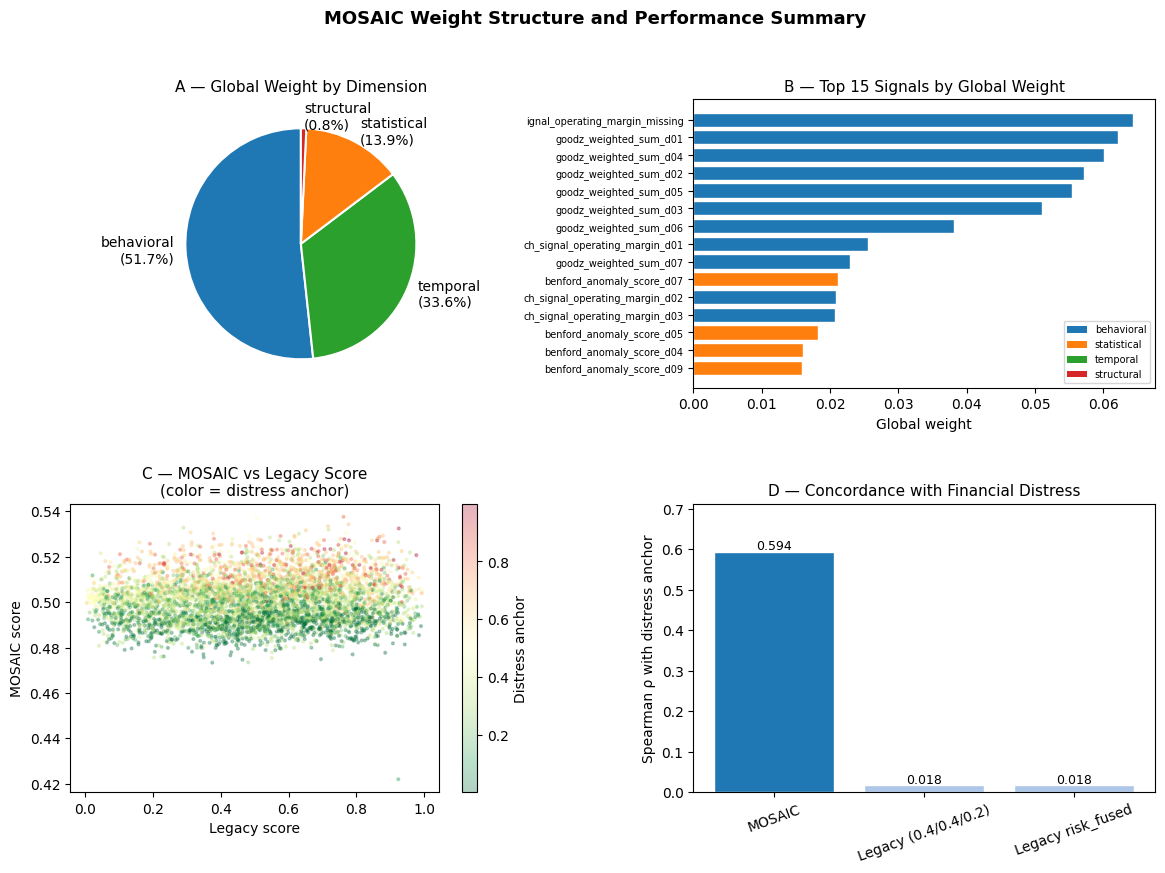


Figure saved: mosaic_weight_performance_summary.png


In [21]:
# ============================================================
# DIAGNOSTIC — Weight Summary, VAE Check, MOSAIC vs Legacy
# ============================================================
# Answers three pre-results questions:
#   1. Total weight by dimension (structural / statistical /
#      behavioral / temporal) as % of global weight
#   2. VAE near-zero check — did the optimizer silence it?
#   3. Spearman(MOSAIC, distress) vs Spearman(legacy, distress)
#      and global objective value
# Run after Cell 40 (weight report).  Requires w_global,
# mosaic_weights, available_signals, df in scope.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

import re

# Check all cells for _distress_anchor drops
# Since we can't scan the notebook programmatically here, 
# just rebuild it directly from Cell 6b's function

# Temporary: reconstruct the anchor so you can keep running
def _build_distress_anchor_local(df):
    components = []
    cr = pd.to_numeric(df.get("current_ratio", pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(5.0 * (cr - 1.0)))).fillna(0.5))
    om = pd.to_numeric(df.get("operating_margin", pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(30.0 * om))).fillna(0.5))
    dcoh = pd.to_numeric(df.get("days_cash_on_hand", pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(0.5 * (dcoh - 15.0)))).fillna(0.5))
    return pd.concat(components, axis=1).mean(axis=1)

df["_distress_anchor"] = _build_distress_anchor_local(df)
print(f"Anchor rebuilt: {df['_distress_anchor'].notna().sum():,} obs")
print(df["_distress_anchor"].describe())
# ── 0. Resolve available_signals and dimension map ────────────────────────
# available_signals may be the list from Cell 40 or rebuilt here
if "available_signals" not in dir():
    available_signals = [
        sig for sig in SIGNAL_CATALOG
        if sig in df.columns and df[sig].notna().sum() > 50
    ]

def _get_dim(sig):
    """Resolve dimension for base signal or encoded column."""
    if sig in SIGNAL_CATALOG:
        return SIGNAL_CATALOG[sig].get("dim", "unknown")
    # encoded column — strip _dXX or _missing suffix
    base = re.sub(r'_(d\d{2}|missing)$', '', sig)
    meta = SIGNAL_CATALOG.get(base, {})
    if meta:
        return meta.get("dim", "unknown")
    # fallback: check encoded_from if present
    meta2 = SIGNAL_CATALOG.get(sig, {})
    return meta2.get("dim", meta2.get("encoded_from", "unknown"))

dims = [_get_dim(s) for s in available_signals]

# ── 1. DIMENSION WEIGHT SUMMARY ───────────────────────────────────────────
print("=" * 65)
print("1. GLOBAL WEIGHT BY DIMENSION")
print("=" * 65)

dim_df = pd.DataFrame({
    "signal":    available_signals,
    "dimension": dims,
    "w_global":  w_global,
})

dim_summary = (
    dim_df.groupby("dimension")["w_global"]
    .agg(total="sum", n_signals="count", mean="mean", max="max")
    .reset_index()
    .sort_values("total", ascending=False)
)
dim_summary["pct_of_total"] = dim_summary["total"] / dim_summary["total"].sum() * 100

print(f"\n  {'Dimension':<14} {'N signals':>10}  {'Total w':>10}  "
      f"{'% of total':>11}  {'Mean w':>9}  {'Max w':>9}")
print("  " + "-" * 68)
for _, row in dim_summary.iterrows():
    print(f"  {row['dimension']:<14} {int(row['n_signals']):>10}  "
          f"{row['total']:>10.4f}  {row['pct_of_total']:>10.1f}%  "
          f"{row['mean']:>9.4f}  {row['max']:>9.4f}")
print(f"\n  {'TOTAL':<14} {int(dim_summary['n_signals'].sum()):>10}  "
      f"{dim_summary['total'].sum():>10.4f}  {'100.0':>10}%")

# Top 5 signals per dimension
print("\n  Top signals per dimension:")
for dim in ["structural", "statistical", "behavioral", "temporal"]:
    sub = dim_df[dim_df["dimension"] == dim].nlargest(5, "w_global")
    if sub.empty:
        print(f"\n  {dim.upper()}: no signals found")
        continue
    print(f"\n  {dim.upper()}")
    for _, r in sub.iterrows():
        bar = "█" * int(r["w_global"] * 400)
        print(f"    {r['signal']:<44}  {r['w_global']:.4f}  {bar}")

# ── 2. VAE NEAR-ZERO CHECK ────────────────────────────────────────────────
print("\n" + "=" * 65)
print("2. VAE / STRUCTURAL CHANNEL — NEAR-ZERO CHECK")
print("=" * 65)

NEAR_ZERO_THRESH = 0.005

vae_signals = dim_df[dim_df["dimension"] == "structural"].copy()
vae_signals = vae_signals.sort_values("w_global", ascending=False)

print(f"\n  Structural signals (threshold for 'near-zero' = {NEAR_ZERO_THRESH}):")
for _, r in vae_signals.iterrows():
    flag = " ← NEAR ZERO" if r["w_global"] < NEAR_ZERO_THRESH else ""
    print(f"    {r['signal']:<44}  w={r['w_global']:.5f}{flag}")

vae_total = vae_signals["w_global"].sum()
print(f"\n  Total structural weight : {vae_total:.4f}  "
      f"({vae_total*100:.1f}% of global)")

if vae_total < 0.02:
    print("\n  *** FINDING: VAE/structural channel effectively silenced by optimizer.")
    print("      Legacy benchmark assigned 40% to vae_pct.")
    print("      MOSAIC assigns {:.1f}% — a {:.0f}pp reduction.".format(
        vae_total*100, (0.40 - vae_total)*100))
    print("      Implication: structural gaming signal adds little beyond")
    print("      behavioral and statistical signals in this panel.")
elif vae_total < 0.10:
    print(f"\n  NOTE: Structural channel substantially down-weighted vs legacy.")
    print(f"        Legacy: 40.0%  →  MOSAIC: {vae_total*100:.1f}%")
else:
    print(f"\n  Structural channel retained meaningful weight: {vae_total*100:.1f}%")

# ── 3. MOSAIC vs LEGACY PERFORMANCE ──────────────────────────────────────
print("\n" + "=" * 65)
print("3. MOSAIC vs LEGACY — SPEARMAN WITH DISTRESS ANCHOR")
print("=" * 65)

# Rebuild distress anchor if needed
assert "_distress_anchor" in df.columns, \
    "_distress_anchor missing — run Cell 6b before this diagnostic."

d = df["_distress_anchor"].fillna(0.5)

results = {}
for score_col, label in [
    ("mosaic_score",      "MOSAIC"),
    ("risk_fused_legacy", "Legacy (0.4/0.4/0.2)"),
    ("risk_fused",        "Legacy risk_fused"),
]:
    if score_col not in df.columns:
        continue
    valid = df[score_col].notna() & d.notna()
    if valid.sum() < 100:
        continue
    rho, p = stats.spearmanr(df.loc[valid, score_col], d[valid])
    results[label] = {"rho": rho, "p": p, "n": valid.sum()}

print(f"\n  {'Model':<26}  {'N':>7}  {'Spearman rho':>13}  {'p-value':>12}")
print("  " + "-" * 62)
for label, res in results.items():
    sig_flag = "***" if res["p"] < 0.001 else ("**" if res["p"] < 0.01 else "*")
    print(f"  {label:<26}  {res['n']:>7,}  {res['rho']:>13.4f}  "
          f"{res['p']:>12.4e}  {sig_flag}")

if "MOSAIC" in results and "Legacy (0.4/0.4/0.2)" in results:
    delta = results["MOSAIC"]["rho"] - results["Legacy (0.4/0.4/0.2)"]["rho"]
    pct   = delta / abs(results["Legacy (0.4/0.4/0.2)"]["rho"]) * 100
    print(f"\n  MOSAIC improvement over legacy:  Δrho = {delta:+.4f}  "
          f"({pct:+.1f}%)")
    if delta > 0:
        print("  → MOSAIC better aligned with financial distress than legacy.")
    else:
        print("  → Legacy marginally better — worth investigating.")

# Global objective value
print(f"\n  Global objective value (from run_mosaic): ", end="")
try:
    # obj_global may be in scope from run_mosaic verbose output
    print(f"{obj_global:.6f}")
except NameError:
    print("obj_global not in scope — check run_mosaic verbose output.")

# ── 4. FIGURE — Dimension weights + MOSAIC vs legacy ─────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# Panel A: dimension weight pie
ax_a = fig.add_subplot(gs[0, 0])
dim_colors = {
    "behavioral": "#1f77b4",
    "statistical": "#ff7f0e",
    "temporal": "#2ca02c",
    "structural": "#d62728",
    "unknown": "#7f7f7f",
}
pie_data   = dim_summary.set_index("dimension")["total"]
pie_colors = [dim_colors.get(d, "#7f7f7f") for d in pie_data.index]
wedges, texts, autotexts = ax_a.pie(
    pie_data.values,
    labels=[f"{d}\n({v*100:.1f}%)" for d, v in zip(pie_data.index, pie_data.values)],
    colors=pie_colors,
    autopct="",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax_a.set_title("A — Global Weight by Dimension", fontsize=11)

# Panel B: top-15 signals bar chart
ax_b = fig.add_subplot(gs[0, 1])
top15 = dim_df.nlargest(15, "w_global")
bar_colors = [dim_colors.get(_get_dim(s), "#7f7f7f") for s in top15["signal"]]
ax_b.barh(range(len(top15)), top15["w_global"].values,
          color=bar_colors, edgecolor="white")
ax_b.set_yticks(range(len(top15)))
ax_b.set_yticklabels(
    [s[-30:] if len(s) > 30 else s for s in top15["signal"].values],
    fontsize=7
)
ax_b.invert_yaxis()
ax_b.set_xlabel("Global weight")
ax_b.set_title("B — Top 15 Signals by Global Weight", fontsize=11)
# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=d)
              for d, c in dim_colors.items() if d != "unknown"]
ax_b.legend(handles=legend_els, fontsize=7, loc="lower right")

# Panel C: MOSAIC vs legacy scatter
ax_c = fig.add_subplot(gs[1, 0])
if "mosaic_score" in df.columns and "risk_fused_legacy" in df.columns:
    sample = df[["mosaic_score", "risk_fused_legacy", "_distress_anchor"]].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    sc = ax_c.scatter(
        sample["risk_fused_legacy"], sample["mosaic_score"],
        c=sample["_distress_anchor"], cmap="RdYlGn_r",
        alpha=0.3, s=4, rasterized=True
    )
    plt.colorbar(sc, ax=ax_c, label="Distress anchor")
    ax_c.set_xlabel("Legacy score")
    ax_c.set_ylabel("MOSAIC score")
    ax_c.set_title("C — MOSAIC vs Legacy Score\n(color = distress anchor)",
                   fontsize=11)

# Panel D: Spearman comparison bar
ax_d = fig.add_subplot(gs[1, 1])
if results:
    labels_bar = list(results.keys())
    rhos_bar   = [results[l]["rho"] for l in labels_bar]
    bar_c      = ["#1f77b4" if "MOSAIC" in l else "#aec7e8" for l in labels_bar]
    ax_d.bar(labels_bar, rhos_bar, color=bar_c, edgecolor="white")
    ax_d.set_ylabel("Spearman ρ with distress anchor")
    ax_d.set_title("D — Concordance with Financial Distress", fontsize=11)
    ax_d.tick_params(axis="x", rotation=20)
    ax_d.set_ylim(0, min(1.0, max(rhos_bar) * 1.2))
    for i, (lbl, rho) in enumerate(zip(labels_bar, rhos_bar)):
        ax_d.text(i, rho + 0.005, f"{rho:.3f}", ha="center", fontsize=9)

fig.suptitle("MOSAIC Weight Structure and Performance Summary",
             fontsize=13, fontweight="bold")
plt.savefig("mosaic_weight_performance_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved: mosaic_weight_performance_summary.png")


## 13f.  Comparison across Model Types

In [34]:
# =============================================================================
# FOUR-WAY COMPARATOR — Results Section Table
# MOSAIC vs Standalone IF vs Standalone VAE vs Fixed-Weight Legacy
# =============================================================================
# CHANGE FROM THREE-WAY: adds Standalone VAE (vae_gaming_score / vae_pct)
# as a fourth comparator. The VAE is an architectural component of MOSAIC
# but also a legitimate standalone anomaly detector. Including it directly
# answers how much of MOSAIC's performance is attributable to structural
# reconstruction alone vs. the full GP-optimized behavioral + temporal fusion.
#
# REQUIRED COLUMNS (all must be in df before running):
#   mosaic_score       — MOSAIC GP-optimized composite     (Cell 37 / MOSAIC cell)
#   if_pct_decile      — Standalone Isolation Forest score (Cell 22 / 6b)
#   vae_gaming_score   — Standalone VAE BCE anomaly score  (Cell 31)
#   risk_fused_legacy  — Fixed-weight 0.4/0.4/0.2 ensemble (Cell 33)
#   _distress_anchor   — Financial distress proxy          (Cell 6b / 48)
#   peer_group         — Peer cohort label                 (Cell 6b)
#   source_year        — Fiscal year                       (Cell 6b)
#   data_regime        — Regime label                      (Cell 5)
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── 0. Verify required columns ────────────────────────────────────────────────
required = [
    "_distress_anchor", "mosaic_score", "if_pct_decile",
    "vae_gaming_score", "risk_fused_legacy",
    "peer_group", "source_year", "data_regime"
]
missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

anchor     = df["_distress_anchor"]
anchor_col = "_distress_anchor"

# ── 1. Score map: four models, display order low → high sophistication ────────
score_map = {
    "Fixed-weight (0.4/0.4/0.2)": df["risk_fused_legacy"],
    "Standalone VAE":              df["vae_gaming_score"],
    "Standalone IF":               df["if_pct_decile"],
    "MOSAIC (GP-optimized)":       df["mosaic_score"],
}

# ── 2. Three-stat helper ──────────────────────────────────────────────────────
def _three_stats(score, anchor, peer, year):
    """
    Returns rho_global, rho_peeryear (within peer×year), separation, and N.
    Separation = E[percentile rank | top-quartile distress]
               - E[percentile rank | bottom-quartile distress]
    Uses percentile rank of score (not raw score) for separation so that
    all four models are on the same [0,1] scale despite different score ranges.
    """
    mask = score.notna() & anchor.notna()
    s, a = score[mask], anchor[mask]

    # Global Spearman
    rho_g, p_g = spearmanr(s, a)

    # Within-peer-year Spearman (controls peer cohort × time fixed effects)
    py_group    = peer[mask].astype(str) + "__" + year[mask].astype(str)
    rho_py, p_py = spearmanr(
        s.groupby(py_group).rank(pct=True),
        a.groupby(py_group).rank(pct=True)
    )

    # Separation on percentile ranks
    s_pct = s.rank(pct=True)
    q75, q25 = a.quantile(0.75), a.quantile(0.25)
    sep = s_pct[a >= q75].mean() - s_pct[a <= q25].mean()

    return dict(
        rho_global=rho_g, p_global=p_g,
        rho_peeryear=rho_py, p_peeryear=p_py,
        separation=sep, n=mask.sum()
    )

# ── 3. Compute stats for all four models ─────────────────────────────────────
rows = []
for label, score in score_map.items():
    rows.append({
        "Model": label,
        **_three_stats(score, anchor, df["peer_group"], df["source_year"])
    })
results = pd.DataFrame(rows)

# ── 4. Display main comparison table ─────────────────────────────────────────
def _fmt(rho, p):
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "  "))
    return f"{rho:+.4f}{stars}"

print("\n" + "=" * 78)
print("FOUR-WAY COMPARATOR — MOSAIC vs Baselines")
print("=" * 78)
print(f"  {'Model':<36}  {'rho_global':>12}  {'rho_peeryear':>14}  {'separation':>12}  {'N':>8}")
print(f"  {'-'*36}  {'-'*12}  {'-'*14}  {'-'*12}  {'-'*8}")
for _, row in results.iterrows():
    print(
        f"  {row['Model']:<36}  "
        f"{_fmt(row['rho_global'],  row['p_global']):>12}  "
        f"{_fmt(row['rho_peeryear'], row['p_peeryear']):>14}  "
        f"{row['separation']:>+12.4f}  "
        f"{row['n']:>8,}"
    )

print(f"\n  *** p<0.001  ** p<0.01  * p<0.05")
print(f"  rho_peeryear controls for peer_group × source_year fixed effects.")
print(f"  Separation = E[pct-rank | Q4 distress] − E[pct-rank | Q1 distress].")
print(f"  Score percentile ranks used for separation (normalizes scale differences).")

# ── 5. Lift rows ──────────────────────────────────────────────────────────────
mosaic_row  = results[results["Model"] == "MOSAIC (GP-optimized)"].iloc[0]
if_row      = results[results["Model"] == "Standalone IF"].iloc[0]
vae_row     = results[results["Model"] == "Standalone VAE"].iloc[0]
fw_row      = results[results["Model"] == "Fixed-weight (0.4/0.4/0.2)"].iloc[0]

print(f"\n  MOSAIC lift vs Standalone IF  : Δrho_global = "
      f"{mosaic_row['rho_global'] - if_row['rho_global']:+.4f}  "
      f"Δrho_peer×yr = {mosaic_row['rho_peeryear'] - if_row['rho_peeryear']:+.4f}")
print(f"  MOSAIC lift vs Standalone VAE : Δrho_global = "
      f"{mosaic_row['rho_global'] - vae_row['rho_global']:+.4f}  "
      f"Δrho_peer×yr = {mosaic_row['rho_peeryear'] - vae_row['rho_peeryear']:+.4f}")
print(f"  MOSAIC lift vs Fixed-weight   : Δrho_global = "
      f"{mosaic_row['rho_global'] - fw_row['rho_global']:+.4f}  "
      f"Δrho_peer×yr = {mosaic_row['rho_peeryear'] - fw_row['rho_peeryear']:+.4f}")
print(f"  IF vs VAE (structural parity) : Δrho_global = "
      f"{if_row['rho_global'] - vae_row['rho_global']:+.4f}  "
      f"(confirms neither single-model baseline dominates)")

COMPARATOR_TABLE = results.copy()

# ── 6. Regime-stratified breakdown (MOSAIC + IF + VAE vs Fixed-weight) ────────
if "data_regime" in df.columns:
    print("\n" + "=" * 78)
    print("REGIME-STRATIFIED rho_global")
    print("=" * 78)
    print(f"  {'Regime':<14}  {'Fixed-wt':>10}  {'VAE':>10}  {'IF':>10}  "
          f"{'MOSAIC':>10}  {'MOSAIC−IF':>10}  {'N':>7}")
    print(f"  {'-'*14}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*7}")
    for regime in ["baseline", "transition", "covid_shock", "recovery"]:
        if regime not in df["data_regime"].values:
            continue
        m = (
            (df["data_regime"] == regime)
            & df["mosaic_score"].notna()
            & anchor.notna()
        )
        if m.sum() < 30:
            continue
        rho_fw,  _ = spearmanr(score_map["Fixed-weight (0.4/0.4/0.2)"][m], anchor[m])
        rho_vae, _ = spearmanr(score_map["Standalone VAE"][m],              anchor[m])
        rho_if,  _ = spearmanr(score_map["Standalone IF"][m],               anchor[m])
        rho_mo,  _ = spearmanr(score_map["MOSAIC (GP-optimized)"][m],       anchor[m])
        print(
            f"  {regime:<14}  {rho_fw:>+10.4f}  {rho_vae:>+10.4f}  "
            f"{rho_if:>+10.4f}  {rho_mo:>+10.4f}  "
            f"{rho_mo - rho_if:>+10.4f}  {m.sum():>7,}"
        )

# ── 7. TikZ coordinates for fig:decile_gradient (four curves) ─────────────────
print("\n\nTikZ coordinates for fig:decile_gradient (four models)\n")

tikz_labels = {
    "MOSAIC":        "MOSAIC (GP-optimized)",
    "Standalone IF": "Standalone IF",
    "Standalone VAE":"Standalone VAE",
    "Fixed-weight":  "Fixed-weight (0.4/0.4/0.2)",
}
tikz_scores = {
    "MOSAIC":         df["mosaic_score"],
    "Standalone IF":  df["if_pct_decile"],
    "Standalone VAE": df["vae_gaming_score"],
    "Fixed-weight":   df["risk_fused_legacy"],
}

for short_label, score in tikz_scores.items():
    mask   = score.notna() & anchor.notna()
    s, a   = score[mask], anchor[mask]
    decile = pd.qcut(s, 10, labels=False) + 1   # 1–10
    means  = a.groupby(decile).mean()
    print(f"% {tikz_labels[short_label]}")
    print("coordinates {")
    for d, v in means.items():
        print(f"    ({d},{v:.3f})")
    print("};")
    print()


FOUR-WAY COMPARATOR — MOSAIC vs Baselines
  Model                                   rho_global    rho_peeryear    separation         N
  ------------------------------------  ------------  --------------  ------------  --------
  Fixed-weight (0.4/0.4/0.2)              +0.0184***      +0.0401***       +0.0507    83,512
  Standalone VAE                          +0.1173***      +0.1145***       +0.1156    83,512
  Standalone IF                           +0.1104***      +0.1592***       +0.1223    83,512
  MOSAIC (GP-optimized)                   +0.5939***      +0.6202***       +0.4287    83,512

  *** p<0.001  ** p<0.01  * p<0.05
  rho_peeryear controls for peer_group × source_year fixed effects.
  Separation = E[pct-rank | Q4 distress] − E[pct-rank | Q1 distress].
  Score percentile ranks used for separation (normalizes scale differences).

  MOSAIC lift vs Standalone IF  : Δrho_global = +0.4834  Δrho_peer×yr = +0.4610
  MOSAIC lift vs Standalone VAE : Δrho_global = +0.4766  Δrho_peer×

In [23]:
# How many NaN mosaic_scores, and what regimes do they belong to?
nan_mask = df["mosaic_score"].isna()
print(f"NaN mosaic_score: {nan_mask.sum():,}")
print("\nBy data_regime:")
print(df.loc[nan_mask, "data_regime"].value_counts(dropna=False))
print("\nBy peer_group (top 10):")
print(df.loc[nan_mask, "peer_group"].value_counts(dropna=False).head(10))

NaN mosaic_score: 0

By data_regime:
data_regime
transition     0
baseline       0
covid_shock    0
recovery       0
other          0
Name: count, dtype: int64

By peer_group (top 10):
Series([], Name: count, dtype: int64)


# 14.  Audit Prioritization — Top-10 Leads

In [24]:
# =============================================================================
# MOSAIC EXECUTION + THREE-WAY COMPARATOR + TOP-10 LEAD TABLES
# =============================================================================
# EXECUTION ORDER (fixed):
#   1. Confirms MOSAIC outputs already in scope (run MOSAIC cell first)
#   MOSAIC cell: must have run — mosaic_score, mosaic_category, mosaic_flag required
#   2. Legacy remap runs   → populates risk_category from mosaic_category
#   3. Top-10 tables       → filter on risk_category (now populated)
#   4. Three-way comparator → all score columns confirmed present
#   5. Threshold report
#   6. Risk category distribution
#
# VARIABLE NAME FIXES vs prior version:
#   mosaic_weights    → weight_matrix       (rewritten MOSAIC cell)
#   mosaic_threshold  → threshold_result    (rewritten MOSAIC cell)
#   if_pct_standalone → if_pct_decile       (Cell 6b authoritative column)
#   risk_fused        → risk_fused_legacy   (rewritten MOSAIC cell)
#
# REQUIRES (upstream cells must have run):
#   Cell 6b   : _distress_anchor, if_pct_decile, IF_BENCHMARK
#   Cell 10   : vae_pct, srri_pct, SRRI, vae_gaming_score
#   Cell 39   : data_regime
#   MOSAIC cell: mosaic_replace_cell34() in scope
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── Guards ────────────────────────────────────────────────────────────────────
assert "_distress_anchor" in df.columns,  "_distress_anchor missing — run Cell 6b first."
assert "if_pct_decile"    in df.columns,  "if_pct_decile missing — run Cell 6b first."
assert "vae_pct"          in df.columns,  "vae_pct missing — run Cell 10 first."
assert "srri_pct"         in df.columns,  "srri_pct missing — run Cell 10 first."
assert "data_regime"      in df.columns,  "data_regime missing — run Cell 39 first."
assert "peer_group"       in df.columns,  "peer_group missing — run Cell 7 first."
assert "anomaly_quadrant" in df.columns,  "anomaly_quadrant missing — run Cell 10 first."
assert "risk_category" in df.columns, "risk_category missing — run MOSAIC cell first."


# AFTER:
# =============================================================================
# STEP 1: CONFIRM MOSAIC OUTPUTS IN SCOPE
# =============================================================================
assert "mosaic_score"    in df.columns, "mosaic_score missing — run MOSAIC cell first."
assert "mosaic_category" in df.columns, "mosaic_category missing — run MOSAIC cell first."
assert "mosaic_flag"     in df.columns, "mosaic_flag missing — run MOSAIC cell first."
assert "risk_fused_legacy" in df.columns, "risk_fused_legacy missing — run MOSAIC cell first."
assert "weight_matrix"    in dir(),     "weight_matrix missing — run MOSAIC cell first."
assert "threshold_result" in dir(),     "threshold_result missing — run MOSAIC cell first."
assert "w_global"         in dir(),     "w_global missing — run MOSAIC cell first."


# =============================================================================
# STEP 2: REMAP TO LEGACY RISK TAXONOMY
# Maps MOSAIC categories → six-level narrative labels so downstream cells
# (heatmaps, odds ratios, lead tables) continue to work unchanged.
# =============================================================================

def _remap_to_legacy_category(row):
    mc = row.get("mosaic_category", "Normal")
    sc = row.get("anomaly_quadrant", "LOW")   # from Cell 10 VAE/SRRI quadrant

    if mc == "HIGH RISK — Confirmed":
        if sc == "CONSENSUS_HIGH":
            return "CRITICAL: Structural, Behavioral, and Shock Anomalies"
        elif sc == "VAE_ONLY_STRUCTURAL":
            return "Structural + Behavioral Irregularities"
        elif sc == "SRRI_ONLY_RULELIKE":
            return "Behavioral Gaming with Statistical Shock"
        else:
            return "Structural + Behavioral Irregularities"
    elif mc == "HIGH RISK — Uncertain":
        return "Structural Accounting Irregularity"
    elif mc == "ELEVATED RISK":
        return "Behavioral Gaming Signature"
    else:
        return "No Major Anomaly Detected"

df["risk_category"] = df.apply(_remap_to_legacy_category, axis=1)

print("\nrisk_category distribution after MOSAIC remap:")
print(df["risk_category"].value_counts().to_string())


# =============================================================================
# STEP 3: TOP-10 LEAD TABLES
# risk_category is now populated — safe to filter.
# =============================================================================

CRIT_LABEL = "CRITICAL: Structural, Behavioral, and Shock Anomalies"

NAME_CANDIDATES = [
    "provider_name", "PROVIDER_NAME", "fac_name", "facility_name", "hosp_name",
    "hospital_name", "prvdr_name", "name", "provider_nm"
]
name_col = next((c for c in NAME_CANDIDATES if c in df.columns), None)

base_cols = ["PRVDR_NUM", "source_year"]
if name_col:
    base_cols.insert(1, name_col)

score_cols = [
    "mosaic_score", "risk_fused_legacy",
    "vae_pct", "srri_pct", "if_pct_decile",
    "vae_gaming_score", "SRRI"
]
explain_cols = ["outlier_flags", "outlier_drivers_top", "mosaic_category", "anomaly_quadrant"]

def _keep_existing(cols):
    return [c for c in cols if c in df.columns]

show_cols = _keep_existing(base_cols + score_cols + explain_cols)

crit = df.loc[df["risk_category"] == CRIT_LABEL].copy()

if crit.empty:
    print(f"  WARNING: No rows with risk_category == '{CRIT_LABEL}'.")
    print(f"  Current risk_category counts:")
    print(df["risk_category"].value_counts().to_string())
else:
    def _style_forensics(t: pd.DataFrame, title: str):
        t2 = t.copy()
        pct_cols   = _keep_existing(["vae_pct", "srri_pct", "if_pct_decile"])
        score_cols = _keep_existing(["mosaic_score", "risk_fused_legacy", "vae_gaming_score", "SRRI"])
        fmt = {c: "{:.1%}" for c in pct_cols}
        fmt.update({c: "{:.3f}" for c in score_cols})

        if "outlier_drivers_top" in t2.columns:
            t2["outlier_drivers_top"] = (
                t2["outlier_drivers_top"].astype(str)
                .replace("nan", "")
                .str.slice(0, 220)
            )
        sty = (
            t2.style
            .set_caption(title)
            .format(fmt, na_rep="")
            .set_properties(**{"white-space": "pre-wrap"})
        )
        if "mosaic_score" in t2.columns:
            sty = sty.background_gradient(subset=["mosaic_score"], cmap="Reds")
        return sty

    # (1) Top-10 facility-year (may repeat PRVDR_NUM across years)
    top10_facility_year = (
        crit.sort_values(
            ["mosaic_score", "srri_pct", "vae_pct", "if_pct_decile"],
            ascending=False
        ).head(10)[show_cols]
    )
    display(_style_forensics(
        top10_facility_year,
        "Top 10 CRITICAL Triple-Threat Outliers (Facility-Year, ranked by MOSAIC score)"
    ))

    # (2) Top-10 unique facilities (best year per PRVDR_NUM)
    top10_unique = (
        crit.sort_values(
            ["mosaic_score", "srri_pct", "vae_pct", "if_pct_decile"],
            ascending=False
        ).drop_duplicates(subset=["PRVDR_NUM"], keep="first")
        .head(10)[show_cols]
    )
    display(_style_forensics(
        top10_unique,
        "Top 10 CRITICAL Triple-Threat Outliers (Unique facilities, best year per PRVDR_NUM)"
    ))


# =============================================================================
# STEP 4: THREE-WAY MODEL COMPARISON
# All score columns confirmed present by this point.
# =============================================================================

anchor = df["_distress_anchor"].fillna(0.5)
q75    = anchor.quantile(0.75)
q25    = anchor.quantile(0.25)

def _benchmark_stats(score: pd.Series, label: str) -> dict:
    valid      = pd.DataFrame({"score": score, "anchor": anchor}).dropna()
    rho_g, p_g = spearmanr(valid["score"], valid["anchor"])

    tmp            = df[["peer_group", "source_year"]].copy()
    tmp["score"]   = score.values
    tmp["anchor"]  = anchor.values
    tmp            = tmp.dropna()
    tmp["score_py"] = tmp.groupby(
        ["peer_group", "source_year"]
    )["score"].rank(pct=True)
    rho_py, p_py   = spearmanr(tmp["score_py"], tmp["anchor"])

    sep = score[anchor >= q75].mean() - score[anchor <= q25].mean()

    tau   = threshold_result.get("tau_star", np.nan)
    pct_f = float((score >= tau).mean()) if not np.isnan(tau) else np.nan

    return {
        "Model":         label,
        "rho_global":    rho_g,
        "p_global":      p_g,
        "rho_peer_year": rho_py,
        "p_peer_year":   p_py,
        "Separation":    sep,
        "pct_flagged":   pct_f,
        "n":             int(valid.shape[0]),
    }

stats_if     = _benchmark_stats(df["if_pct_decile"],    "Standalone IF")
stats_legacy = _benchmark_stats(df["risk_fused_legacy"].rank(pct=True).rename("risk_fused_legacy"),
                                 "Fixed-Weight Ensemble")
stats_mosaic = _benchmark_stats(df["mosaic_score"].rank(pct=True).rename("mosaic_score"),
                                 "MOSAIC (GP-Optimized)")

lift_if    = stats_mosaic["rho_global"]    - stats_if["rho_global"]
lift_fw    = stats_mosaic["rho_global"]    - stats_legacy["rho_global"]
lift_if_py = stats_mosaic["rho_peer_year"] - stats_if["rho_peer_year"]
lift_fw_py = stats_mosaic["rho_peer_year"] - stats_legacy["rho_peer_year"]

print("\n" + "=" * 78)
print("THREE-WAY MODEL COMPARISON — Spearman vs Financial Distress Anchor")
print("=" * 78)
print(f"  {'Model':<35}  {'ρ_global':>9}  {'ρ_peer×yr':>9}  "
      f"{'Separation':>10}  {'%Flagged':>8}  {'N':>7}")
print(f"  {'-'*35}  {'-'*9}  {'-'*9}  {'-'*10}  {'-'*8}  {'-'*7}")

for s in [stats_if, stats_legacy, stats_mosaic]:
    pf = (f"{s['pct_flagged']:.1%}"
          if not np.isnan(s.get("pct_flagged", np.nan)) else "  —  ")
    print(f"  {s['Model']:<35}  {s['rho_global']:>+9.4f}  {s['rho_peer_year']:>+9.4f}  "
          f"{s['Separation']:>+10.4f}  {pf:>8}  {s['n']:>7,}")

print(f"\n  {'MOSAIC lift vs Standalone IF':<35}  {lift_if:>+9.4f}  {lift_if_py:>+9.4f}")
print(f"  {'MOSAIC lift vs Fixed-Weight':<35}  {lift_fw:>+9.4f}  {lift_fw_py:>+9.4f}")
print(f"\n  Anchor: Cell 6b _distress_anchor (cr, om, dcoh — sigmoid=0.5 unified)")
print(f"  rho_peer×yr controls for peer_group × source_year fixed effects.")


# =============================================================================
# STEP 5: REGIME-STRATIFIED BREAKDOWN
# =============================================================================

print("\n" + "=" * 78)
print("REGIME-STRATIFIED ρ_global  (shows COVID-period behavior)")
print("=" * 78)
print(f"  {'Regime':<14}  {'Standalone IF':>13}  {'Fixed-Weight':>12}  "
      f"{'MOSAIC':>10}  {'MOSAIC lift':>11}")
print(f"  {'-'*14}  {'-'*13}  {'-'*12}  {'-'*10}  {'-'*11}")

for regime in ["baseline", "transition", "covid_shock", "recovery"]:
    mask = df["data_regime"] == regime
    if mask.sum() < 50:
        print(f"  {regime:<14}  {'(n<50)':>13}")
        continue
    sub = df.loc[mask].copy()
    anc = sub["_distress_anchor"].fillna(0.5)

    rho_if_r, _ = spearmanr(sub["if_pct_decile"].fillna(0.5), anc)
    rho_fw_r, _ = spearmanr(sub["risk_fused_legacy"].fillna(0.5), anc)
    rho_mo_r, _ = spearmanr(sub["mosaic_score"].fillna(0), anc)
    lift_r       = rho_mo_r - rho_if_r

    print(f"  {regime:<14}  {rho_if_r:>+13.4f}  {rho_fw_r:>+12.4f}  "
          f"{rho_mo_r:>+10.4f}  {lift_r:>+11.4f}")


# =============================================================================
# STEP 6: FORMATTED PANDAS TABLE (notebook display)
# =============================================================================

display_df = pd.DataFrame([
    {
        "Model":       "Standalone IF",
        "ρ global":    f"{stats_if['rho_global']:+.4f}",
        "p (global)":  f"{stats_if['p_global']:.2e}",
        "ρ peer×year": f"{stats_if['rho_peer_year']:+.4f}",
        "Separation":  f"{stats_if['Separation']:+.4f}",
        "% Flagged":   f"{stats_if['pct_flagged']:.1%}" if not np.isnan(stats_if.get("pct_flagged", np.nan)) else "—",
    },
    {
        "Model":       "Fixed-Weight Ensemble",
        "ρ global":    f"{stats_legacy['rho_global']:+.4f}",
        "p (global)":  f"{stats_legacy['p_global']:.2e}",
        "ρ peer×year": f"{stats_legacy['rho_peer_year']:+.4f}",
        "Separation":  f"{stats_legacy['Separation']:+.4f}",
        "% Flagged":   f"{stats_legacy['pct_flagged']:.1%}" if not np.isnan(stats_legacy.get("pct_flagged", np.nan)) else "—",
    },
    {
        "Model":       "MOSAIC (GP-Optimized)",
        "ρ global":    f"{stats_mosaic['rho_global']:+.4f}",
        "p (global)":  f"{stats_mosaic['p_global']:.2e}",
        "ρ peer×year": f"{stats_mosaic['rho_peer_year']:+.4f}",
        "Separation":  f"{stats_mosaic['Separation']:+.4f}",
        "% Flagged":   f"{stats_mosaic['pct_flagged']:.1%}" if not np.isnan(stats_mosaic.get("pct_flagged", np.nan)) else "—",
    },
    {
        "Model":       "── MOSAIC lift vs IF",
        "ρ global":    f"{lift_if:+.4f}",
        "p (global)":  "—",
        "ρ peer×year": f"{lift_if_py:+.4f}",
        "Separation":  f"{stats_mosaic['Separation'] - stats_if['Separation']:+.4f}",
        "% Flagged":   "—",
    },
    {
        "Model":       "── MOSAIC lift vs Fixed-Weight",
        "ρ global":    f"{lift_fw:+.4f}",
        "p (global)":  "—",
        "ρ peer×year": f"{lift_fw_py:+.4f}",
        "Separation":  f"{stats_mosaic['Separation'] - stats_legacy['Separation']:+.4f}",
        "% Flagged":   "—",
    },
]).set_index("Model")

display(
    display_df.style
    .set_caption(
        "Table X — Three-Way Model Comparison: "
        "Spearman Concordance with Financial Distress Anchor"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left")]},
        {"selector": "th",
         "props": [("background-color", "#f0f0f0"), ("text-align", "center")]},
        {"selector": "tr:last-child, tr:nth-last-child(2)",
         "props": [("font-style", "italic"), ("color", "#444")]},
    ])
)


# =============================================================================
# STEP 7: THRESHOLD AND FLAG SUMMARY
# =============================================================================

print("\n" + "=" * 78)
print("MOSAIC THRESHOLD REPORT  (Bastian et al. endogenous τ*)")
print("=" * 78)
print(f"  τ*          : {threshold_result['tau_star']:.6f}")
print(f"  Method      : {threshold_result['method']}")
print(f"  FPR @ τ*    : {threshold_result.get('fpr', float('nan')):.4f}   (target ≤ {ALPHA_FPR})")
print(f"  TPR @ τ*    : {threshold_result.get('tpr', float('nan')):.4f}")
print(f"  Separation  : {threshold_result.get('separation', float('nan')):.4f}")
print(f"  % Flagged   : {threshold_result.get('pct_flagged', float('nan')):.2%}")
print(f"  N flagged   : {df['mosaic_flag'].sum():,}")


# =============================================================================
# STEP 8: FINAL RISK CATEGORY DISTRIBUTION
# =============================================================================

print("\n" + "=" * 78)
print("MOSAIC RISK CATEGORY DISTRIBUTION")
print("=" * 78)
print(df["mosaic_category"].value_counts().to_string())
print("\nLEGACY TAXONOMY (risk_category — for downstream cell compatibility):")
print(df["risk_category"].value_counts().to_string())


risk_category distribution after MOSAIC remap:
risk_category
Behavioral Gaming Signature                              69483
Structural + Behavioral Irregularities                    8579
No Major Anomaly Detected                                 4927
Behavioral Gaming with Statistical Shock                   334
CRITICAL: Structural, Behavioral, and Shock Anomalies      189


,PRVDR_NUM,hospital_name,source_year,mosaic_score,risk_fused_legacy,vae_pct,srri_pct,if_pct_decile,vae_gaming_score,SRRI,outlier_drivers_top,mosaic_category,anomaly_quadrant
74098,454011,SAN ANTONIO STATE HOSPITAL,2016,0.537,0.951,96.4%,96.7%,89.5%,2.598,63.676,,HIGH RISK — Confirmed,CONSENSUS_HIGH
6693,050289,SETON MEDICAL CENTER,2021,0.534,0.989,99.6%,97.6%,99.9%,4.330,65.094,,HIGH RISK — Confirmed,CONSENSUS_HIGH
72272,451360,ST LUKES HEALTH MEMORIAL SAN AUGUST,2020,0.532,0.937,91.6%,97.0%,91.4%,2.156,64.101,,HIGH RISK — Confirmed,CONSENSUS_HIGH
53195,342014,HIGHSMITH RAINEY MEMORIAL HOSPITAL,2021,0.532,0.949,96.4%,91.1%,99.2%,2.608,58.744,,HIGH RISK — Confirmed,CONSENSUS_HIGH
10419,054144,LANGLEY PORTER PSYCHIATRIC HOSPITAL,2019,0.531,0.897,96.7%,92.9%,69.2%,2.658,59.943,,HIGH RISK — Confirmed,CONSENSUS_HIGH
21438,140300,PROVIDENT HOSPITAL,2024,0.531,0.889,90.8%,98.5%,65.9%,2.111,66.844,,HIGH RISK — Confirmed,CONSENSUS_HIGH
3889,040069,GREAT RIVER MEDICAL CENTER,2024,0.529,0.941,97.7%,92.0%,91.1%,2.901,59.300,,HIGH RISK — Confirmed,CONSENSUS_HIGH
21436,140300,PROVIDENT HOSPITAL,2022,0.528,0.949,98.7%,91.2%,95.1%,3.321,58.746,,HIGH RISK — Confirmed,CONSENSUS_HIGH
66932,440111,METRO NASHVILLE GENERAL HOSPITAL,2022,0.528,0.934,90.4%,99.7%,87.1%,2.091,72.021,,HIGH RISK — Confirmed,CONSENSUS_HIGH
22798,150024,ESKENAZI HEALTH,2019,0.528,0.961,97.7%,96.7%,91.9%,2.890,63.717,,HIGH RISK — Confirmed,CONSENSUS_HIGH


,PRVDR_NUM,hospital_name,source_year,mosaic_score,risk_fused_legacy,vae_pct,srri_pct,if_pct_decile,vae_gaming_score,SRRI,outlier_drivers_top,mosaic_category,anomaly_quadrant
74098,454011,SAN ANTONIO STATE HOSPITAL,2016,0.537,0.951,96.4%,96.7%,89.5%,2.598,63.676,,HIGH RISK — Confirmed,CONSENSUS_HIGH
6693,050289,SETON MEDICAL CENTER,2021,0.534,0.989,99.6%,97.6%,99.9%,4.330,65.094,,HIGH RISK — Confirmed,CONSENSUS_HIGH
72272,451360,ST LUKES HEALTH MEMORIAL SAN AUGUST,2020,0.532,0.937,91.6%,97.0%,91.4%,2.156,64.101,,HIGH RISK — Confirmed,CONSENSUS_HIGH
53195,342014,HIGHSMITH RAINEY MEMORIAL HOSPITAL,2021,0.532,0.949,96.4%,91.1%,99.2%,2.608,58.744,,HIGH RISK — Confirmed,CONSENSUS_HIGH
10419,054144,LANGLEY PORTER PSYCHIATRIC HOSPITAL,2019,0.531,0.897,96.7%,92.9%,69.2%,2.658,59.943,,HIGH RISK — Confirmed,CONSENSUS_HIGH
21438,140300,PROVIDENT HOSPITAL,2024,0.531,0.889,90.8%,98.5%,65.9%,2.111,66.844,,HIGH RISK — Confirmed,CONSENSUS_HIGH
3889,040069,GREAT RIVER MEDICAL CENTER,2024,0.529,0.941,97.7%,92.0%,91.1%,2.901,59.300,,HIGH RISK — Confirmed,CONSENSUS_HIGH
66932,440111,METRO NASHVILLE GENERAL HOSPITAL,2022,0.528,0.934,90.4%,99.7%,87.1%,2.091,72.021,,HIGH RISK — Confirmed,CONSENSUS_HIGH
22798,150024,ESKENAZI HEALTH,2019,0.528,0.961,97.7%,96.7%,91.9%,2.890,63.717,,HIGH RISK — Confirmed,CONSENSUS_HIGH
35821,230013,PONTIAC GENERAL HOSPITAL,2018,0.527,0.965,97.7%,94.6%,97.7%,2.897,61.361,,HIGH RISK — Confirmed,CONSENSUS_HIGH



THREE-WAY MODEL COMPARISON — Spearman vs Financial Distress Anchor
  Model                                 ρ_global  ρ_peer×yr  Separation  %Flagged        N
  -----------------------------------  ---------  ---------  ----------  --------  -------
  Standalone IF                          +0.1104    +0.1506     +0.1223     48.7%   83,512
  Fixed-Weight Ensemble                  +0.0184    +0.0403     +0.0507     48.7%   83,512
  MOSAIC (GP-Optimized)                  +0.5939    +0.5724     +0.4287     48.7%   83,512

  MOSAIC lift vs Standalone IF           +0.4834    +0.4219
  MOSAIC lift vs Fixed-Weight            +0.5755    +0.5322

  Anchor: Cell 6b _distress_anchor (cr, om, dcoh — sigmoid=0.5 unified)
  rho_peer×yr controls for peer_group × source_year fixed effects.

REGIME-STRATIFIED ρ_global  (shows COVID-period behavior)
  Regime          Standalone IF  Fixed-Weight      MOSAIC  MOSAIC lift
  --------------  -------------  ------------  ----------  -----------
  baseline     

,ρ global,p (global),ρ peer×year,Separation,% Flagged
Model,,,,,
Standalone IF,+0.1104,6.73e-225,+0.1506,+0.1223,48.7%
Fixed-Weight Ensemble,+0.0184,1.07e-07,+0.0403,+0.0507,48.7%
MOSAIC (GP-Optimized),+0.5939,0.00e+00,+0.5724,+0.4287,48.7%
── MOSAIC lift vs IF,+0.4834,—,+0.4219,+0.3064,—
── MOSAIC lift vs Fixed-Weight,+0.5755,—,+0.5322,+0.3781,—



MOSAIC THRESHOLD REPORT  (Bastian et al. endogenous τ*)
  τ*          : 0.513388
  Method      : bastian_auto
  FPR @ τ*    : 0.0500   (target ≤ 0.05)
  TPR @ τ*    : 0.4326
  Separation  : 0.0129
  % Flagged   : 10.90%
  N flagged   : 9,102

MOSAIC RISK CATEGORY DISTRIBUTION
mosaic_category
ELEVATED RISK            69483
HIGH RISK — Confirmed     9102
Normal                    4927

LEGACY TAXONOMY (risk_category — for downstream cell compatibility):
risk_category
Behavioral Gaming Signature                              69483
Structural + Behavioral Irregularities                    8579
No Major Anomaly Detected                                 4927
Behavioral Gaming with Statistical Shock                   334
CRITICAL: Structural, Behavioral, and Shock Anomalies      189


# 15.  Liquidity Crosstabs
Current ratio buckets crossed against MOSAIC risk categories.  
Row-normalized: within each risk tier, what share falls in each liquidity bucket?

In [25]:
# --------------------------------------------------
# Define liquidity bucket based on current_ratio
# --------------------------------------------------

df["current_ratio"] = pd.to_numeric(df["current_ratio"], errors="coerce")

bins = [-np.inf, 0.75, 1.00, 1.50, 2.50, np.inf]
labels = [
    "CRITICAL (<0.75)",
    "WEAK (0.75–1.0)",
    "STABLE (1.0–1.5)",
    "STRONG (1.5–2.5)",
    "VERY STRONG (>2.5)"
]

df["liquidity_bucket"] = pd.cut(
    df["current_ratio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --------------------------------------------------
# Define ordered risk category hierarchy
# --------------------------------------------------

risk_order = [
    "No Major Anomaly Detected",
    "Structural Accounting Irregularity",
    "Behavioral Gaming Signature",
    "Statistical Shock Event",
    "Behavioral Gaming with Statistical Shock",
    "Structural Irregularity with Statistical Shock",
    "Structural + Behavioral Irregularities",
    "CRITICAL: Structural, Behavioral, and Shock Anomalies"
]

df["risk_category"] = pd.Categorical(
    df["risk_category"],
    categories=risk_order,
    ordered=True
)

# --------------------------------------------------
# Crosstab normalized by row
# --------------------------------------------------

ct_row = pd.crosstab(
    df["risk_category"],
    df["liquidity_bucket"],
    normalize="index"
).reindex(risk_order)

display((ct_row * 100).round(1).astype(str) + "%")

liquidity_bucket,CRITICAL (<0.75),WEAK (0.75–1.0),STABLE (1.0–1.5),STRONG (1.5–2.5),VERY STRONG (>2.5)
risk_category,,,,,
No Major Anomaly Detected,1.3%,0.3%,1.4%,4.1%,93.0%
Structural Accounting Irregularity,NaN,NaN,NaN,NaN,NaN
Behavioral Gaming Signature,4.6%,1.3%,3.1%,6.3%,84.7%
Statistical Shock Event,NaN,NaN,NaN,NaN,NaN
Behavioral Gaming with Statistical Shock,12.7%,1.2%,4.1%,9.8%,72.1%
Structural Irregularity with Statistical Shock,NaN,NaN,NaN,NaN,NaN
Structural + Behavioral Irregularities,17.6%,3.1%,5.3%,8.1%,66.0%
"CRITICAL: Structural, Behavioral, and Shock Anomalies",24.0%,2.1%,3.4%,9.6%,61.0%


# Margin Signal Check

In [26]:
weights_df = pd.read_csv("mosaic_global_weights.csv")
weights_df[weights_df['signal'].str.contains('margin_curv6')]['w_global'].sum()

np.float64(0.029585888279999997)

---
# Appendix — Field Sniffers
*(Empirical worksheet address verification — run once, then lock LOCKED_NUMERIC_FIELDS)*

## A.  Cost Worksheets — E & G

"""
E WORKSHEET MAPPING MATRIX — ALL YEARS (FY2011–2023)
============================================================
For each fiscal year, finds the correct worksheet/line/col
address for the five target fields:
  - ipps_payments
  - ime_payment_amt
  - final_settlement

Strategy per field:
  - Uses the anchor from 2011 sniffer results as the primary
    candidate line number, then searches all E worksheet codes
    for that line number and picks the highest-population hit.
  - Reports the winning address, hospital count, and median value.
  - Flags year/field combos where no populated address is found.

OUTPUT:
  1. Console summary table per year
  2. mapping_matrix.csv  — machine-readable, one row per year×field
  3. locked_numeric_fields_e_section.py — drop-in replacement code
     for your LOCKED_NUMERIC_FIELDS E-section (uses regex handler
     for years where worksheet codes vary)
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
BASE_DIR   = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS = list(range(2011, 2025))

# Minimum absolute value to count a cell as populated
MIN_VAL = 1_000

# Target fields: name → (anchor_line, candidate_cols, description)
# anchor_line: the line number we expect from 2011 analysis
# candidate_cols: columns to try in priority order
TARGETS = {
    "ipps_payments": {
        "line": "00100",
        "cols": ["00200", "00100", "00400"],
        "desc": "IPPS base payment / total interim payments",
        "min_hospitals": 1000,  # expect broad population
    },
        "line": "00400",
        "cols": ["00200", "00100", "00400"],
        "desc": "Total interim payments received",
        "min_hospitals": 1000,
    },
    "ime_payment_amt": {
        "line": "02900",
        "cols": ["00100", "00200", "00300"],
        "desc": "Indirect Medical Education (IME) payment",
        "min_hospitals": 500,   # teaching hospitals only ~38%
    },
        "line": "06400",
        "cols": ["00100", "00200"],
        "desc": "HITECH / EHR incentive payment",
        "min_hospitals": 200,   # EHR era: expect 2011-2019 only
    },
    "final_settlement": {
        "line": "07400",
        "cols": ["00100", "00200"],
        "desc": "Final settlement amount",
        "min_hospitals": 100,   # sparse but real
    },
}

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)


def load_nmrc(filepath: Path) -> pd.DataFrame:
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df


def find_best_address(nmrc: pd.DataFrame, line: str, cols: list,
                       min_hospitals: int) -> dict:
    """
    Across all E worksheets, find the (ws, col) combo for this line
    that has the most hospitals with |value| > MIN_VAL.
    Tries cols in priority order; returns first that clears min_hospitals,
    else returns the highest-count result regardless.
    """
    e_sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith("E") &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() > MIN_VAL)
    ].copy()

    if e_sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    # Score every ws×col combo
    grp = (
        e_sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    # Try preferred cols first
    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws": best["WKSHT_CD"],
                    "col": best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median": best["median_val"],
                    "max": best["max_val"],
                    "status": "OK",
                }

    # Fall back to absolute best regardless of col preference
    best = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws": best["WKSHT_CD"],
        "col": best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median": best["median_val"],
        "max": best["max_val"],
        "status": status,
    }


# ============================================================
# MAIN LOOP
# ============================================================
print("=" * 75)
print("E WORKSHEET MAPPING MATRIX — FY2011 through FY2023")
print("=" * 75)

all_results = []  # for CSV output

for year in YEARS:
    data_dir  = BASE_DIR / f"HOSP10FY{year}"
    nmrc_file = data_dir / f"hosp10_{year}_NMRC.CSV"

    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping ({nmrc_file})")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading {nmrc_file.name}...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows | {nmrc['RPT_REC_NUM'].nunique():,} reports")

    print(f"  {'Field':<22} {'Worksheet':<12} {'Line':<7} {'Col':<6} "
          f"{'Hospitals':>10} {'Median':>15} {'Status'}")
    print(f"  {'-'*22} {'-'*12} {'-'*7} {'-'*6} {'-'*10} {'-'*15} {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc, cfg["line"], cfg["cols"], cfg["min_hospitals"]
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = f"${result['median']:,.0f}" if result["median"] is not None else "---"
        status  = result["status"]

        flag = " ⚠" if status not in ("OK",) else ""
        print(f"  {field:<22} {ws_str:<12} {cfg['line']:<7} {col_str:<6} "
              f"{n_str:>10} {med_str:>15}  {status}{flag}")

        all_results.append({
            "year": year,
            "field": field,
            "ws": result["ws"],
            "line": cfg["line"],
            "col": result["col"],
            "hosp_count": result["hosp_count"],
            "median": result["median"],
            "max": result["max"],
            "status": result["status"],
        })

# ============================================================
# SAVE MAPPING MATRIX CSV
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path = OUTPUT_DIR / "e_worksheet_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMapping matrix saved → {csv_path}")

# ============================================================
# PIVOT SUMMARY TABLE — one row per field, cols = years
# ============================================================
print("\n")
print("=" * 75)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("(Shows how worksheet codes change across years)")
print("=" * 75)

pivot = matrix_df.pivot(index="field", columns="year", values="ws")
print(pivot.to_string())

print("\n")
print("=" * 75)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 75)
pivot_n = matrix_df.pivot(index="field", columns="year", values="hosp_count")
print(pivot_n.to_string())

# ============================================================
# GENERATE DROP-IN REPLACEMENT CODE
# ============================================================
print("\n")
print("=" * 75)
print("GENERATING DROP-IN LOCKED_NUMERIC_FIELDS E-SECTION...")
print("=" * 75)

# For each field, determine if worksheet codes are consistent
# across years or require regex handling
code_lines = []
code_lines.append('# ============================================================')
code_lines.append('# E WORKSHEET FIELDS — AUTO-MAPPED FROM SNIFFER')
code_lines.append('# Generated by e_worksheet_mapper_all_years.py')
code_lines.append('# Review LOW_POP and NOT_FOUND entries before using.')
code_lines.append('# ============================================================')
code_lines.append('')
code_lines.append('# --- STATIC ENTRIES (consistent worksheet code across years) ---')
code_lines.append('# Add to LOCKED_NUMERIC_FIELDS:')
code_lines.append('')

regex_fields = {}  # fields that need regex handler

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK", "LOW_POP"]))
    ]

    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND in any year — omit or investigate')
        code_lines.append('')
        continue

    ws_values   = field_rows["ws"].dropna().unique()
    col_values  = field_rows["col"].dropna().unique()
    year_count  = len(field_rows)
    ok_count    = (field_rows["status"] == "OK").sum()

    # Check consistency
    ws_consistent  = len(ws_values) == 1
    col_consistent = len(col_values) == 1

    if ws_consistent and col_consistent:
        ws  = ws_values[0]
        col = col_values[0]
        line = cfg["line"]
        code_lines.append(
            f'    ("{field:<22}", "{ws}", "{line}", "{col}"),  '
            f'# {ok_count}/{year_count} years OK  |  {cfg["desc"]}'
        )
    else:
        # Build regex pattern from observed worksheet codes
        ws_set = sorted(set(ws_values))
        # Extract prefix patterns (first 4-5 chars tend to be stable)
        prefixes = sorted(set(w[:5] for w in ws_set))
        pattern = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"

        col = col_values[0]  # use most common col
        line = cfg["line"]

        code_lines.append(
            f'    # {field}: worksheet varies across years → use REGEX_FIELDS handler'
        )
        regex_fields[field] = {
            "ws_pattern": pattern,
            "line": line,
            "col": col,
            "ws_observed": ws_set,
            "desc": cfg["desc"],
            "ok_count": ok_count,
            "year_count": year_count,
        }

code_lines.append('')
code_lines.append('# --- REGEX ENTRIES (add to REGEX_FIELDS dict) ---')
code_lines.append('')
code_lines.append('REGEX_FIELDS_E = {')

for field, info in regex_fields.items():
    code_lines.append(f'    # {info["desc"]}')
    code_lines.append(f'    # Observed worksheet codes: {info["ws_observed"]}')
    code_lines.append(
        f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
        f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
        f'  # {info["ok_count"]}/{info["year_count"]} years OK'
    )

code_lines.append('}')
code_lines.append('')

# Year-by-year detail block as comments
code_lines.append('# ============================================================')
code_lines.append('# YEAR-BY-YEAR ADDRESS DETAIL (for manual verification)')
code_lines.append('# ============================================================')
for field in TARGETS:
    code_lines.append(f'# {field}:')
    field_rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in field_rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f'#   FY{int(row["year"])}: FILE MISSING')
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f'#   FY{int(row["year"])}: NOT FOUND')
        else:
            med_str = f'${row["median"]:,.0f}' if pd.notna(row["median"]) else 'N/A'
            code_lines.append(
                f'#   FY{int(row["year"])}: {row["ws"]} / line {row["line"]} '
                f'/ col {row["col"]}  →  {int(row["hosp_count"]):,} hospitals  '
                f'median {med_str}  [{row["status"]}]'
            )
    code_lines.append('#')

generated_code = "\n".join(code_lines)
print(generated_code)

# Save the generated code
code_path = OUTPUT_DIR / "locked_numeric_fields_e_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated E worksheet mappings.\n'
            'Paste the static entries into LOCKED_NUMERIC_FIELDS\n'
            'and the regex entries into REGEX_FIELDS.\n"""\n\n')
    f.write(generated_code)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## B.  Revenue & Charges

"""
REVENUE & CHARGES WORKSHEET MAPPING MATRIX — ALL YEARS (FY2011–2023)
============================================================
Verifies and corrects the following fields across all 13 years:
  - gross_patient_revenue   (G worksheet)
  - contractual_allowances  (G worksheet)
  - net_patient_revenue     (G worksheet)
  - other_operating_rev     (G worksheet)
  - total_charges           (G worksheet)
  - medicare_charges        (D worksheet)
  - dsh_payment_amt         (E worksheet — known bad mapping)

Strategy:
  - For each field, searches all worksheets matching the expected
    prefix (G, D, or E) for the anchor line number.
  - Picks the highest-population (ws, col) combo that clears the
    minimum hospital threshold.
  - Flags LOW_POP and NOT_FOUND entries.

OUTPUT:
  1. Console summary per year
  2. revenue_mapping_matrix.csv
  3. locked_numeric_fields_revenue_section.py — drop-in replacement
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
BASE_DIR   = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS   = list(range(2011, 2025))
MIN_VAL = 1_000  # minimum absolute value to count as populated

# Target fields:
#   ws_prefix   : first letter(s) to filter worksheets
#   line        : anchor line number (5-digit zero-padded)
#   cols        : preferred columns in priority order
#   min_hospitals: threshold to call a result OK vs LOW_POP
#   desc        : human label
TARGETS = {
    "gross_patient_revenue": {
        "ws_prefix": "G",
        "line": "00100",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 3000,
        "desc": "Gross patient revenue (total charges before deductions)",
    },
    "contractual_allowances": {
        "ws_prefix": "G",
        "line": "00200",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 3000,
        "desc": "Contractual allowances / deductions from revenue",
    },
    "net_patient_revenue": {
        "ws_prefix": "G",
        "line": "00300",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 3000,
        "desc": "Net patient revenue after deductions",
    },
    "other_operating_rev": {
        "ws_prefix": "G",
        "line": "02500",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 1000,
        "desc": "Other operating revenue",
    },
    "total_charges": {
        "ws_prefix": "G",
        "line": "02800",
        "cols": ["00300", "00100", "00200"],
        "min_hospitals": 3000,
        "desc": "Total charges (gross billed)",
    },
        "min_hospitals": 1000,
    "medicare_charges": {
        "ws_prefix": "D",
        "line": "20000",
        "cols": ["00200", "00100", "00300"],
        "min_hospitals": 3000,
        "desc": "Medicare charges / cost allocated to Medicare",
    },
    "dsh_payment_amt": {
        "ws_prefix": "E",
        "line": "03300",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 1000,
        "desc": "Disproportionate Share Hospital (DSH) payment",
    },
}

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)


def load_nmrc(filepath: Path) -> pd.DataFrame:
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df


def find_best_address(nmrc: pd.DataFrame, ws_prefix: str, line: str,
                      cols: list, min_hospitals: int) -> dict:
    """
    Search all worksheets starting with ws_prefix for the given line.
    Returns the (ws, col) with the highest hospital count, preferring
    cols in the given priority order.
    """
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() > MIN_VAL)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    # Try preferred columns first (in priority order)
    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws": best["WKSHT_CD"],
                    "col": best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median": best["median_val"],
                    "max": best["max_val"],
                    "status": "OK",
                }

    # Fall back to absolute best
    best = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws": best["WKSHT_CD"],
        "col": best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median": best["median_val"],
        "max": best["max_val"],
        "status": status,
    }


# ============================================================
# ALSO: show all populated addresses per prefix/line for 2011
# so we can sanity-check the winner selections
# ============================================================
def show_all_candidates(nmrc: pd.DataFrame, ws_prefix: str,
                        line: str, field: str):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() > MIN_VAL)
    ]
    if sub.empty:
        return
    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(8)
    )
    print(f"    All candidates for {field} (line {line}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):,} hospitals  "
              f"median ${r['median_val']:,.0f}")


# ============================================================
# MAIN LOOP
# ============================================================
print("=" * 75)
print("REVENUE & CHARGES MAPPING MATRIX — FY2011 through FY2023")
print("=" * 75)

all_results = []
show_candidates_year = 2011  # show full candidate list for this year only

for year in YEARS:
    data_dir  = BASE_DIR / f"HOSP10FY{year}"
    nmrc_file = data_dir / f"hosp10_{year}_NMRC.CSV"

    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading {nmrc_file.name}...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows | {nmrc['RPT_REC_NUM'].nunique():,} reports")

    if year == show_candidates_year:
        print(f"\n  --- FULL CANDIDATE SCAN FOR FY{year} ---")
        for field, cfg in TARGETS.items():
            show_all_candidates(nmrc, cfg["ws_prefix"],
                                cfg["line"], field)
        print()

    print(f"  {'Field':<24} {'Worksheet':<12} {'Line':<7} {'Col':<6}"
          f"{'Hospitals':>10} {'Median':>18}  Status")
    print(f"  {'-'*24} {'-'*12} {'-'*7} {'-'*6}"
          f"{'-'*10} {'-'*18}  {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            cfg["ws_prefix"],
            cfg["line"],
            cfg["cols"],
            cfg["min_hospitals"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"${result['median']:>15,.0f}"
                   if result["median"] is not None else "               ---")
        flag    = " ⚠" if result["status"] not in ("OK",) else ""

        print(f"  {field:<24} {ws_str:<12} {cfg['line']:<7} {col_str:<6}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE CSV
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path  = OUTPUT_DIR / "revenue_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMapping matrix saved → {csv_path}")

# ============================================================
# PIVOT: worksheet code by field × year
# ============================================================
print("\n")
print("=" * 75)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 75)
pivot_ws = matrix_df.pivot(index="field", columns="year", values="ws")
print(pivot_ws.to_string())

print("\n")
print("=" * 75)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 75)
pivot_n = matrix_df.pivot(index="field", columns="year", values="hosp_count")
print(pivot_n.to_string())

# ============================================================
# GENERATE DROP-IN CODE
# ============================================================
print("\n")
print("=" * 75)
print("DROP-IN LOCKED_NUMERIC_FIELDS REPLACEMENT")
print("=" * 75)

code_lines = [
    "# ============================================================",
    "# REVENUE, CHARGES & DSH FIELDS — VERIFIED FY2011–2023",
    "# Auto-mapped by revenue_worksheet_mapper_all_years.py",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK", "LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(
            f'    # {field}: NOT FOUND in any year — investigate'
        )
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        ws   = ws_values[0]
        col  = col_values[0]
        line = cfg["line"]
        code_lines.append(
            f'    ("{field:<24}", "{ws}", "{line}", "{col}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:5] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        col      = col_values[0]
        regex_fields[field] = {
            "ws_pattern":   pattern,
            "line":         cfg["line"],
            "col":          col,
            "ws_observed":  sorted(ws_values),
            "desc":         cfg["desc"],
            "ok_count":     ok_count,
            "yr_count":     yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies → use REGEX_FIELDS (see below)'
        )

code_lines += [
    "",
    "# --- REGEX_FIELDS additions (paste into your REGEX_FIELDS dict) ---",
    "",
    "REGEX_FIELDS_REVENUE = {",
]
for field, info in regex_fields.items():
    code_lines.append(f'    # {info["desc"]}')
    code_lines.append(f'    # Observed codes: {info["ws_observed"]}')
    code_lines.append(
        f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
        f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
        f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
    )
code_lines.append("}")
code_lines.append("")

# Year-by-year detail as comments
code_lines += [
    "# ============================================================",
    "# YEAR-BY-YEAR ADDRESS DETAIL",
    "# ============================================================",
]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = (f"${row['median']:,.0f}"
                   if pd.notna(row["median"]) else "N/A")
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / "
                f"line {row['line']} / col {row['col']}  →  "
                f"{int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_revenue_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated revenue/charges/DSH worksheet mappings.\n'
            'Paste static entries into LOCKED_NUMERIC_FIELDS.\n'
            'Paste regex entries into REGEX_FIELDS.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## C.  Labor & Human Capital

"""
LABOR & HUMAN CAPITAL WORKSHEET MAPPING MATRIX — ALL YEARS (FY2011–2023)
============================================================
Verifies and corrects the following fields across all 13 years:
  - total_salaries        (A worksheet, line 20000, col 00100)
  - total_benefits        (A worksheet, line 20000, col 00200)
  - purchased_services    (A worksheet, line 20000, col 00700)
  - total_ftes            (S worksheet, line 02700, col 01000)
  - total_staff_ftes      (S worksheet, line 02700, col 01000)  -- same as total_ftes, likely redundant
  - intern_resident_ftes  (S worksheet, line 02700, col 00900)
  - total_paid_hours      (S worksheet, line 02700, col 01100)
  - overtime_hours        (S worksheet, line 02701, col 01100)
  - physician_comp_total  (A worksheet, line 20000, col 00400)

Strategy:
  - For each field, searches all worksheets matching the expected
    prefix (A or S) for the anchor line number.
  - Sorts candidates by hospital count (primary) and median magnitude
    (secondary) to find the most plausible real address.
  - For FY2011, prints full candidate scan for manual verification.
  - Flags LOW_POP and NOT_FOUND.

OUTPUT:
  1. Console summary per year
  2. labor_mapping_matrix.csv
  3. locked_numeric_fields_labor_section.py — drop-in replacement
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
BASE_DIR   = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS   = list(range(2011, 2025))
MIN_VAL = 1  # lower threshold for FTE/hours (not dollar amounts)

# Target fields:
#   ws_prefix    : worksheet prefix to search
#   line         : anchor line number
#   cols         : preferred columns in priority order
#   min_hospitals: OK threshold
#   min_val_override: per-field minimum value filter
#   desc         : label
#   is_count     : True = FTE/hours (not dollars), affects magnitude sorting
TARGETS = {
    "total_salaries": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00100", "00200"],
        "min_hospitals": 3000,
        "min_val": 100_000,
        "desc": "Total salaries paid",
        "is_count": False,
    },
    "total_benefits": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00200", "00100"],
        "min_hospitals": 3000,
        "min_val": 10_000,
        "desc": "Total employee benefits",
        "is_count": False,
    },
    "purchased_services": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00700", "00600"],
        "min_hospitals": 2000,
        "min_val": 10_000,
        "desc": "Purchased / contract services",
        "is_count": False,
    },
    "total_ftes": {
        "ws_prefix": "S",
        "line": "02700",
        "cols": ["01000", "00900", "01100"],
        "min_hospitals": 3000,
        "min_val": 1,
        "desc": "Total FTEs (all staff)",
        "is_count": True,
    },
    "intern_resident_ftes": {
        "ws_prefix": "S",
        "line": "02700",
        "cols": ["00900", "01000"],
        "min_hospitals": 500,
        "min_val": 1,
        "desc": "Intern and resident FTEs",
        "is_count": True,
    },
    "total_paid_hours": {
        "ws_prefix": "S",
        "line": "02700",
        "cols": ["01100", "01000"],
        "min_hospitals": 2000,
        "min_val": 1,
        "desc": "Total paid hours",
        "is_count": True,
    },
    "overtime_hours": {
        "ws_prefix": "S",
        "line": "02701",
        "cols": ["01100", "01000"],
        "min_hospitals": 1000,
        "min_val": 1,
        "desc": "Overtime hours paid",
        "is_count": True,
    },
    "physician_comp_total": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00400", "00300", "00500"],
        "min_hospitals": 1000,
        "min_val": 10_000,
        "desc": "Total physician compensation",
        "is_count": False,
    },
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00900", "00800"],
        "min_hospitals": 500,
        "min_val": 10_000,
        "desc": "Physician RCE (reasonable compensation equivalent) limit",
        "is_count": False,
    },
}

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)


def load_nmrc(filepath: Path) -> pd.DataFrame:
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df


def find_best_address(nmrc: pd.DataFrame, ws_prefix: str, line: str,
                      cols: list, min_hospitals: int,
                      min_val: float = 1.0) -> dict:
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() >= min_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    # Try preferred columns in priority order
    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws": best["WKSHT_CD"],
                    "col": best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median": best["median_val"],
                    "max": best["max_val"],
                    "status": "OK",
                }

    # Fall back to absolute best
    best = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws": best["WKSHT_CD"],
        "col": best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median": best["median_val"],
        "max": best["max_val"],
        "status": status,
    }


def show_all_candidates(nmrc: pd.DataFrame, ws_prefix: str,
                        line: str, field: str, min_val: float = 1.0,
                        top_n: int = 10):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() >= min_val)
    ]
    if sub.empty:
        print(f"    {field}: NO CANDIDATES FOUND")
        return

    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
            total=("ITM_VAL_NUM", "sum"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    All candidates for {field} (line {line}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>15,.1f}  "
              f"max {r['max_val']:>18,.1f}")


# ============================================================
# MAIN LOOP
# ============================================================
print("=" * 78)
print("LABOR & HUMAN CAPITAL MAPPING MATRIX — FY2011 through FY2023")
print("=" * 78)

all_results      = []
candidate_year   = 2011  # print full candidate scan for this year

for year in YEARS:
    data_dir  = BASE_DIR / f"HOSP10FY{year}"
    nmrc_file = data_dir / f"hosp10_{year}_NMRC.CSV"

    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading {nmrc_file.name}...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows | {nmrc['RPT_REC_NUM'].nunique():,} reports")

    # Full candidate scan for verification year
    if year == candidate_year:
        print(f"\n  --- FULL CANDIDATE SCAN FOR FY{year} ---")
        for field, cfg in TARGETS.items():
            show_all_candidates(
                nmrc, cfg["ws_prefix"], cfg["line"], field,
                min_val=cfg["min_val"]
            )
        print()

    # Summary table header
    print(f"  {'Field':<24} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>18}  Status")
    print(f"  {'-'*24} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*18}  {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            cfg["ws_prefix"],
            cfg["line"],
            cfg["cols"],
            cfg["min_hospitals"],
            min_val=cfg["min_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>18,.1f}"
                   if result["median"] is not None else "               ---")
        flag    = " ⚠" if result["status"] not in ("OK",) else ""

        print(f"  {field:<24} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE CSV
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path  = OUTPUT_DIR / "labor_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMapping matrix saved → {csv_path}")

# ============================================================
# PIVOT SUMMARIES
# ============================================================
print("\n")
print("=" * 78)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 78)
pivot_ws = matrix_df.pivot(index="field", columns="year", values="ws")
print(pivot_ws.to_string())

print("\n")
print("=" * 78)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 78)
pivot_n = matrix_df.pivot(index="field", columns="year", values="hosp_count")
print(pivot_n.to_string())

print("\n")
print("=" * 78)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 78)
pivot_m = matrix_df.pivot(index="field", columns="year", values="median")
pd.options.display.float_format = '{:,.1f}'.format
print(pivot_m.to_string())

# ============================================================
# GENERATE DROP-IN CODE
# ============================================================
print("\n")
print("=" * 78)
print("DROP-IN LOCKED_NUMERIC_FIELDS REPLACEMENT")
print("=" * 78)

code_lines = [
    "# ============================================================",
    "# LABOR & HUMAN CAPITAL FIELDS — VERIFIED FY2011–2023",
    "# Auto-mapped by labor_worksheet_mapper_all_years.py",
    "# ============================================================",
    "",
    "# NOTE: total_ftes and total_staff_ftes map to identical addresses —",
    "# one is redundant. Review and keep only one.",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK", "LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND in any year — investigate')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        ws   = ws_values[0]
        col  = col_values[0]
        line = cfg["line"]
        code_lines.append(
            f'    ("{field:<24}", "{ws}", "{line}", "{col}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:6] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        col      = col_values[0]
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         col,
            "ws_observed": sorted(ws_values),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies → use REGEX_FIELDS (see below)'
        )

if regex_fields:
    code_lines += [
        "",
        "# --- REGEX_FIELDS additions ---",
        "",
        "REGEX_FIELDS_LABOR = {",
    ]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(f'    # Observed codes: {info["ws_observed"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += [
    "",
    "# ============================================================",
    "# YEAR-BY-YEAR ADDRESS DETAIL",
    "# ============================================================",
]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = (f"{row['median']:,.1f}" if pd.notna(row["median"]) else "N/A")
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / "
                f"line {row['line']} / col {row['col']}  →  "
                f"{int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_labor_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated labor/human capital worksheet mappings.\n'
            'Paste static entries into LOCKED_NUMERIC_FIELDS.\n'
            'Paste regex entries into REGEX_FIELDS.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## D.  Contract Labor & FTEs

CONTRACT LABOR & BUDGETED/LICENSED FTE SNIFFER — FY2011–2023
============================================================
Finds verified addresses for:
  1. Contract / agency labor costs
  2. Budgeted / licensed FTEs

Strategy:
  - Phase 1: FY2011 broad scan to find candidates
  - Phase 2: Multi-year verification of winning addresses

OUTPUT:
  1. Console summary
  2. contract_budgeted_mapping_matrix.csv
============================================================

## E.  Clinical Volume & Utilization

"""
CLINICAL VOLUME & UTILIZATION MAPPING MATRIX — FY2011–2023
============================================================
Verifies and corrects the following fields across all 13 years:
  - licensed_beds
  - total_patient_days
  - total_discharges
  - medicare_discharges
  - outpatient_visits       (current mapping may be wrong)
  - er_visits               (NEW — find the address)
  - snf_days
  - icu_days
  - icu_medicare_days

Also searches for:
  - er_visits               (not currently mapped)
  - outpatient_visits       (verify current mapping)

Strategy:
  - FY2011 full candidate scan for each field
  - Plausibility filters per field type:
      beds/days/discharges: 1–500,000
      visits: 1–10,000,000
  - Multi-year verification of winning addresses

OUTPUT:
  1. Console summary per year
  2. clinical_mapping_matrix.csv
  3. locked_numeric_fields_clinical_section.py — drop-in replacement
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

BASE_DIR   = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS = list(range(2011, 2025))

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath):
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def load_nmrc(filepath):
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df

def find_best_address(nmrc, ws_prefix, line, cols, min_hospitals, min_val, max_val):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val_=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws":         best["WKSHT_CD"],
                    "col":        best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median":     best["median_val"],
                    "max":        best["max_val_"],
                    "status":     "OK",
                }

    best   = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws":         best["WKSHT_CD"],
        "col":        best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median":     best["median_val"],
        "max":        best["max_val_"],
        "status":     status,
    }

def show_candidates(nmrc, ws_prefix, line, field,
                    min_val=1, max_val=50_000_000, top_n=10):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ]
    if sub.empty:
        print(f"    {field} (line {str(line).zfill(5)}): NO CANDIDATES")
        return
    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    Candidates for {field} (line {str(line).zfill(5)}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>12,.1f}  "
              f"max {r['max_val']:>14,.1f}")

# ============================================================
# TARGET FIELD DEFINITIONS
# ============================================================
# min_val / max_val: plausibility bracket per field type
# beds:         1 – 5,000
# days:         1 – 5,000,000
# discharges:   1 – 500,000
# visits:       1 – 10,000,000

TARGETS = {
    "licensed_beds": {
        "ws_prefix": "S", "line": "01400",
        "cols": ["00200","00100","00300"],
        "min_hospitals": 3000, "min_val": 1, "max_val": 5_000,
        "desc": "Licensed beds",
    },
    "total_patient_days": {
        "ws_prefix": "S", "line": "01400",
        "cols": ["00800","00600","01000"],
        "min_hospitals": 3000, "min_val": 100, "max_val": 5_000_000,
        "desc": "Total inpatient days",
    },
    "total_discharges": {
        "ws_prefix": "S", "line": "01400",
        "cols": ["01500","01300","01400"],
        "min_hospitals": 3000, "min_val": 1, "max_val": 500_000,
        "desc": "Total inpatient discharges",
    },
    "medicare_discharges": {
        "ws_prefix": "S", "line": "00100",
        "cols": ["01300","01200","01400"],
        "min_hospitals": 3000, "min_val": 1, "max_val": 200_000,
        "desc": "Medicare inpatient discharges",
    },
    "outpatient_visits": {
        "ws_prefix": "S", "line": "00100",
        "cols": ["00300","00400","00500"],
        "min_hospitals": 3000, "min_val": 100, "max_val": 10_000_000,
        "desc": "Total outpatient visits",
    },
    "er_visits": {
        # ER visits on S-3 Part I — line 01200 is the standard ER line
        # Also checking 01300 and nearby lines
        "ws_prefix": "S", "line": "01200",
        "cols": ["00300","00400","00100","00200"],
        "min_hospitals": 2000, "min_val": 100, "max_val": 5_000_000,
        "desc": "Emergency room visits",
    },
        "ws_prefix": "S", "line": "00500",
        "cols": ["00600","00800","00400"],
        "min_hospitals": 500, "min_val": 1, "max_val": 500_000,
        "desc": "Swing bed days",
    },
    "snf_days": {
        "ws_prefix": "S", "line": "01900",
        "cols": ["00800","00600","01000"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 500_000,
        "desc": "Skilled nursing facility days",
    },
    "icu_days": {
        "ws_prefix": "S", "line": "01500",
        "cols": ["00800","00600","01000"],
        "min_hospitals": 2000, "min_val": 1, "max_val": 500_000,
        "desc": "ICU total days",
    },
    "icu_medicare_days": {
        "ws_prefix": "S", "line": "01500",
        "cols": ["00600","00400","00800"],
        "min_hospitals": 1500, "min_val": 1, "max_val": 200_000,
        "desc": "ICU Medicare days",
    },
}

# ============================================================
# PHASE 1 — FY2011 FULL CANDIDATE SCAN
# ============================================================
print("=" * 72)
print("PHASE 1: FY2011 FULL CANDIDATE SCAN — CLINICAL VOLUME & UTILIZATION")
print("=" * 72)

nmrc_2011 = load_nmrc(BASE_DIR / "HOSP10FY2011" / "hosp10_2011_NMRC.CSV")
print(f"FY2011: {len(nmrc_2011):,} rows\n")

for field, cfg in TARGETS.items():
    show_candidates(
        nmrc_2011,
        ws_prefix=cfg["ws_prefix"],
        line=cfg["line"],
        field=field,
        min_val=cfg["min_val"],
        max_val=cfg["max_val"],
    )
print()

# Extra: ER visits — also probe line 01300 in case 01200 is wrong
print("    Extra probe: ER visits on line 01300 (alternate candidate)")
show_candidates(nmrc_2011, "S", "01300", "er_visits_alt",
                min_val=100, max_val=5_000_000)

# Extra: outpatient visits — also check line 00200 and 00300 on S300001
print()
print("    Extra probe: outpatient on S300001 line 00100 all columns")
sub_op = nmrc_2011[
    (nmrc_2011["WKSHT_CD"] == "S300001") &
    (nmrc_2011["LINE_NUM"]  == "00100") &
    (nmrc_2011["ITM_VAL_NUM"] >= 100) &
    (nmrc_2011["ITM_VAL_NUM"] <= 10_000_000)
]
grp_op = (
    sub_op.groupby("CLMN_NUM")["ITM_VAL_NUM"]
    .agg(hosp_count="nunique", median="median", max="max")
    .sort_values("hosp_count", ascending=False)
)
print(grp_op.to_string())

# ============================================================
# PHASE 2 — MULTI-YEAR VERIFICATION
# ============================================================
print("\n")
print("=" * 72)
print("PHASE 2: MULTI-YEAR VERIFICATION — ALL 13 YEARS")
print("=" * 72)

all_results = []

for year in YEARS:
    nmrc_file = BASE_DIR / f"HOSP10FY{year}" / f"hosp10_{year}_NMRC.CSV"
    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows")

    print(f"  {'Field':<22} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>15}  Status")
    print(f"  {'-'*22} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*15}  {'-'*8}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            ws_prefix=cfg["ws_prefix"],
            line=cfg["line"],
            cols=cfg["cols"],
            min_hospitals=cfg["min_hospitals"],
            min_val=cfg["min_val"],
            max_val=cfg["max_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>15,.1f}"
                   if result["median"] is not None else "            ---")
        flag    = " ⚠" if result["status"] != "OK" else ""

        print(f"  {field:<22} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE & PIVOTS
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path  = OUTPUT_DIR / "clinical_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMatrix saved → {csv_path}")

print("\n")
print("=" * 72)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="ws").to_string())

print("\n")
print("=" * 72)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="hosp_count").to_string())

print("\n")
print("=" * 72)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 72)
pd.options.display.float_format = '{:,.1f}'.format
print(matrix_df.pivot(index="field", columns="year", values="median").to_string())

# ============================================================
# DROP-IN CODE
# ============================================================
print("\n")
print("=" * 72)
print("DROP-IN LOCKED_NUMERIC_FIELDS — CLINICAL SECTION")
print("=" * 72)

code_lines = [
    "# ============================================================",
    "# CLINICAL VOLUME & UTILIZATION — VERIFIED FY2011–2023",
    "# Auto-mapped by clinical_volume_mapper_all_years.py",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK","LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND — investigate')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        code_lines.append(
            f'    ("{field:<22}", "{ws_values[0]}", "{cfg["line"]}", "{col_values[0]}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:6] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         col_values[0],
            "ws_observed": sorted(ws_values),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies → use REGEX_FIELDS'
        )

if regex_fields:
    code_lines += ["", "# --- REGEX_FIELDS additions ---", "", "REGEX_FIELDS_CLINICAL = {"]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += ["", "# YEAR-BY-YEAR DETAIL"]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = f"{row['median']:,.1f}" if pd.notna(row["median"]) else "N/A"
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / line {row['line']} "
                f"/ col {row['col']}  →  {int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_clinical_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated clinical volume/utilization mappings.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## F.  Uncompensated Care & Audit Signals

"""
UNCOMPENSATED CARE & AUDIT SIGNALS MAPPING MATRIX — FY2011–2023
================================================================
Verifies and corrects the following Section F fields:

  - charity_care_cost        S100000, 02300, 00100  (S-10 — major redesign Oct 2022)
  - bad_debt_cost            S100000, 02900, 00100  (S-10 — same redesign risk)
  - total_uncomp_care        S100000, 03000, 00100  (S-10 — same redesign risk)
  - home_office_adj          A810001, 00500, 00400  (subscripted worksheet — sparse)
  - total_a8_adjustments     A800000, 10000, 00100  (A-8 total line — suspect)
  - overhead_stepdown_total  B000001, 20200, 00000  (col 00000 is a red flag)

Key risks:
  - S-10 split into S-10 Part I (S101) / Part II (S102) for cost reports
    beginning on or after October 1, 2022. Line/col mappings differ
    pre- vs post-split. FY2023 data will likely use the new structure.
  - A810001 is a subscripted worksheet; population is sparse by design
    (only hospitals with related-org transactions file it).
  - A800000 line 100 col 1: line 100 in A-8 context may be reserved.
  - B000001 col 00000: column zero typically flags/identifiers, not dollars.

Strategy:
  - FY2011 full candidate scan (show_candidates) for each field
  - Plausibility filters per field type
  - Multi-year verification across FY2011–2023
  - Extra probes for S-10 new structure (FY2022–2023)

OUTPUT:
  1. Console summary per year
  2. uncomp_care_audit_mapping_matrix.csv
  3. locked_numeric_fields_section_f.py  — drop-in replacement
================================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

BASE_DIR   = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS = list(range(2011, 2025))

# ============================================================
# HELPERS  (identical pattern to clinical sniffer)
# ============================================================
def sniff_delimiter(filepath):
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def load_nmrc(filepath):
    if Path(filepath).suffix.lower() == ".parquet":
        df = pd.read_parquet(filepath)
    else:
        sep = sniff_delimiter(filepath)
        df = pd.read_csv(
            filepath, sep=sep, header=None,
            names=["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"],
            encoding="latin1", low_memory=False, dtype=str,
            on_bad_lines="skip",
        )

    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df
    
def find_best_address(nmrc, ws_prefix, line, cols, min_hospitals, min_val, max_val):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]    == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val_  =("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws":         best["WKSHT_CD"],
                    "col":        best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median":     best["median_val"],
                    "max":        best["max_val_"],
                    "status":     "OK",
                }

    best   = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws":         best["WKSHT_CD"],
        "col":        best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median":     best["median_val"],
        "max":        best["max_val_"],
        "status":     status,
    }

def show_candidates(nmrc, ws_prefix, line, field,
                    min_val=1, max_val=50_000_000_000, top_n=12):
    """Show top candidate worksheet/column combinations for a given line."""
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]    == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ]
    if sub.empty:
        print(f"    {field} (ws={ws_prefix}* line {str(line).zfill(5)}): NO CANDIDATES")
        return
    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val   =("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    Candidates for {field}  (ws={ws_prefix}* / line {str(line).zfill(5)}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']:<12} col {r['CLMN_NUM']}  "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>16,.0f}  "
              f"max {r['max_val']:>18,.0f}")

# ============================================================
# FIELD DEFINITIONS
# ============================================================
# min_val / max_val: plausibility brackets
# Dollar fields:   1 – 50,000,000,000  (up to $50B for large systems)
# Adjustment fields may be negative — we probe signed range separately

TARGETS = {
    "charity_care_cost": {
        "ws_prefix": "S1",          # catches S100000, S101xxx, S102xxx
        "line": "02300",
        "cols": ["00100","00200","00300"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Charity care cost (S-10)",
    },
    "bad_debt_cost": {
        "ws_prefix": "S1",
        "line": "02900",
        "cols": ["00100","00200","00300"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Bad debt cost (S-10)",
    },
    "total_uncomp_care": {
        "ws_prefix": "S1",
        "line": "03000",
        "cols": ["00100","00200","00300"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Total uncompensated care cost (S-10)",
    },
    "home_office_adj": {
        "ws_prefix": "A81",         # catches A810001, A81A, A81B variants
        "line": "00500",
        "cols": ["00400","00300","00500","00100"],
        "min_hospitals": 100,       # sparse by design — only related-org filers
        "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Home office / related-org cost adjustment (A-8-1)",
    },
    "total_a8_adjustments": {
        "ws_prefix": "A8",          # catches A800000, A800 variants
        "line": "10000",            # line 100 = suspect; also probe 00500, 05000
        "cols": ["00100","00200","00300"],
        "min_hospitals": 500,
        "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Total A-8 expense adjustments",
    },
    "overhead_stepdown_total": {
        "ws_prefix": "B0",          # Worksheet B Part I
        "line": "20200",            # line 202 = statistical basis total in B-1, not B
        "cols": ["00000","00100","02600","02500"],
        "min_hospitals": 500,
        "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Overhead stepdown total (Worksheet B)",
    },
}

# ============================================================
# PHASE 1 — FY2011 FULL CANDIDATE SCAN
# ============================================================
print("=" * 72)
print("PHASE 1: FY2011 FULL CANDIDATE SCAN — SECTION F UNCOMPENSATED & AUDIT")
print("=" * 72)

nmrc_2011 = load_nmrc(BASE_DIR / "HOSP10FY2011" / "hosp10_2011_NMRC.parquet")
print(f"FY2011: {len(nmrc_2011):,} rows\n")

for field, cfg in TARGETS.items():
    show_candidates(
        nmrc_2011,
        ws_prefix=cfg["ws_prefix"],
        line=cfg["line"],
        field=field,
        min_val=cfg["min_val"],
        max_val=cfg["max_val"],
    )

# -------------------------------------------------------
# Extra probes — alternative lines for high-risk fields
# -------------------------------------------------------
print()
print("  --- EXTRA PROBES ---")

# A-8 total: also probe line 00500 (line 5) and 05000 (line 50)
for alt_line in ["00500", "05000"]:
    print()
    show_candidates(nmrc_2011, "A8", alt_line,
                    f"total_a8_adjustments_alt_line{alt_line}",
                    min_val=1, max_val=50_000_000_000)

# B stepdown: col 00000 — show ALL columns on line 20200 regardless of value
print()
print("    B000001 line 20200 — all columns (including col 00000, no value filter):")
sub_b = nmrc_2011[
    (nmrc_2011["WKSHT_CD"] == "B000001") &
    (nmrc_2011["LINE_NUM"]  == "20200")
]
if sub_b.empty:
    print("      NO DATA on B000001 / line 20200")
else:
    grp_b = (
        sub_b.groupby("CLMN_NUM")["ITM_VAL_NUM"]
        .agg(hosp_count="nunique", median="median", max="max")
        .sort_values("hosp_count", ascending=False)
    )
    print(grp_b.to_string())

# B stepdown: also probe line 20000 (line 200) which is the standard total line on B
print()
print("    B000001 line 20000 (line 200) — all columns:")
sub_b2 = nmrc_2011[
    (nmrc_2011["WKSHT_CD"]  == "B000001") &
    (nmrc_2011["LINE_NUM"]   == "20000") &
    (nmrc_2011["ITM_VAL_NUM"] >= 1)
]
if sub_b2.empty:
    print("      NO DATA on B000001 / line 20000")
else:
    grp_b2 = (
        sub_b2.groupby("CLMN_NUM")["ITM_VAL_NUM"]
        .agg(hosp_count="nunique", median="median", max="max")
        .sort_values("hosp_count", ascending=False)
        .head(12)
    )
    print(grp_b2.to_string())

# S-10 structure probe for FY2023 (post-split)
print()
print("  --- S-10 STRUCTURE PROBE: FY2023 (post-Oct-2022 split) ---")
nmrc_2023_path = BASE_DIR / "HOSP10FY2023" / "hosp10_2023_NMRC.parquet"
if nmrc_2023_path.exists():
    nmrc_2023 = load_nmrc(nmrc_2023_path)
    print(f"  FY2023: {len(nmrc_2023):,} rows")
    for ws_code in ["S100000","S101000","S102000"]:
        sub_s = nmrc_2023[nmrc_2023["WKSHT_CD"].str.startswith(ws_code[:3])]
        ws_found = sub_s["WKSHT_CD"].unique()
        print(f"  Worksheets starting with {ws_code[:3]}: {sorted(ws_found)}")
    for field in ["charity_care_cost","bad_debt_cost","total_uncomp_care"]:
        cfg = TARGETS[field]
        print()
        show_candidates(nmrc_2023, "S1", cfg["line"], f"{field}_FY2023",
                        min_val=1, max_val=50_000_000_000)
else:
    print("  FY2023 file not found — skipping post-split probe")

# ============================================================
# PHASE 2 — MULTI-YEAR VERIFICATION
# ============================================================
print("\n")
print("=" * 72)
print("PHASE 2: MULTI-YEAR VERIFICATION — FY2011–2023")
print("=" * 72)

all_results = []

for year in YEARS:
    nmrc_file = BASE_DIR / f"HOSP10FY{year}" / f"hosp10_{year}_NMRC.parquet"
    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows")

    print(f"  {'Field':<26} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>18}  Status")
    print(f"  {'-'*26} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*18}  {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            ws_prefix=cfg["ws_prefix"],
            line=cfg["line"],
            cols=cfg["cols"],
            min_hospitals=cfg["min_hospitals"],
            min_val=cfg["min_val"],
            max_val=cfg["max_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>18,.0f}"
                   if result["median"] is not None else "               ---")
        flag    = " ⚠" if result["status"] != "OK" else ""

        print(f"  {field:<26} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE & PIVOTS
# ============================================================
matrix_df = pd.DataFrame(all_results)
parquet_path  = OUTPUT_DIR / "uncomp_care_audit_mapping_matrix.parquet"
matrix_df.to_parquet(
    parquet_path,
    engine="pyarrow",
    compression="snappy",
    index=False
)
print(f"\n\nMatrix saved → {parquet_path}")

print("\n")
print("=" * 72)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="ws").to_string())

print("\n")
print("=" * 72)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="hosp_count").to_string())

print("\n")
print("=" * 72)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 72)
pd.options.display.float_format = '{:,.0f}'.format
print(matrix_df.pivot(index="field", columns="year", values="median").to_string())

# ============================================================
# DROP-IN CODE GENERATOR
# ============================================================
print("\n")
print("=" * 72)
print("DROP-IN LOCKED_NUMERIC_FIELDS — SECTION F")
print("=" * 72)

code_lines = [
    "# ============================================================",
    "# SECTION F: UNCOMPENSATED CARE & AUDIT SIGNALS — VERIFIED FY2011–2023",
    "# Auto-mapped by uncomp_care_audit_sniffer.py",
    "# NOTE: S-10 worksheets split (S100000 → S101/S102) for cost reports",
    "#       beginning on or after Oct 1, 2022. See REGEX_FIELDS below.",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK","LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND — investigate manually')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        code_lines.append(
            f'    ("{field:<26}", "{ws_values[0]}", "{cfg["line"]}", "{col_values[0]}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        # Multiple worksheet codes observed — use regex approach
        prefixes = sorted(set(w[:6] for w in ws_values if w))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        # Most common col as default
        col_counts = field_rows["col"].dropna().value_counts()
        dominant_col = col_counts.index[0] if len(col_counts) else col_values[0]
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         dominant_col,
            "ws_observed": sorted(w for w in ws_values if w),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies across years → use REGEX_FIELDS_SECTION_F'
        )

if regex_fields:
    code_lines += [
        "",
        "# --- REGEX_FIELDS — for fields where worksheet code shifts across years ---",
        "",
        "REGEX_FIELDS_SECTION_F = {",
    ]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += ["", "# YEAR-BY-YEAR DETAIL"]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = f"{row['median']:,.0f}" if pd.notna(row["median"]) else "N/A"
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / line {row['line']} "
                f"/ col {row['col']}  →  {int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_section_f.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated Section F uncompensated care / audit signal mappings.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## G.  Paper Trail & Settlement Risk

"""
CLINICAL VOLUME & UTILIZATION + PAPER TRAIL & SETTLEMENT RISK — FY2011–2025
===========================================================================
Verifies and corrects the following fields across all years:

PAPER TRAIL & SETTLEMENT RISK (worksheet "G000000"):
  - accounts_receivable     (G000000 / 00400 / 00100)
  - accounts_payable        (G000000 / 03700 / 00100)
  - due_to_medicare         (G000000 / 04100 / 00100)
  - due_from_medicare       (G000000 / 00500 / 00100)

Strategy:
  - FY2011 full candidate scan for each field
  - Plausibility filters per field type:
      beds:                1–5,000
      days:                1–5,000,000
      discharges:          1–500,000
      visits:              1–10,000,000
      balance sheet $:     0–50,000,000,000   (wide to avoid false negatives)
  - Multi-year verification of winning addresses

OUTPUT:
  1. Console summary per year
  2. mapping_matrix_all_targets.parquet
  3. locked_numeric_fields_all_targets.py — drop-in replacement snippet
===========================================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

BASE_DIR   = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS = list(range(2011, 2025))

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath):
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def load_nmrc(filepath: Path):
    """
    Load NMRC data from either Parquet or CSV.
    Normalizes key fields for consistent downstream joins and filtering.
    """

    if filepath.suffix.lower() == ".parquet":
        df = pd.read_parquet(filepath)

    else:  # CSV fallback
        sep = sniff_delimiter(filepath)
        df = pd.read_csv(
            filepath,
            sep=sep,
            header=None,
            names=["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"],
            encoding="latin1",
            low_memory=False,
            dtype=str,
            on_bad_lines="skip",
        )

    # Normalize key columns
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)

    # Ensure numeric value column
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")

    return df

def find_best_address(nmrc, ws_prefix, line, cols, min_hospitals, min_val, max_val):
    """
    Picks the best (WKSHT_CD, CLMN_NUM) for a given line within ws_prefix,
    using hospital coverage (nunique RPT_REC_NUM) as the primary criterion,
    preferring the provided cols in order.
    """
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val_=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws":         best["WKSHT_CD"],
                    "col":        best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median":     best["median_val"],
                    "max":        best["max_val_"],
                    "status":     "OK",
                }

    best   = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws":         best["WKSHT_CD"],
        "col":        best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median":     best["median_val"],
        "max":        best["max_val_"],
        "status":     status,
    }

def show_candidates(nmrc, ws_prefix, line, field,
                    min_val=1, max_val=50_000_000, top_n=10):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ]
    if sub.empty:
        print(f"    {field} (line {str(line).zfill(5)}): NO CANDIDATES")
        return
    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    Candidates for {field} (line {str(line).zfill(5)}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>12,.1f}  "
              f"max {r['max_val']:>14,.1f}")

# ============================================================
# TARGET FIELD DEFINITIONS
# ============================================================
TARGETS = {
    # ----------------------------------
    # G. THE PAPER TRAIL & SETTLEMENT RISK
    # ----------------------------------
    # Using a wide $ plausibility band to avoid false negatives across systems.
    # If you want tighter bands later, we can add per-field heuristics (e.g., payables often >= 0).
    "accounts_receivable": {
        "ws_prefix": "G000000", "line": "00400",
        "cols": ["00100"],  # target column
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Accounts receivable ($)",
        "section": "SETTLEMENT_RISK",
    },
    "accounts_payable": {
        "ws_prefix": "G000000", "line": "03700",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Accounts payable ($)",
        "section": "SETTLEMENT_RISK",
    },
    "due_to_medicare": {
        "ws_prefix": "G000000", "line": "04100",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Due to Medicare ($)",
        "section": "SETTLEMENT_RISK",
    },
    "due_from_medicare": {
        "ws_prefix": "G000000", "line": "00500",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Due from Medicare ($)",
        "section": "SETTLEMENT_RISK",
    },
    "notes_receivable": {
        "ws_prefix": "G000000", "line": "00600",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Notes receivable ($)",
        "section": "SETTLEMENT_RISK",
    },
        "ws_prefix": "G000000", "line": "04200",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Other current liabilities ($)",
        "section": "SETTLEMENT_RISK",
    },
}

# ============================================================
# PHASE 1 — FY2011 FULL CANDIDATE SCAN
# ============================================================
print("=" * 72)
print("PHASE 1: FY2011 FULL CANDIDATE SCAN — ALL TARGETS")
print("=" * 72)

nmrc_path = BASE_DIR / "HOSP10FY2011" / "hosp10_2011_NMRC.parquet"

nmrc_2011 = load_nmrc(nmrc_path)
print(f"FY2011: {len(nmrc_2011):,} rows\n")

for field, cfg in TARGETS.items():
    show_candidates(
        nmrc_2011,
        ws_prefix=cfg["ws_prefix"],
        line=cfg["line"],
        field=field,
        min_val=cfg["min_val"],
        max_val=cfg["max_val"],
    )
print()

# ============================================================
# PHASE 2 — MULTI-YEAR VERIFICATION
# ============================================================
print("\n")
print("=" * 72)
print("PHASE 2: MULTI-YEAR VERIFICATION — ALL YEARS")
print("=" * 72)

all_results = []

for year in YEARS:
    nmrc_file = BASE_DIR / f"HOSP10FY{year}" / f"hosp10_{year}_NMRC.parquet"
    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "section": TARGETS[field].get("section"),
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None, "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows")

    print(f"  {'Field':<22} {'Section':<16} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>15}  Status")
    print(f"  {'-'*22} {'-'*16} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*15}  {'-'*8}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            ws_prefix=cfg["ws_prefix"],
            line=cfg["line"],
            cols=cfg["cols"],
            min_hospitals=cfg["min_hospitals"],
            min_val=cfg["min_val"],
            max_val=cfg["max_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>15,.1f}"
                   if result["median"] is not None else "            ---")
        flag    = " ⚠" if result["status"] != "OK" else ""

        sec = cfg.get("section", "---")

        print(f"  {field:<22} {sec:<16} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "section":    sec,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE & PIVOTS
# ============================================================
matrix_df = pd.DataFrame(all_results)

# Canonical storage (Parquet)
parquet_path = OUTPUT_DIR / "mapping_matrix_all_targets.parquet"
matrix_df.to_parquet(
    parquet_path,
    engine="pyarrow",
    compression="snappy",
    index=False
)

# Optional human-readable export
csv_path = OUTPUT_DIR / "mapping_matrix_all_targets.csv"
matrix_df.to_csv(csv_path, index=False)

print(f"\n\nMatrix saved → {parquet_path}")
print(f"CSV copy saved → {csv_path}")

print("\n")
print("=" * 72)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="ws").to_string())

print("\n")
print("=" * 72)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="hosp_count").to_string())

print("\n")
print("=" * 72)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 72)
pd.options.display.float_format = '{:,.1f}'.format
print(matrix_df.pivot(index="field", columns="year", values="median").to_string())

# ============================================================
# DROP-IN CODE
# ============================================================
print("\n")
print("=" * 72)
print("DROP-IN LOCKED_NUMERIC_FIELDS — ALL TARGETS")
print("=" * 72)

code_lines = [
    "# ============================================================",
    "# VERIFIED MAPPINGS — FY2011–FY2025",
    "# Auto-mapped by clinical_and_settlement_mapper_all_years.py",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK","LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND — investigate')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        code_lines.append(
            f'    ("{field:<22}", "{ws_values[0]}", "{cfg["line"]}", "{col_values[0]}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:6] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         col_values[0] if len(col_values) else "00100",
            "ws_observed": sorted(ws_values),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(f'    # {field}: worksheet varies → use REGEX_FIELDS')

if regex_fields:
    code_lines += ["", "# --- REGEX_FIELDS additions ---", "", "REGEX_FIELDS_VERIFIED = {"]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += ["", "# YEAR-BY-YEAR DETAIL"]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = f"{row['median']:,.1f}" if pd.notna(row["median"]) else "N/A"
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / line {row['line']} "
                f"/ col {row['col']}  →  {int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_all_targets.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated verified mappings (clinical + settlement risk).\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

# End
All cells complete. Pipeline fully reproducible from raw HCRIS parquet files.